This workbook is testing a function for inputing loading gas and process data into python. 

import libraries.

In [50]:
import numpy as np
import pandas as pd
import glob
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime, time
import warnings
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter

warnings.filterwarnings("ignore")


In [2]:
import sys
# sys.path.append("..")
from core.functions import *

background

perform a mass balance on CO2. 

\begin{gather*}
\frac{dCO_2}{dt} = In - Out + Gen\\
\textit{Assume steady-state (no CO2 build up in reactor) }\\
In - Out = -Gen == CER \\
Gen = M_{CO_2,in} - M_{CO_2,out} \\
\end{gather*}

Substitute in Ideal Gas Law.

\begin{gather*}
PV = nRT & \text{where} \\ n = \frac{M}{molecular weight} \\ \frac{PVm.w.}{RT}= M
\end{gather*}

Substitute

\begin{gather*}
Gen = (Pm.w._{CO_2} * F_{in} - Pm.w._{CO_2} * F_{out})/RT \\
Gen = \frac{Pm.w._{CO_2}}{RT}(F_{in} - F_{out})
\end{gather*}
Calculate out flow rate - will change with gas consumption and production, and humidy. 

*Assume no humidity in flow*


Nitrogen balance.
\begin{gather*}
N_{2,in} = N_{2,out} \\
y_{N_{2,in}}*F_{in} = y_{N_{2,out}}*F_{out}
\end{gather*}

\begin{gather*}
y_{N_{2,in}} = 1 - y_{O_2,in} -y_{CO_2,in} \\
y_{N_{2,out}} = 1 - y_{O_2,out} -y_{CO_2,out} - y_{H_2O,out}
\end{gather*}

Ideal gas law
\begin{gather*}
P_1V_1 = n_1RT_1 \\
P_2V_2 = n_2RT_2 \\
V_2 = \frac{n_2V_1}{n_1} \\
V_2 = \frac{1 - y_{O_2,out} -y_{CO_2,out} - y_{H_2O,out}}{1 - y_{O_2,in} -y_{CO_2,in}}V_1
\end{gather*}


Finally:
\begin{gather*}
Gen = \frac{Pm.w._{CO_2}}{RT}F_{in}(1 - \frac{1 - y_{O_2,out} -y_{CO_2,out} - y_{H_2O,out}}{1 - y_{O_2,in} -y_{CO_2,in}})
\end{gather*}

OUR/CER from Biostat config file:

OUR.Value = (20.9 - (79.07*O2.Value/(100-O2.Value - CO2.Value))) * AIRFL.Value / V.Value*26.44



OUR.Value = (20.9 - (79.07*O2.Value/(100-O2.Value - CO2.Value))) * F.Value / V.Value*26.44

20.9 is percentage of oxygen. 

79.07 Nitrogen value 

100-O2 value - co2 value == N2 value in the output. 




CER.Value = ((79.07 * CO2.Value / (100 - O2.Value - CO2.Value)) - 0.03) * AIRFL.Value  / V.Value * 26.59


CER.Value = ((79.07 * CO2.Value / (100 - O2.Value - CO2.Value)) - 0.03) * F.Value / V.Value * 26.59



# Load process data. - Incyte, Offgas, process params.

In [3]:
# definition to grab text files from a process path (processData).
def processFiles(process_path):
    txt_files = glob.glob(process_path + "*.TXT")
    storage = defaultdict(dict)
    for i in txt_files:
        v = read_file(i)
        storage[v[0]]['date'] = v[1]
        storage[v[0]]['time'] = v[2]
        storage[v[0]]['age'] = v[3]
        storage[v[0]]['value'] = v[4]
    return storage

## Biostat Biodata. 

## Yarrowia Omics data

#### offline data. 

In [5]:

# r1: control (r1 -- stopped), r2: oscillations #1 
Biostat_29 = pd.read_excel('Biostat2L_29/Biostat2L_29.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_29 = Biostat_29.iloc[:, 14:]
Biostat_29_r2 = Biostat_29[Biostat_29['reactor']=='r2']
#Biostat_29_r1 = Biostat_29[Biostat_22['reactor']=='r1']

# r1: control #1, r2: oscillations #2 
Biostat_30 = pd.read_excel('Biostat2L_30/Biostat2L_30.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_30 = Biostat_30.iloc[:, 14:]
Biostat_30_r2 = Biostat_30[Biostat_30['reactor']=='r2']
Biostat_30_r1 = Biostat_30[Biostat_30['reactor']=='r1']

# r1: control #2, r2: oscillations #3 
Biostat_31 = pd.read_excel('Biostat2L_31/Biostat2L_31.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_31 = Biostat_31.iloc[:, 14:]
Biostat_31_r2 = Biostat_31[Biostat_31['reactor']=='r2']
Biostat_31_r1 = Biostat_31[Biostat_31['reactor']=='r1']

# r1: control #3, r2: low O2 #1 
Biostat_32 = pd.read_excel('Biostat2L_32/Biostat2L_32.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_32 = Biostat_32.iloc[:, 14:]
Biostat_32_r2 = Biostat_32[Biostat_32['reactor']=='r2']
Biostat_32_r1 = Biostat_32[Biostat_32['reactor']=='r1']


# # r1: low #2, 
Biostat_33 = pd.read_excel('Biostat2L_33/Biostat2L_33.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
# Biostat_33 = Biostat_27.iloc[:, 14:]
Biostat_33_r2 = Biostat_33[Biostat_33['reactor']=='r2']
Biostat_33_r1 = Biostat_33[Biostat_33['reactor']=='r1']


# # r1: low #2, r2: low O2 #3 -- r2 too high O2, outlier.  
Biostat_34 = pd.read_excel('Biostat2L_34/Biostat2L_34.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_34 = Biostat_34.iloc[:, 14:]
Biostat_34_r2 = Biostat_34[Biostat_34['reactor']=='r2']
Biostat_34_r1 = Biostat_34[Biostat_34['reactor']=='r1']



# # r1: high O2 (50%) #1, r2: high O2 (40-50%) O2, #2.
# no omics collected - high O2 comparision. 
Biostat_35 = pd.read_excel('Biostat2L_35_highO2_noOmics/Biostat2L_35.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_35 = Biostat_35.iloc[:, 14:]
Biostat_35_r2 = Biostat_35[Biostat_35['reactor']=='r2']
Biostat_35_r1 = Biostat_35[Biostat_35['reactor']=='r1']

#### process data paths.

In [6]:
# Example usage for Reactor 29 - R2: oscillation #1
processPath29_r2 = 'Biostat2L_29/R2_oscillate/'
xlsx_file_path_29 = 'Biostat2L_29/Experiment_Biostat2L_29_2025-01-10 16-01-32.xlsx'
pathBlueVis29_bv = 'Biostat2L_29/BlueVis_Export_from_2025_01_07_10_25.csv'

# Reactor 30 - r1: control #1, r2: oscillations #2 
processPath30_r1 = 'Biostat2L_30/Biostat2L_30/R1_control/'
processPath30_r2 = 'Biostat2L_30/Biostat2L_30/R2_oscillate/'
xlsx_file_path_30 = 'Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx'

pathBlueVis30_bv = 'Biostat2L_30/Biostat2L_30/BlueVis_Export_from_2025_01_14_10_18.csv'

# Reactor 31 - r1: control #2, r2: oscillations #3 
processPath31_r1 = 'Biostat2L_31/Biostat2L_31/R1_control/'
processPath31_r2 = 'Biostat2L_31/Biostat2L_31/R2_oscillate/'
xlsx_file_path_31 = 'Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx'

pathBlueVis31_bv = 'Biostat2L_31/Biostat2L_31/BlueVis_Export_from_2025_01_21_09_52.csv'

# Reactor 32 - r1: control #3, r2: low O2 #1 
processPath32_r1 = 'Biostat2L_32/Biostat2L_32/R1_control/'
processPath32_r2 = 'Biostat2L_32/Biostat2L_32/R2_lowO2/'
xlsx_file_path_32 = 'Biostat2L_32/Biostat2L_32/Experiment_Biostat2L_32_2025-02-04 15-00-44.xlsx'

pathBlueVis32_bv = 'Biostat2L_32/Biostat2L_32/BlueVis_Export_from_2025_01_28_10_07.csv'


# Reactor 33 - r1: low #2, r2: low O2 #3 -- r2 too high O2, outlier.  

processPath33_r1 = 'Biostat2L_33/Biostat2L_33/R1_lowO2/'
processPath33_r2 = 'Biostat2L_33/Biostat2L_33/R2_lowO2/'
xlsx_file_path_33 = 'Biostat2L_33/Biostat2L_33/Experiment_Biostat2L_33_2025-02-08 09-58-23.xlsx'

pathBlueVis33_bv = 'Biostat2L_33/Biostat2L_33/blueVis_Biostat2L_33/BlueVis_Export_from_2025_02_05_09_08.csv'

# Reactor 34 -  r1: low #2, r2: low O2 #3 -- r2 too high O2, outlier.  

processPath34_r1 = 'Biostat2L_34/Biostat2L_34/R1_lowO2/'
processPath34_r2 = 'Biostat2L_34/Biostat2L_34/R2_lowO2/'
xlsx_file_path_34 = 'Biostat2L_34/Biostat2L_34/Experiment_Biostat2L_34_2025-02-17 12-37-56.xlsx'

pathBlueVis34_bv = 'Biostat2L_34/Biostat2L_34/blueVis_Biostat2L_34/BlueVis_Export_from_2025_02_14_12_32.csv'


# Reactor 35 - r1: high O2 (50%) #1, r2: high O2 (40-50%) O2, #2.

processPath35_r1 = 'Biostat2L_35_highO2_noOmics/Biostat2L_35/reac1/'
processPath35_r2 = 'Biostat2L_35_highO2_noOmics/Biostat2L_35/reac2/'
xlsx_file_path_35 = 'Biostat2L_35_highO2_noOmics/Biostat2L_35/Experiment_Biostat2L_35_2025-02-28 15-15-27.xlsx'

pathBlueVis35_bv = 'Biostat2L_35_highO2_noOmics/Biostat2L_35/blueVis_Biostat2L_35/BlueVis_Export_from_2025_02_26_14_23.csv'

#### load incyte data. 

In [7]:

IncyteData_29_r2 = read_excel_after_fix(xlsx_file_path_29, skiprows=34, sheet_name='243950-02124620')  # Specify the correct sheet name
IncyteData_30_r1 = read_excel_after_fix(xlsx_file_path_30, skiprows=33, sheet_name='243950-02125008')
IncyteData_30_r2 = read_excel_after_fix(xlsx_file_path_30, skiprows=33, sheet_name='243950-02124620')
IncyteData_31_r1 = read_excel_after_fix(xlsx_file_path_31, skiprows=33, sheet_name='243950-02125008')
IncyteData_31_r2 = read_excel_after_fix(xlsx_file_path_31, skiprows=32, sheet_name='243950-02124620')
IncyteData_32_r1 = read_excel_after_fix(xlsx_file_path_32, skiprows=32, sheet_name='243950-02125008')
IncyteData_32_r2 = read_excel_after_fix(xlsx_file_path_32, skiprows=32, sheet_name='243950-02124620')

IncyteData_33_r1 = read_excel_after_fix(xlsx_file_path_33, skiprows=32, sheet_name='243950-02125008')
IncyteData_33_r2 = read_excel_after_fix(xlsx_file_path_33, skiprows=32, sheet_name='243950-02124620')
IncyteData_34_r1 = read_excel_after_fix(xlsx_file_path_34, skiprows=31, sheet_name='243950-02125008')
IncyteData_34_r2 = read_excel_after_fix(xlsx_file_path_34, skiprows=31, sheet_name='243950-02124620')

IncyteData_35_r1 = read_excel_after_fix(xlsx_file_path_35, skiprows=30, sheet_name='243950-02125008')
IncyteData_35_r2 = read_excel_after_fix(xlsx_file_path_35, skiprows=33, sheet_name='243950-02124620')
# Display loaded data for other reactors
print("IncyteData_29_r2:\n", 'has data' if IncyteData_29_r2 is not None else "Failed to load.")
print("IncyteData_30_r1:\n", 'has data' if IncyteData_30_r1 is not None else "Failed to load.")
print("IncyteData_30_r2:\n", 'has data' if IncyteData_30_r2 is not None else "Failed to load.")
print("IncyteData_31_r1:\n", 'has data' if IncyteData_31_r1 is not None else "Failed to load.")
print("IncyteData_31_r2:\n", 'has data' if IncyteData_31_r2 is not None else "Failed to load.")
print("IncyteData_32_r1:\n", 'has data' if IncyteData_32_r1 is not None else "Failed to load.")
print("IncyteData_32_r2:\n", 'has data' if IncyteData_32_r2 is not None else "Failed to load.")
print("IncyteData_33_r1:\n", 'has data' if IncyteData_31_r1 is not None else "Failed to load.")
print("IncyteData_33_r2:\n", 'has data' if IncyteData_31_r2 is not None else "Failed to load.")
print("IncyteData_34_r1:\n", 'has data' if IncyteData_32_r1 is not None else "Failed to load.")
print("IncyteData_34_r2:\n", 'has data' if IncyteData_32_r2 is not None else "Failed to load.")

Fixed styles in Biostat2L_29/Experiment_Biostat2L_29_2025-01-10 16-01-32.xlsx and backed up original to Biostat2L_29/Experiment_Biostat2L_29_2025-01-10 16-01-32.xlsx.bak
Fixed styles in Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx and backed up original to Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx.bak
Fixed styles in Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx and backed up original to Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx.bak
Fixed styles in Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx and backed up original to Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx.bak
Fixed styles in Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx and backed up original to Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx.bak
Fixed styles in Biostat2L_32/Biostat2L_32/Expe

In [8]:
# task. remove all before comment "Inoculation". 

IncyteData_29_r2 = IncyteData_29_r2.dropna(subset=['Culture Time'])
IncyteData_29_r2['Time (h)'] = IncyteData_29_r2['Culture Time'].apply(convert_to_hours)

# # IncyteData_30_r1 = IncyteData_30_r1.dropna(subset=['Culture Time'])
# IncyteData_30_r1[IncyteData_30_r1['Permittivity(pF/cm)']>.2]
# IncyteData_30_r1['Time (h)'] = IncyteData_30_r1['Culture Time'].apply(convert_to_hours)
# IncyteData_30_r1.head()

# # IncyteData_30_r1 = IncyteData_30_r1.dropna(subset=['Culture Time'])
# IncyteData_30_r2[IncyteData_30_r2['Permittivity(pF/cm)']>.2]
# IncyteData_30_r2['Time (h)'] = IncyteData_30_r1['Culture Time'].apply(convert_to_hours)
# IncyteData_30_r2.head()



IncyteData_31_r1 = IncyteData_31_r1.dropna(subset=['Culture Time'])
IncyteData_31_r1['Time (h)'] = IncyteData_31_r1['Culture Time'].apply(convert_to_hours)
IncyteData_31_r1.head()

IncyteData_31_r2 = IncyteData_31_r2.dropna(subset=['Culture Time'])
IncyteData_31_r2['Time (h)'] = IncyteData_31_r2['Culture Time'].apply(convert_to_hours)
IncyteData_31_r2.head()

IncyteData_32_r1 = IncyteData_32_r1.dropna(subset=['Culture Time'])
IncyteData_32_r1['Time (h)'] = IncyteData_32_r1['Culture Time'].apply(convert_to_hours)
IncyteData_32_r1.head()

IncyteData_32_r2 = IncyteData_32_r2.dropna(subset=['Culture Time'])
IncyteData_32_r2['Time (h)'] = IncyteData_32_r2['Culture Time'].apply(convert_to_hours)
# IncyteData_32_r2.head()


IncyteData_33_r1 = IncyteData_33_r1.dropna(subset=['Culture Time'])
IncyteData_33_r1['Time (h)'] = IncyteData_33_r1['Culture Time'].apply(convert_to_hours)
IncyteData_33_r1.head()

IncyteData_33_r2 = IncyteData_33_r2.dropna(subset=['Culture Time'])
IncyteData_33_r2['Time (h)'] = IncyteData_33_r2['Culture Time'].apply(convert_to_hours)


IncyteData_34_r1 = IncyteData_34_r1.dropna(subset=['Culture Time'])
IncyteData_34_r1['Time (h)'] = IncyteData_34_r1['Culture Time'].apply(convert_to_hours)
IncyteData_34_r1.head()

IncyteData_34_r2 = IncyteData_34_r2.dropna(subset=['Culture Time'])
IncyteData_34_r2['Time (h)'] = IncyteData_34_r2['Culture Time'].apply(convert_to_hours)

IncyteData_35_r1 = IncyteData_35_r1.dropna(subset=['Culture Time'])
IncyteData_35_r1['Time (h)'] = IncyteData_35_r1['Culture Time'].apply(convert_to_hours)

IncyteData_35_r2 = IncyteData_35_r2.dropna(subset=['Culture Time'])
IncyteData_35_r2['Time (h)'] = IncyteData_35_r2['Culture Time'].apply(convert_to_hours)

#### reactor process data. 

In [9]:


# storage_29_r1 = processFiles(processPath29_r1)
storage_29_r2 = processFiles(processPath29_r2)
storage_30_r1 = processFiles(processPath30_r1)
storage_30_r2 = processFiles(processPath30_r2)

storage_31_r1 = processFiles(processPath31_r1)
storage_31_r2 = processFiles(processPath31_r2)
storage_32_r1 = processFiles(processPath32_r1)
storage_32_r2 = processFiles(processPath32_r2)

storage_33_r1 = processFiles(processPath33_r1)
storage_33_r2 = processFiles(processPath33_r2)
storage_34_r1 = processFiles(processPath34_r1)
storage_34_r2 = processFiles(processPath34_r2)


storage_35_r1 = processFiles(processPath35_r1)
storage_35_r2 = processFiles(processPath35_r2)

#### calculate OUR/CER from offgas.

In [10]:
# 

# BDCU 29 - only bdcu 2 full run
airflow_in_BDCU2 = pd.DataFrame(storage_29_r2['AIRSP_A_Value'])
df_29 = read_offGasData(pathBlueVis29_bv,airflow_in_BDCU2,airflow_in_BDCU2,False,False,)


# BDCU 30
airflow_in_BDCU1 = pd.DataFrame(storage_30_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_30_r2['AIRSP_A_Value'])
df_30 = read_offGasData(pathBlueVis30_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)


# BDCU 31
airflow_in_BDCU1 = pd.DataFrame(storage_31_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_31_r2['AIRSP_A_Value'])
df_31 = read_offGasData(pathBlueVis31_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)


# BDCU 32
airflow_in_BDCU1 = pd.DataFrame(storage_32_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_32_r2['AIRSP_A_Value'])
df_32 = read_offGasData(pathBlueVis32_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)


# BDCU 33
airflow_in_BDCU1 = pd.DataFrame(storage_33_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_33_r2['AIRSP_A_Value'])
df_33 = read_offGasData(pathBlueVis33_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)

# BDCU 34
airflow_in_BDCU1 = pd.DataFrame(storage_34_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_34_r2['AIRSP_A_Value'])
df_34 = read_offGasData(pathBlueVis34_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)

# BDCU 35
airflow_in_BDCU1 = pd.DataFrame(storage_35_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_35_r2['AIRSP_A_Value'])
df_35 = read_offGasData(pathBlueVis35_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)


#### Plot offgas OUR/CER

entered 1 1 2
entered 1 2 4
entered 1 3 6
entered 1 4 8
entered 1 5 10
entered 1 6 12


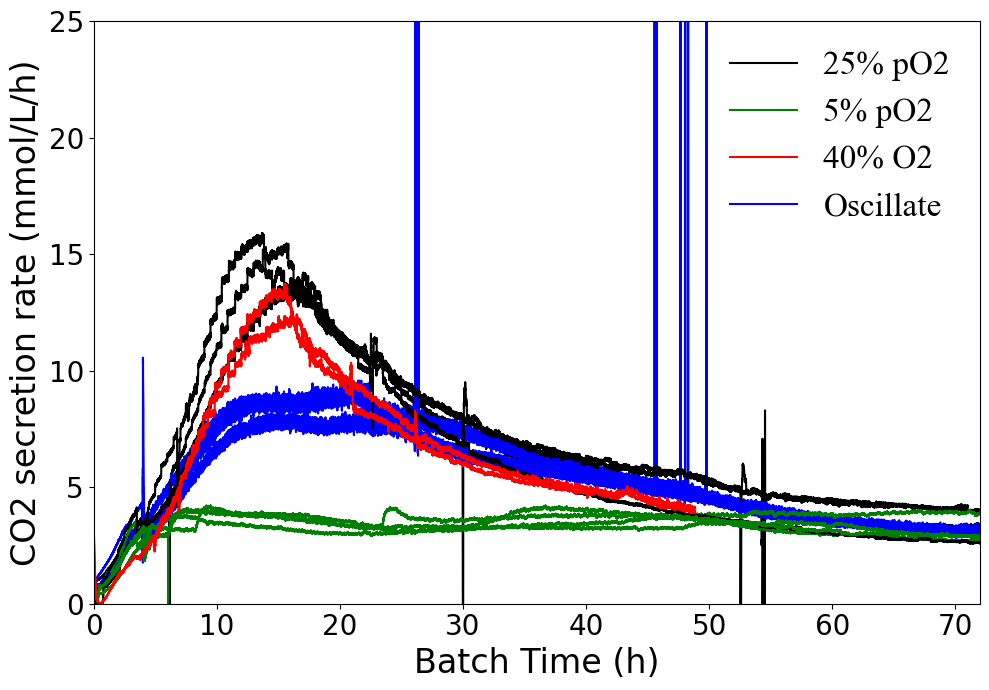

In [12]:

def clean_data(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]

fig, ax = plt.subplots(figsize=(10, 7))

# dfs = [df_09_reac1,df_09_reac2,df_10_reac1,df_10_reac2,df_11]
dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]
# dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]

colors = ['discard','blue', 'black', 'blue', 'black', 'blue','black','green','green','black', 'green','green','red','red']  # Define colors for each dataframe

annotation = ['discard bdcu29_1',
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'low-2',
              'low-x1',
              'low-3',
              'low-xx2',
              'high-1',
              'high-2',

             ]

n=0
c=0
for i, df in enumerate(dfs):
    c=i*2
    # print('before: i',i,'c',c)
    # print(annotation[c])
    if (('Fermenter01','BDCU-1','CER','g/h') in df.columns) and ('discard' not in annotation[c]):
        # Extract the columns you want to plot
        print('entered 1',i,c)
        x = df[('Fermenter01', 'BDCU-1', 'CER', 'g/h')]*1000/(44*1.5)

        valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] != 0
        x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
        if 'oscillate' in annotation[c]:
            x = clean_data(x)  # Apply cleaning function

        plt.plot(x, label=annotation[c], color=colors[c])
        # print(x.min(),x.iloc[200:].max())
        
        # print(min(x),annotation[c],x.idxmin(),x[x.idxmin()])
        # if (i!=1) and (colors[c+1]!='yellow'):

    if (('Fermenter02','BDCU-2','CER','g/h') in df.columns) and ('discard' not in annotation[c+1]):
        # print('entered 2',i,c)

        x = df[('Fermenter02', 'BDCU-2', 'CER', 'g/h')]*1000/(44*1.5)
        if 'oscillate' in annotation[c+1]:
            # Drop rows where F_in2 is zero
            valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >= .375
            x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        

            x = clean_data(x)  # Apply cleaning function
            
        plt.plot(x, label=annotation[c+1], color=colors[c+1])
    # c+=1

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=10)
            # print(min(x),annotation2[c],x.idxmin(),x[x.idxmin()])
plt.ylim(0,25)
plt.xlim(0,72)


custom_labels = ['25% pO2',  '5% pO2', '40% O2', 'Oscillate']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

#plt.title("flow rates adjusted, using max composition")
# plt.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=20,frameon=False)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.xlabel('Batch Time (h)',size=24)
plt.ylabel('CO2 secretion rate (mmol/L/h)', color='k',size=24)
plt.savefig('OMICS_CER.png')
plt.tight_layout()
plt.show()


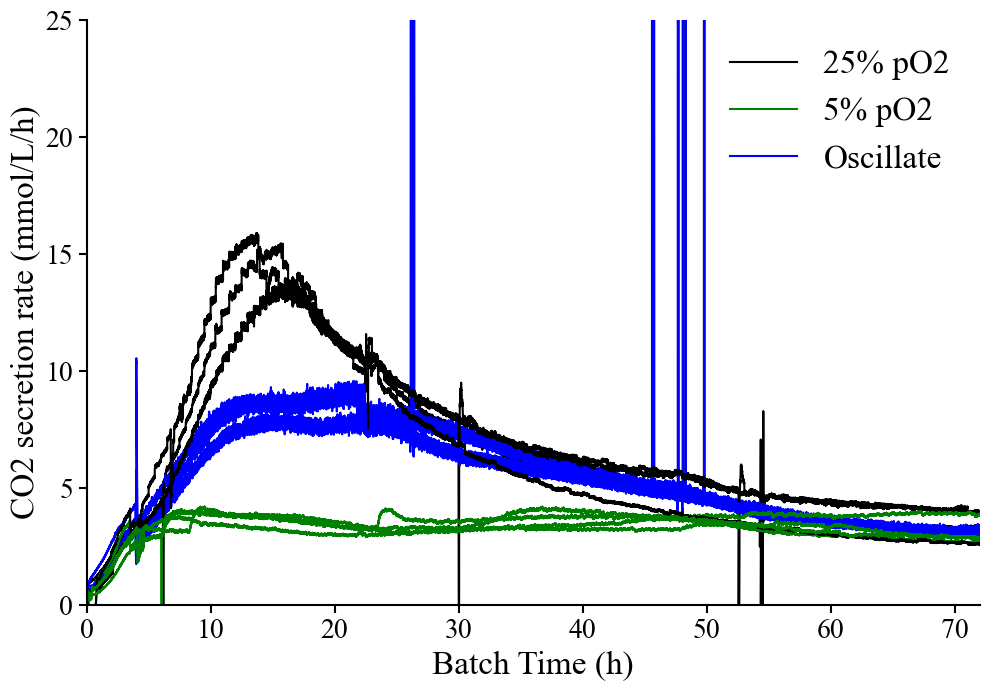

In [13]:
def clean_data(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]

# --- Global publication-quality settings ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['pdf.fonttype'] = 42   # editable text in vector PDF
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

fig, ax = plt.subplots(figsize=(10, 7))

dfs = [df_29, df_30, df_31, df_32, df_33, df_34]  # df_35 (40% O2 / red) removed
colors = ['discard','blue', 'black', 'blue', 'black', 'blue','black','green','green','black', 'green','green']
annotation = ['discard bdcu29_1',
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'low-2',
              'low-x1',
              'low-3',
              'low-xx2',
             ]
n = 0
c = 0
for i, df in enumerate(dfs):
    c = i * 2
    if (('Fermenter01','BDCU-1','CER','g/h') in df.columns) and ('discard' not in annotation[c]):
        x = df[('Fermenter01', 'BDCU-1', 'CER', 'g/h')]*1000/(44*1.5)
        valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] != 0
        x = x.loc[valid_rows]

        if 'oscillate' in annotation[c]:
            x = clean_data(x)
        ax.plot(x, label=annotation[c], color=colors[c])

    if (('Fermenter02','BDCU-2','CER','g/h') in df.columns) and ('discard' not in annotation[c+1]):
        x = df[('Fermenter02', 'BDCU-2', 'CER', 'g/h')]*1000/(44*1.5)
        if 'oscillate' in annotation[c+1]:
            valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >= .375
            x = x.loc[valid_rows]
            x = clean_data(x)
        ax.plot(x, label=annotation[c+1], color=colors[c+1])

ax.tick_params(axis='both', which='major', labelsize=20, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', labelsize=10)

ax.set_ylim(0, 25)
ax.set_xlim(0, 72)

custom_labels = ['25% pO2', '5% pO2', 'Oscillate']  # '40% O2' removed
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

ax.set_xlabel('Batch Time (h)', size=24)
ax.set_ylabel('CO2 secretion rate (mmol/L/h)', color='k', size=24)

# --- Remove top/right spines, thicken remaining ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()

# --- High-quality save ---
plt.savefig('OMICS_CER.png', dpi=600, bbox_inches='tight')
plt.savefig('OMICS_CER.pdf', bbox_inches='tight')
plt.savefig('OMICS_CER.svg', bbox_inches='tight')

## Omic Runs.

### OfflineData

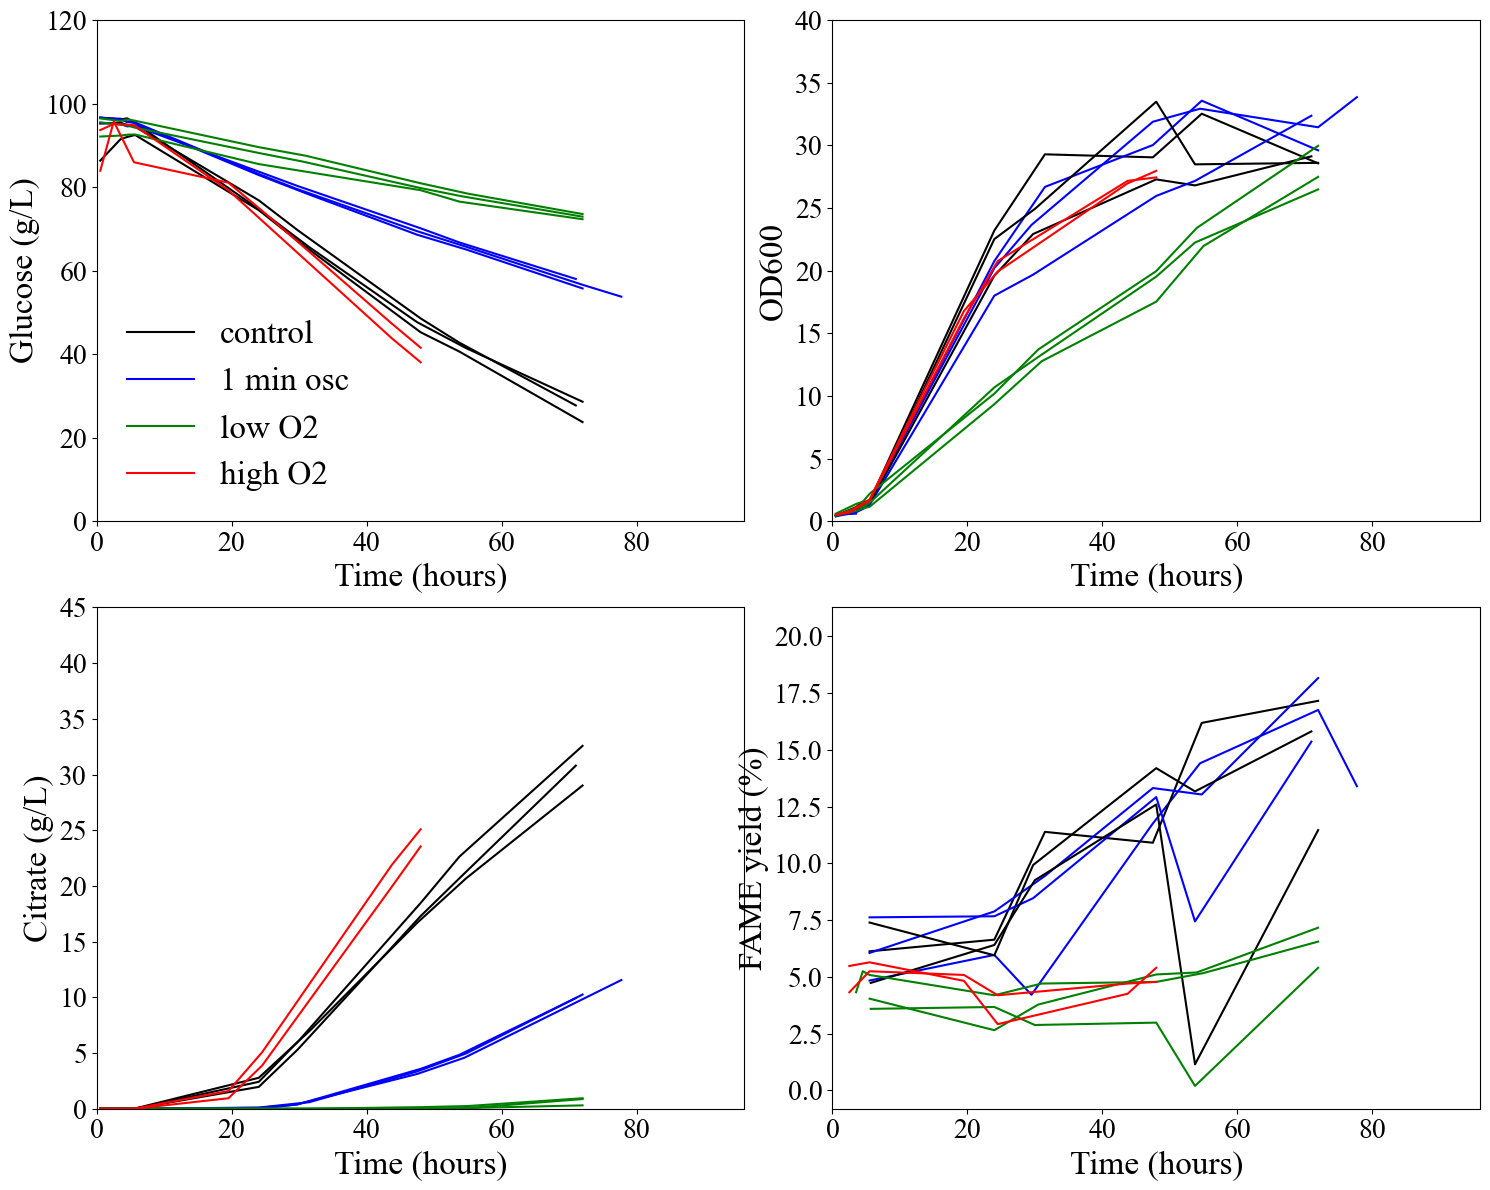

In [14]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #4
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 #5
    (Biostat_35_r1, 'High O2', 'red', '-'), # low O2 #4
    (Biostat_35_r2, 'High O2', 'red', '-'),  # low O2 #5
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('OD600', 'OD600', (0, 40)),

    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    # ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)



# # Define the datasets and their labels and plotting styles

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    (Biostat_35_r1, 'high O2', 'red', '-'), # oscillating
    (Biostat_35_r2, 'high O2', 'red', '-'),  # pO2 5% 
]
# # Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
        if "Biostat_23_r2" in label:
            axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
        elif "Biostat_22_r2" in label:
            axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
        else:
            axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control', '1 min osc', 'low O2', 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison2.png')
plt.show()


#### rates/yields 

In [15]:
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #3
    (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    (Biostat_35_r2, 'high O2', 'red', '-'),  # high O2 
]
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    # ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

DCWstore = []
for y_col, y_label, y_lim in plot_pairs:
    for store, label, color, linestyle in storages:
        
        DCWstore.append(store['DCW (g/L)'] / store['OD600'])

In [16]:
for store, label, color, linestyle in storages:


    # Calculate rates using log difference and time difference
    log_diff_DCW = np.log(store['DCW (g/L)'].iloc[1:].values) - np.log(store['DCW (g/L)'].iloc[:-1].values)
    log_diff_OD = np.log(store['OD600'].iloc[1:].values) - np.log(store['OD600'].iloc[:-1].values)

    
    FAME_diff = store['FAME titer (g/L)'].iloc[1:].values - store['FAME titer (g/L)'].iloc[:-1].values
        
    
    time_diff = store['hour'].iloc[1:].values - store['hour'].iloc[:-1].values
    
    
    rates_DCW = log_diff_DCW / time_diff
    # rates_DCW = np.insert(rates_DCW, 0, np.nan) # insert 0 at beginning.
    rates_DCW = np.append(rates_DCW, np.nan) # insert 0 at end. 

    rates_OD = log_diff_OD / time_diff
    # rates_OD = np.insert(rates_OD, 0, np.nan)
    rates_OD = np.append(rates_OD, np.nan) # insert 0 at end. 

    
    FAME_specific_rate = FAME_diff/time_diff
    FAME_specific_rate = np.append(FAME_specific_rate, np.nan)
    
    
    
    store['specific_µ_DCW'] = rates_DCW
    store['specific_µ_OD'] = rates_OD
    store['specific_FAME_rate (g/L/h)'] = FAME_specific_rate


    
    # print(label)
    # print(rates_OD, rates_DCW)
    # DCWstore.append(store['DCW (g/L)']/store['OD600'])

plot rates/yields. 

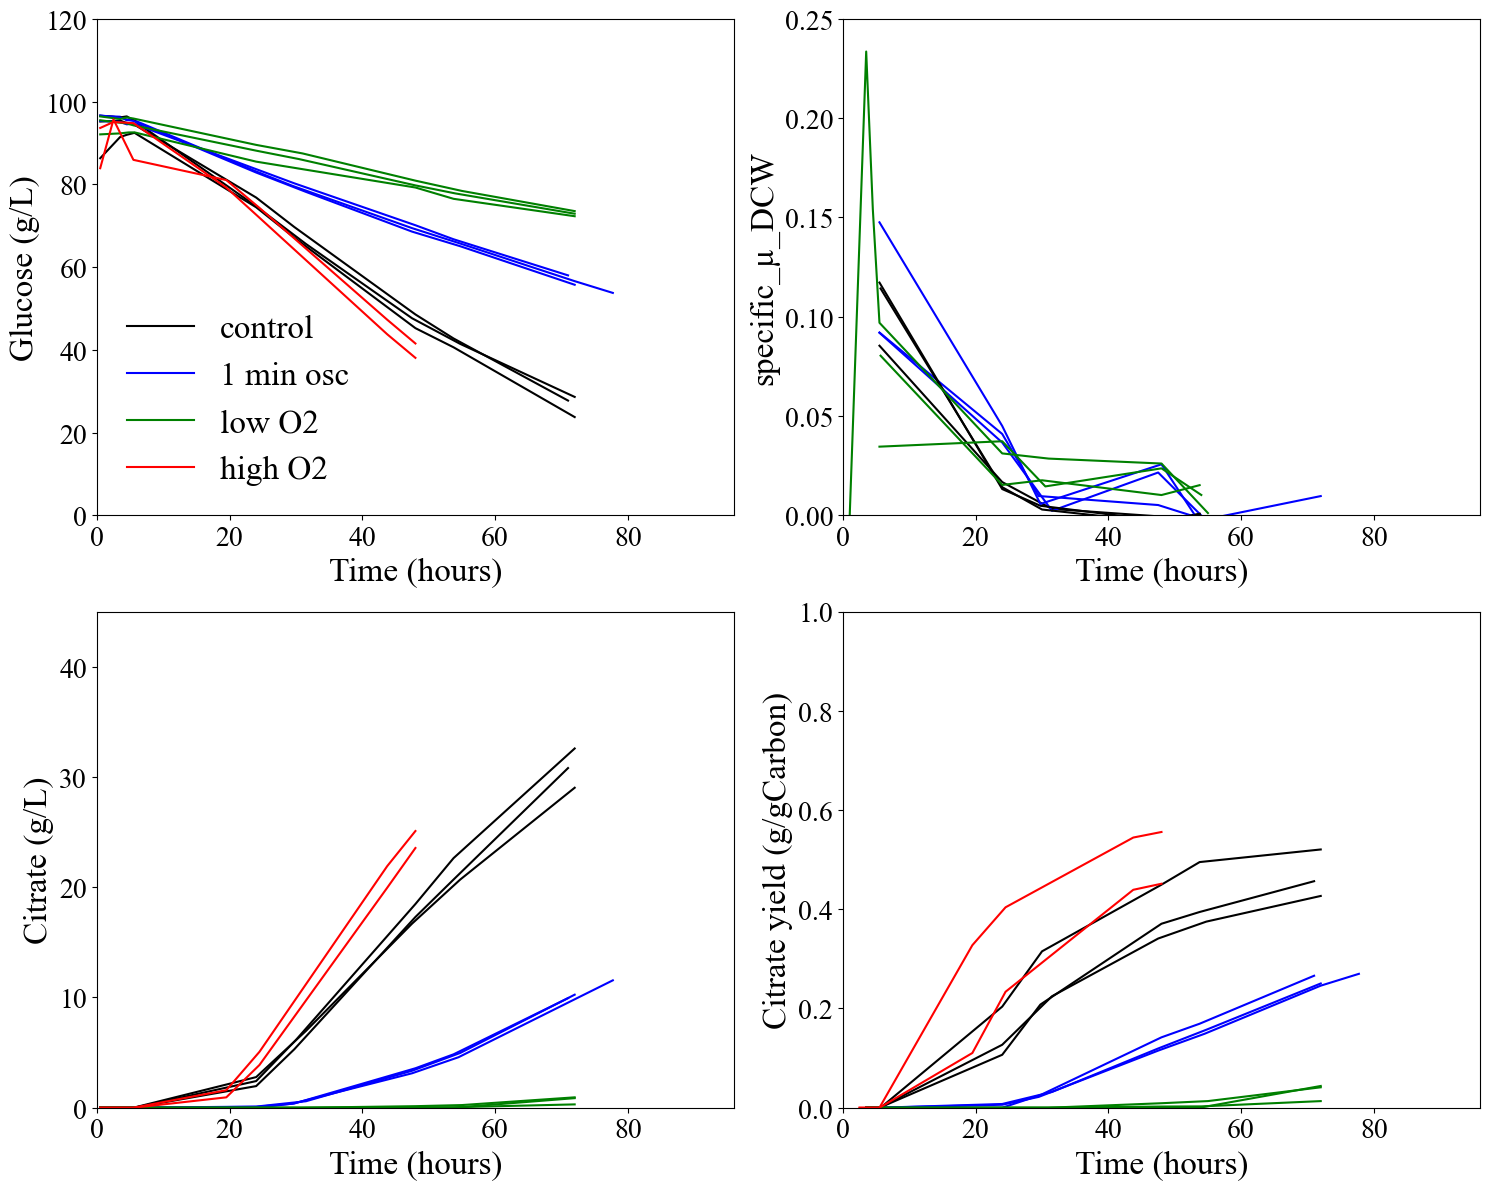

In [17]:
## plot rates/yields
fig, axs = plt.subplots(2, 2, figsize=(15, 12))


storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #3
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    (Biostat_35_r2, 'high O2', 'red', '-'),  # high O2 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('specific_µ_DCW', 'specific_µ_DCW', (0, .25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
    # ('specific citrate yield (g/g substrate)', 'Citrate yield (g/gCarbon)', (0, .2)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()


combined_data = []

# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)


        temp_df = store[['hour', y_col]].copy()
        temp_df['variable'] = y_label
        temp_df['condition'] = label
        
        combined_data.append(temp_df)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)

custom_labels = ['control', '1 min osc', 'low O2', 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
# plt.savefig('Biostat_omicsPhenotypeComparison.png')
plt.show()


In [18]:
combined_df = pd.concat(combined_data, ignore_index=True)


wide_df = combined_df.pivot_table(
    index=['hour', 'condition'],
    columns='variable',
    values=combined_df.columns[1]  # auto-detect value column
)

In [19]:
combined_df[(combined_df['hour']>70) & (combined_df['variable']=='Citrate (g/L)')]

,hour,Glucose.1,variable,condition,specific_µ_DCW,Citric Acid.1,citrate yield
200,72.00,NaN,Citrate (g/L),1 min osc,NaN,9.8320,NaN
201,77.75,NaN,Citrate (g/L),1 min osc,NaN,11.5524,NaN
210,72.00,NaN,Citrate (g/L),Control,NaN,29.0174,NaN
219,72.00,NaN,Citrate (g/L),1 min osc,NaN,10.2517,NaN
228,71.00,NaN,Citrate (g/L),Control,NaN,30.8017,NaN
237,71.00,NaN,Citrate (g/L),1 min osc,NaN,9.9347,NaN
246,72.00,NaN,Citrate (g/L),Control,NaN,32.5777,NaN
255,72.00,NaN,Citrate (g/L),low O2,NaN,0.8676,NaN
264,72.00,NaN,Citrate (g/L),low O2,NaN,0.3014,NaN
273,72.00,NaN,Citrate (g/L),low O2,NaN,0.9420,NaN


### Combine Data

#### definition for incyte data first. 

In [20]:
def compute_average_for_columns(df, target_hour, columns, neighbor_count=25):
    df = df.reset_index(drop=True)

    
    # Find the closest index in the target DataFrame for the target_hour
    closest_idx = (df['Time (h)'] - target_hour).abs().idxmin()

    # Compute start and end indices for averaging
    start_idx = max(0, closest_idx - neighbor_count)
    end_idx = min(len(df), closest_idx + neighbor_count)

    # Compute averages for all specified columns
    averages = {}
    for column in columns:
        # Ensure the subset is valid and avoid slicing errors
        subset = df[column].iloc[start_idx:end_idx]  
        averages[column] = subset.mean() if not subset.empty else float('nan')
    return averages


In [21]:
storages_combined = [
    (Biostat_29_r2, '1 min osc', 'blue', '-', IncyteData_29_r2),
    # (Biostat_30_r1, 'Control', 'black', '-', IncyteData_30_r1),
    # (Biostat_30_r2, '1 min osc', 'blue', '-', IncyteData_30_r2),
    (Biostat_31_r1, 'Control', 'black', '-', IncyteData_31_r1),
    (Biostat_31_r2, '1 min osc', 'blue', '-', IncyteData_31_r2),
    (Biostat_32_r1, 'Control', 'black', '-', IncyteData_32_r1),
    (Biostat_32_r2, 'low O2', 'green', '-', IncyteData_32_r2),
    (Biostat_33_r1, 'low O2', 'green', '-', IncyteData_33_r1),
    # (Biostat_33_r2, 'low O2', 'green', '-', IncyteData_33_r2),
    (Biostat_34_r1, 'low O2', 'green', '-', IncyteData_34_r1),
    # (Biostat_34_r2, 'low O2', 'green', '-', IncyteData_34_r2),
]

In [22]:
# Iterate through each tuple in storages_combined
columns_to_compute = ['fc(kHz)', 'Cell Density(pF/cm)', 'Conductivity(mS/cm)', 'Permittivity(pF/cm)', 'DeltaEps(pF/cm)','Alpha']
for biostat_df, label, color, linestyle, incyte_data in storages_combined:
    # Initialize a dictionary to hold lists of computed average values for each column
    average_values_by_column = {column: [] for column in columns_to_compute}
    # print(label)
    for hour_value in biostat_df['hour']:
        # print(hour_value)
        # Compute averages for the target hour and specified columns
        averages = compute_average_for_columns(incyte_data, hour_value, columns_to_compute,neighbor_count=10)
        
        # Append computed averages to the lists for each column
        for column, avg_value in averages.items():
            average_values_by_column[column].append(avg_value)
    
    # Update the biostat_df with the computed average values for each target column
    for column, values in average_values_by_column.items():
        biostat_df[column] = values

### OUR/CER next. 

Oscillating OUR is calucalted separetly below. 

In [31]:
# Compute average for a given time series around specified index
def compute_average_for_series(series, target_hour, neighbor_count=10):
    # Reset series index for clean operation
    series = series.reset_index(drop=False)
    
    # Find closest index for the target hour
    closest_idx = (series['age'] - target_hour).abs().idxmin()

    # Calculate boundaries
    start_idx = max(0, closest_idx - neighbor_count)
    end_idx = min(len(series), closest_idx + neighbor_count + 1)

    # Calculate and return mean from subset
    subset = series.iloc[start_idx:end_idx]
    return subset.mean() if not subset.empty else float('nan')

In [24]:
# include the off gas. 
storages_combined = [
    (Biostat_29_r2, '1 min osc', 'blue', 'r2', df_29),
    (Biostat_30_r1, 'Control', 'black', 'r1', df_30),
    (Biostat_30_r2, '1 min osc', 'blue', 'r2', df_30),
    (Biostat_31_r1, 'Control', 'black', 'r1', df_31),
    (Biostat_31_r2, '1 min osc', 'blue', 'r2', df_31),
    (Biostat_32_r1, 'Control', 'black', 'r1', df_32),
    (Biostat_32_r2, 'low O2', 'green', 'r2', df_32),
    (Biostat_33_r1, 'low O2', 'green', 'r1', df_33),
    # (Biostat_33_r2, 'low O2', 'green', 'r2', IncyteData_33_r2),
    (Biostat_34_r1, 'low O2', 'green', 'r1', df_34),
    # (Biostat_34_r2, 'low O2', 'green', '-', df_34),
]

#
columns_to_compute = ['fc(kHz)', 'Cell Density(pF/cm)', 'Conductivity(mS/cm)', 'Permittivity(pF/cm)', 'DeltaEps(pF/cm)','Alpha']


# iterate through off gas. 
for biostat_df, label, color, vessel, offgas_data in storages_combined:

    # check vessel for appropriate gas indexing. 
    if vessel == 'r2':
        x_our = offgas_data[('Fermenter02', 'BDCU-2', 'OUR', 'g/h')]*1000/(32*1.5)
        x_cer = offgas_data[('Fermenter02', 'BDCU-2', 'CER', 'g/h')]*1000/(48*1.5)

        ## difficult calculating OUR/CER with no air in for balance purposes. 
        # drop oscillating instances when nitrogen is coming in. 
        if 'osc' in label:
            # Drop rows where F_in2 is zero
            valid_rows = offgas_data[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >= .375
            x_our = x_our.loc[valid_rows]  # Only select rows where F_in2 is not zero   
            x_cer = x_cer.loc[valid_rows]  # Only select rows where F_in2 is not zero   

    
    elif vessel == 'r1':
        x_our = offgas_data[('Fermenter01', 'BDCU-1', 'OUR', 'g/h')]*1000/(32*1.5)
        x_cer = offgas_data[('Fermenter01', 'BDCU-1', 'CER', 'g/h')]*1000/(48*1.5)


        ## difficult calculating OUR/CER with no air in for balance purposes. 
        # drop oscillating instances when nitrogen is coming in. 
        if 'osc' in label:
            # Drop rows where F_in2 is zero
            valid_rows = offgas_data[('Fermenter01', 'BDCU-1', 'F_in1', 'LPM')] >= .375
            x_our = x_our.loc[valid_rows]  # Only select rows where F_in2 is not zero   
            x_cer = x_cer.loc[valid_rows]  # Only select rows where F_in2 is not zero   

    
    # Compute averages for OUR and CER
    averages_our = []
    averages_cer = []


    
    for hour_value in biostat_df['hour']:
        avg_our = compute_average_for_series(x_our, hour_value, neighbor_count=5)
        avg_cer = compute_average_for_series(x_cer, hour_value, neighbor_count=5)
        
        averages_our.append(avg_our.values[1])
        averages_cer.append(avg_cer.values[1])


    # Update biostat DataFrame with calculated averages
    biostat_df['average_our'] = averages_our
    biostat_df['average_cer'] = averages_cer


In [66]:
Biostat_31_r1

,Unnamed: 14,date,time,hour,reactor,sample number,sample volume (mL),moxiflow D (µm),OD600,BASE (mL),...,specific_µ_OD,specific_FAME_rate (g/L/h),fc(kHz),Cell Density(pF/cm),Conductivity(mS/cm),Permittivity(pF/cm),DeltaEps(pF/cm),Alpha,average_our,average_cer
0,NaN,2025-01-21,09:45:00,0.50,r1,1.0,8.0,-,0.435,0.0,...,0.230282,NaN,1399.292493,-0.324262,4.703582,0.973691,1.288661,0.101258,-0.227103,0.668392
2,NaN,NaT,12:45:00,3.50,r1,3.0,8.0,-,0.868,1.0,...,0.236874,NaN,1786.927979,-0.053754,4.646231,1.244033,1.569340,0.101735,-2.454118,2.719696
4,NaN,NaT,13:45:00,4.50,r1,5.0,8.0,-,1.100,1.0,...,0.233994,NaN,1869.859985,0.212769,4.473820,1.511340,1.792730,0.101439,-2.374020,3.115345
6,NaN,NaT,14:45:00,5.50,r1,7.0,8.0,-,1.390,2.0,...,0.143039,0.031961,1884.670044,0.473110,4.469680,1.771680,2.084480,0.102267,-2.925892,3.644653
8,NaN,2025-01-22,09:15:00,24.00,r1,9.0,8.0,NaN,19.600,37.0,...,0.027214,0.095938,1629.981000,4.029963,3.826312,5.329225,7.419456,0.127330,-10.292716,9.056384
10,NaN,NaT,15:00:00,29.75,r1,11.0,8.0,NaN,22.920,62.0,...,0.009542,0.038079,1583.449017,4.815768,3.930689,6.118913,8.232499,0.129335,-10.136020,7.374398
12,NaN,2025-01-23,09:15:00,48.00,r1,13.0,8.0,NaN,27.280,159.0,...,-0.003087,-0.029471,1637.844489,5.380998,6.105211,6.686352,8.807052,0.113025,-9.034566,5.138857
14,NaN,NaT,15:00:00,53.75,r1,15.0,8.0,NaN,26.800,190.0,...,0.004813,0.022161,1720.826489,5.289934,7.056893,6.597975,9.011046,0.122718,-8.238370,4.465297
16,NaN,2025-01-24,08:15:00,71.00,r1,17.0,8.0,NaN,29.120,283.0,...,NaN,NaN,1807.135486,5.226096,10.443030,6.533414,8.579816,0.119793,-7.300385,3.834796


In [25]:
Biostat_31_r1

,Unnamed: 14,date,time,hour,reactor,sample number,sample volume (mL),moxiflow D (µm),OD600,BASE (mL),...,specific_µ_OD,specific_FAME_rate (g/L/h),fc(kHz),Cell Density(pF/cm),Conductivity(mS/cm),Permittivity(pF/cm),DeltaEps(pF/cm),Alpha,average_our,average_cer
0,NaN,2025-01-21,09:45:00,0.50,r1,1.0,8.0,-,0.435,0.0,...,0.230282,NaN,1399.292493,-0.324262,4.703582,0.973691,1.288661,0.101258,-0.227103,0.668392
2,NaN,NaT,12:45:00,3.50,r1,3.0,8.0,-,0.868,1.0,...,0.236874,NaN,1786.927979,-0.053754,4.646231,1.244033,1.569340,0.101735,-2.454118,2.719696
4,NaN,NaT,13:45:00,4.50,r1,5.0,8.0,-,1.100,1.0,...,0.233994,NaN,1869.859985,0.212769,4.473820,1.511340,1.792730,0.101439,-2.374020,3.115345
6,NaN,NaT,14:45:00,5.50,r1,7.0,8.0,-,1.390,2.0,...,0.143039,0.031961,1884.670044,0.473110,4.469680,1.771680,2.084480,0.102267,-2.925892,3.644653
8,NaN,2025-01-22,09:15:00,24.00,r1,9.0,8.0,NaN,19.600,37.0,...,0.027214,0.095938,1629.981000,4.029963,3.826312,5.329225,7.419456,0.127330,-10.292716,9.056384
10,NaN,NaT,15:00:00,29.75,r1,11.0,8.0,NaN,22.920,62.0,...,0.009542,0.038079,1583.449017,4.815768,3.930689,6.118913,8.232499,0.129335,-10.136020,7.374398
12,NaN,2025-01-23,09:15:00,48.00,r1,13.0,8.0,NaN,27.280,159.0,...,-0.003087,-0.029471,1637.844489,5.380998,6.105211,6.686352,8.807052,0.113025,-9.034566,5.138857
14,NaN,NaT,15:00:00,53.75,r1,15.0,8.0,NaN,26.800,190.0,...,0.004813,0.022161,1720.826489,5.289934,7.056893,6.597975,9.011046,0.122718,-8.238370,4.465297
16,NaN,2025-01-24,08:15:00,71.00,r1,17.0,8.0,NaN,29.120,283.0,...,NaN,NaN,1807.135486,5.226096,10.443030,6.533414,8.579816,0.119793,-7.300385,3.834796


### Calcualate oscillating OUR. 

In [26]:
def calculate_pO2_trends(df_po2):
    # grab air data and time of fermentation. 
    df_po2 = pd.DataFrame({
        'age': store['PO2_A_Value']['age'],
        'value': store['PO2_A_Value']['value']
    })

    # calculate differences between pO2 points - note, the recording is not always 100% accurate. 
    df_po2['difference'] = df_po2['value'].diff()

    # note the trend, when there is a sign shift. 
    df_po2['trend_change'] = np.sign(df_po2['difference']) != np.sign(df_po2['difference'].shift())

    # grab index of when they shift signs. 
    trend_change_points = df_po2[df_po2['trend_change']].index


    
    # Initialize lists to store information.
    original_ages = []
    original_values = []
    value_differences = []
    age_differences = []
    
    # Calculate differences between consecutive trend change points.
    for idx in range(len(trend_change_points) - 1):
       
        t1_idx = trend_change_points[idx]
        t2_idx = trend_change_points[idx + 1]
    
        # append the time.
        original_ages.append(df_po2.loc[t1_idx, 'age'])

        # append the pO2. 
        original_values.append(df_po2.loc[t1_idx, 'value'])

        # calculate and append the change in time and pO2. 
        value_difference = df_po2.loc[t2_idx, 'value'] - df_po2.loc[t1_idx, 'value']
        age_difference = df_po2.loc[t2_idx, 'age'] - df_po2.loc[t1_idx, 'age']
    
        value_differences.append(value_difference)
        age_differences.append(age_difference)
    
    # Create new DataFrame with the extracted information.
    df_trend_changes = pd.DataFrame({
        'age': original_ages,
        'original_value': original_values,
        'value_difference': value_differences,
        'age_difference': age_differences
    })

    return (df_trend_changes)


In [27]:
def calculate_our_offgas_oscillate(df):
    
    # constants
    R = 8.314472 # [J /mol/K]
    mw_co2 = 44 # g/mol
    mw_o2 = 32 # g/mol
    df_po2 = pd.DataFrame({
        'age': df['temp_age_continue'],
        'yO2_out': df[('Fermenter02', 'BDCU-2', 'CH1-O2', 'Vol %')],
        'temp': df[('Fermenter02','BDCU-2','Temperature','°C')]+273.15, # in K
        'pres': df[('Fermenter02','BDCU-2','Pressure','bar')]*100 # kPa
    })
    df_po2['yO2_change'] = 20.95 - df_po2['yO2_out']
    df_po2['O2change'] = df_po2['yO2_change']/100*1.125*df_po2['pres']*mw_o2/(R*df_po2['temp'])
    df_po2['OUR (mmol/Lh)']= df_po2['O2change']*1000/(32*1.5)*-1

    return(df_po2)

In [28]:
oscillating_storages = [
    (Biostat_29_r2, '1 min osc', 'blue', 'r2',storage_29_r2, df_29),
    (Biostat_30_r1, 'Control', 'black', 'r1', storage_30_r1, df_30),
    (Biostat_30_r2, '1 min osc', 'blue', 'r2',storage_30_r2, df_30),
    (Biostat_31_r1, 'Control', 'black', 'r1', storage_31_r1, df_31),
    (Biostat_31_r2, '1 min osc', 'blue', 'r2', storage_31_r2, df_31),
    (Biostat_32_r1, 'Control', 'black', 'r1', storage_32_r1, df_32),
    (Biostat_32_r2, 'low O2', 'green', 'r2', storage_32_r2,df_32),
    (Biostat_33_r1, 'low O2', 'green', 'r1', storage_33_r1,df_33),
    # (Biostat_33_r2, 'low O2', 'green', 'r2', IncyteData_33_r2),
    (Biostat_34_r1, 'low O2', 'green', 'r1',storage_34_r1, df_34),
    # (Biostat_34_r2, 'low O2', 'green', '-', df_34),
]

In [29]:

# oscillating_storages = [
#     (Biostat_29_r2, '1 min osc', 'blue', 'r2', storage_29_r2, df_29),
#     (Biostat_30_r2, '1 min osc', 'blue', 'r2', storage_30_r2, df_30),
#     (Biostat_31_r2, '1 min osc', 'blue', 'r2', storage_31_r2, df_31),
# ]
oscillating_storages = [
    (Biostat_29_r2, '1 min osc', 'blue', 'r2',storage_29_r2, df_29),
    # (Biostat_30_r1, 'Control', 'black', 'r1', storage_30_r1, df_30),
    (Biostat_30_r2, '1 min osc', 'blue', 'r2',storage_30_r2, df_30),
    # (Biostat_31_r1, 'Control', 'black', 'r1', storage_31_r1, df_31),
    (Biostat_31_r2, '1 min osc', 'blue', 'r2', storage_31_r2, df_31),
    # (Biostat_32_r1, 'Control', 'black', 'r1', storage_32_r1, df_32),
    # (Biostat_32_r2, 'low O2', 'green', 'r2', storage_32_r2,df_32),
    # (Biostat_33_r1, 'low O2', 'green', 'r1', storage_33_r1,df_33),
    # (Biostat_33_r2, 'low O2', 'green', 'r2', IncyteData_33_r2),
    # (Biostat_34_r1, 'low O2', 'green', 'r1',storage_34_r1, df_34),
    # (Biostat_34_r2, 'low O2', 'green', '-', df_34),
]
kLa = 100 # assumed for oscillating condition. 

test_trend = pd.DataFrame()
for biostat_df, label, color, vessel, store, offgas in oscillating_storages:
    
    # calculate o2 change from gas. 
    df_our_offgas = calculate_our_offgas_oscillate(offgas)
    
    # calculate o2 change due to liquid. 
    df_trend = calculate_pO2_trends(store)

    # calculate OURs. 
    test_trend = df_trend[df_trend['age']>0]

    test_trend = test_trend.apply(pd.to_numeric, errors='coerce')

    
    # test_trend['Kla*[O2_star-[averageO2]]'] = 100*(100-(test_trend['value_difference'])/2) # %/h

    # convert to g/h. 7.54 mg/L is assumed saturation of O2 at 30C. 
    test_trend['Kla*[O2_star-[averageO2]]'] = kLa*(7.54-(test_trend['value_difference'])*7.54/2)/1000 # g/h

    # full OUR calculation
    # test_trend['OUR'] = test_trend['value_difference']*7.54/1000-test_trend['Kla*[O2_star-[averageO2]]']

    test_trend['OUR'] = test_trend['value_difference']*7.54/1000#-test_trend['Kla*[O2_star-[averageO2]]']

    
    test_trend['OUR (mmol/Lh)'] = test_trend['OUR']*1000/(32*1.5)

    test_trend = test_trend[test_trend['OUR']<0]

    x_our = test_trend['OUR (mmol/Lh)']
    x_our.index = test_trend['age']

    # recalculating OUR from offgas. 
    x_our_offgas = df_our_offgas['OUR (mmol/Lh)']
    x_our_offgas.index = df_our_offgas['age']
   
    # # Compute averages for OUR and CER
    averages_our = []
    averages_our_offgas = []
    averages_calc = []
    # for calculating averages. 
    
    for hour_value in biostat_df['hour']:
        avg_our = compute_average_for_series(x_our, hour_value, neighbor_count=5)
        avg_our_offgas_series = compute_average_for_series(x_our_offgas, hour_value, neighbor_count=5)

        
        averages_our.append(avg_our.values[1])
        averages_our_offgas.append(avg_our_offgas_series.values[1])
        averages_calc.append(avg_our_offgas_series.values[1]+avg_our.values[1])
    
    # # Update biostat DataFrame with calculated averages

    #
    
    # biostat_df['average_our_airflow'] = averages_our
    
    # biostat_df['average_our_offgas'] = averages_our_offgas

    # # biostat_df['average_cer'] = averages_cer

    # biostat_df['average_our_new'] =  biostat_df['average_our_offgas'] + biostat_df['average_our_airflow']
    biostat_df['average_our'] = averages_calc

In [30]:
biostat_df

,Unnamed: 14,date,time,hour,reactor,sample number,sample volume (mL),moxiflow D (µm),OD600,BASE (mL),...,specific_µ_OD,specific_FAME_rate (g/L/h),fc(kHz),Cell Density(pF/cm),Conductivity(mS/cm),Permittivity(pF/cm),DeltaEps(pF/cm),Alpha,average_our,average_cer
1,NaN,NaT,NaN,0.50,r2,2.0,8.0,-,0.390,0.0,...,0.202511,NaN,482.055251,0.185345,4.809594,0.272560,0.251870,0.100565,-1.090387,0.717018
3,NaN,NaT,NaN,3.50,r2,4.0,8.0,-,0.716,0.0,...,0.307731,NaN,2100.103003,0.486700,4.749256,0.573319,0.651599,0.098390,-1.421895,2.807175
5,NaN,NaT,NaN,4.50,r2,6.0,8.0,-,0.974,1.0,...,0.277881,NaN,2543.355029,0.577977,4.708655,0.665025,0.883563,0.105998,-6.295148,2.636458
7,NaN,NaT,NaN,5.50,r2,8.0,8.0,NaN,1.286,1.0,...,0.142640,0.031207,2129.868018,0.713157,4.665035,0.800170,1.021146,0.106047,-6.724480,3.078952
9,NaN,NaT,NaN,24.00,r2,10.0,8.0,NaN,18.000,16.0,...,0.015518,0.046115,1305.983478,5.552153,4.928499,5.639887,11.870725,0.187142,-6.005932,7.324264
11,NaN,NaT,NaN,29.75,r2,12.0,8.0,NaN,19.680,19.0,...,0.015176,0.033499,1216.109985,5.674490,6.890480,5.761620,11.728500,0.165289,-7.071850,5.920899
13,NaN,NaT,NaN,48.00,r2,14.0,8.0,NaN,25.960,40.0,...,0.007859,-0.086384,1283.930054,4.671310,14.538100,4.758450,9.536220,0.142391,-6.469812,4.326100
15,NaN,NaT,NaN,53.75,r2,16.0,8.0,NaN,27.160,49.0,...,0.010155,0.054307,1285.228510,4.409822,16.548079,4.498390,9.167496,0.141913,-6.290759,3.651626
17,NaN,NaT,NaN,71.00,r2,18.0,8.0,NaN,32.360,81.0,...,NaN,NaN,1277.270020,4.074830,22.685699,4.165270,8.112790,0.136309,-7.096855,3.028068


In [33]:

storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #3
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 ##
    # (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    # (Biostat_35_r2, 'high O2', 'red', '-'),  # high O2 
]


# Dictionary mapping each DataFrame to its name
df_names = {
    id(Biostat_29_r2): 'Biostat_29_r2',
    id(Biostat_30_r1): 'Biostat_30_r1',
    id(Biostat_30_r2): 'Biostat_30_r2',
    id(Biostat_31_r1): 'Biostat_31_r1',
    id(Biostat_31_r2): 'Biostat_31_r2',
    id(Biostat_32_r1): 'Biostat_32_r1',
    id(Biostat_32_r2): 'Biostat_32_r2',
    id(Biostat_33_r1): 'Biostat_33_r1',
    id(Biostat_34_r1): 'Biostat_34_r1',
    id(Biostat_35_r1): 'Biostat_35_r1',
    id(Biostat_35_r2): 'Biostat_35_r2',
}


calculate mu for incyte data. 

In [34]:
storages_combined = [
    (Biostat_29_r2, '1 min osc', 'blue', '-'),
    # (Biostat_30_r1, 'Control', 'black', '-', IncyteData_30_r1),
    # (Biostat_30_r2, '1 min osc', 'blue', '-', IncyteData_30_r2),
    (Biostat_31_r1, 'Control', 'black', '-'),
    (Biostat_31_r2, '1 min osc', 'blue', '-'),
    (Biostat_32_r1, 'Control', 'black', '-'),
    (Biostat_32_r2, 'low O2', 'green', '-'),
    (Biostat_33_r1, 'low O2', 'green', '-'),
    # (Biostat_33_r2, 'low O2', 'green', '-', IncyteData_33_r2),
    (Biostat_34_r1, 'low O2', 'green', '-'),
    # (Biostat_34_r2, 'low O2', 'green', '-', IncyteData_34_r2),
]

for store, label, color, linestyle in storages_combined:

    print()
    # Calculate rates using log difference and time difference
    log_diff_permittivity = np.log(store['Permittivity(pF/cm)'].iloc[1:].values) - np.log(store['Permittivity(pF/cm)'].iloc[:-1].values)
    log_diff_cellDensity = np.log(store['Cell Density(pF/cm)'].iloc[1:].values) - np.log(store['Cell Density(pF/cm)'].iloc[:-1].values)

        
    
    time_diff = store['hour'].iloc[1:].values - store['hour'].iloc[:-1].values
    
    
    rates_permittivity = log_diff_permittivity / time_diff
    # rates_DCW = np.insert(rates_DCW, 0, np.nan) # insert 0 at beginning.
    rates_permittivity = np.append(rates_permittivity, np.nan) # insert 0 at end. 

    rates_cellDensity = log_diff_cellDensity / time_diff
    # rates_OD = np.insert(rates_OD, 0, np.nan)
    rates_cellDensity = np.append(rates_cellDensity, np.nan) # insert 0 at end. 

        
    
    
    store['specific_µ_permittivity'] = rates_permittivity
    store['specific_µ_cellDensityProbe'] = rates_cellDensity

    
    # print(label)
    # print(rates_OD, rates_DCW)
    # DCWstore.append(store['DCW (g/L)']/store['OD600'])

In [35]:
combined_df = pd.DataFrame()


In [36]:
# Iterate through each element in storages
set_01 = set(Biostat_29_r2.columns)
set_02 = set(Biostat_33_r1.columns)
drop_set = set_02-set_01




for df, condition, _, _ in storages:
    # Add the condition to a new column
    
    df_name = df_names[id(df)]  # Retrieve the name using the id of the DataFrame

    df['Condition'] =  f"{condition} + {df_name}"
    
    print(condition,len(df.columns))
    # Append the modified DataFrame to combined_df
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# View the combined DataFrame
combined_df.drop(columns=list(drop_set),inplace=True)
combined_df.head()


1 min osc 83
Control 75
1 min osc 75
Control 83
1 min osc 83
Control 83
low O2 83
low O2 97
low O2 83


,Unnamed: 14,date,time,hour,reactor,sample number,sample volume (mL),moxiflow D (µm),OD600,BASE (mL),...,Cell Density(pF/cm),Conductivity(mS/cm),Permittivity(pF/cm),DeltaEps(pF/cm),Alpha,average_our,average_cer,specific_µ_permittivity,specific_µ_cellDensityProbe,Condition
0,NaN,NaT,NaN,0.5,r2,2.0,8.0,-,0.523,0.0,...,-0.021530,4.682294,0.257175,0.513937,0.101675,-1.465111,0.771537,0.264824,NaN,1 min osc + Biostat_29_r2
1,NaN,NaT,NaN,3.5,r2,4.0,8.0,-,0.604,0.0,...,0.291649,4.746709,0.569198,0.753552,0.106032,-0.344230,3.030968,0.226564,0.402168,1 min osc + Biostat_29_r2
2,NaN,NaT,NaN,4.5,r2,6.0,8.0,-,NaN,1.0,...,0.436034,4.653700,0.713935,0.917434,0.101366,-6.128778,2.782124,0.227941,0.350075,1 min osc + Biostat_29_r2
3,NaN,NaT,NaN,5.5,r2,8.0,8.0,-,1.600,1.0,...,0.618808,4.605170,0.896710,1.067690,0.098861,-6.159482,3.264168,0.091838,0.108726,1 min osc + Biostat_29_r2
4,NaN,NaT,NaN,24.0,r2,10.0,8.0,-,20.200,16.0,...,4.624994,5.302573,4.903646,8.005513,0.155614,-6.024390,7.423844,-0.014741,-0.014746,1 min osc + Biostat_29_r2


In [37]:
columns_to_drop = ['Unnamed: 14', 'date', 'time','sample number',
                   'sample volume (mL)', 'moxiflow D (µm)','Unnamed: 33',
                   'Unnamed: 49', 'Unnamed: 50',
                   'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54','date.1', 'BLANK',
       'Unnamed: 69', 'Unnamed: 70', 'Unnamed: 71','Titer (g/L)',
       'estimated titer with evaporation', 'equivilant titer (g/L)','Unnamed: 77','pre', 'post', 'volume',
       'weight (g)','Xylose.1', 'Lactic Acid.1', 'Glycerol.1',
       'Acetic Acid.1', 'Ethanol.1', 'Oxalic Acid.1', 'Succinic Acid.1',
       'Fumaric Acid', 'total sugar (g/L)', 'sugar consumed (g/L)',
       'sugar consumption rates (g/L/h)', 'sugar consumed / timepoint',
       'specific sugar consumption rate (g/L/h)', 'specifc biomass formation ','FAME bio weight (mg)',
       'FAME (mg)','specific Fame (g/L/h)']
        

In [38]:
combined_df.drop(columns=list(columns_to_drop),inplace=True)


calculate FAME metrics. 

In [39]:
combined_df['Fame rate (g/L/h)'] = combined_df['FAME titer (g/L)']/combined_df['hour']
combined_df['FAME yield (g/g substrate)'] = combined_df['FAME titer (g/L)']/combined_df['sugar consumed']
combined_df['RQ'] = abs(combined_df['average_cer']/combined_df['average_our'])

In [128]:
combined_df.to_csv('omicsCombinedData.csv')

In [40]:
DCWstore = []
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        # print(store['hour'], store[y_col], store['OD600'])
        DCWstore.append(store['DCW (g/L)'])

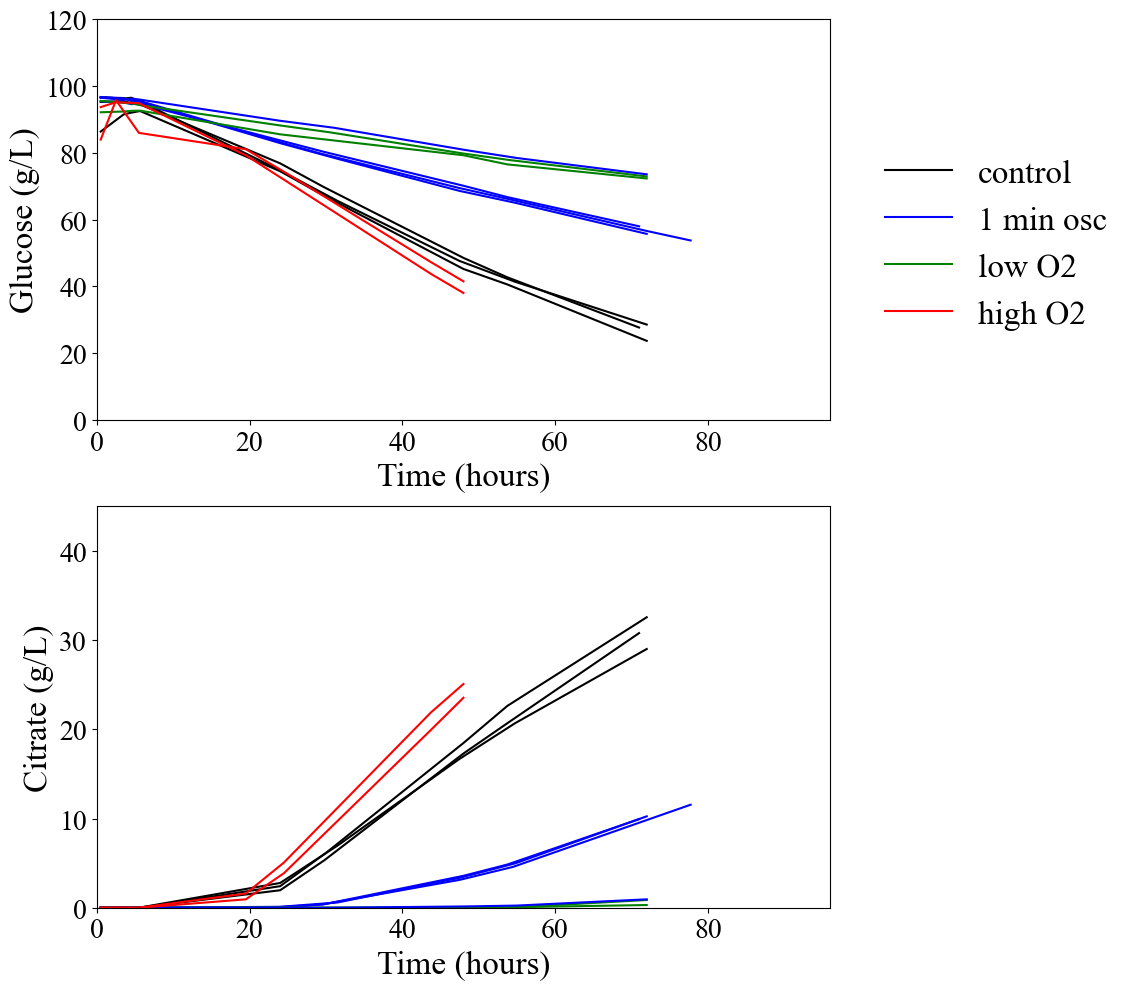

In [41]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'blue', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    (Biostat_35_r1, 'high O2', 'red', '-'), # oscillating
    (Biostat_35_r2, 'high O2', 'red', '-'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)



# # Define the datasets and their labels and plotting styles

# Define the datasets and their labels and plotting styles
# storages = [
#     #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
#     (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
#     #(Biostat_30_r1, 'Control', 'black', '-'),  # control #1
#     (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
#     #(Biostat_31_r1, 'Control', 'black', '-'), # control #2
#     (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
#     #(Biostat_32_r1, 'Control', 'black', '-'), # control #3
#     #(Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
#     # (Biostat_33_r1, '1 min osc', 'blue', '-'), # low O2 #2
#     # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 #3
#     # (Biostat_34_r1, '1 min osc', 'blue', '-'), # oscillating
#     # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
# ]
# # # Add the FAME yield data to the last subplot
# idx_fame = 3  # this is the index for the last subplot
# for store, label, color, linestyle in storages:
#     if fame_yield_col in store:
#         # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
#         if "Biostat_23_r2" in label:
#             axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
#         elif "Biostat_22_r2" in label:
#             axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
#         else:
#             axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# # axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control', '1 min osc', 'low O2', 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24, loc='center left', bbox_to_anchor=(.86, 0.75), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout(rect=[0, 0, 0.85, 1])


# Save and show the plot
# plt.savefig('Biostat_omicsPhenotypeComparison.png', bbox_inches='tight')
plt.show()


Bounding box dimensions (in pixels): (0.0, 0.0, 800.0, 500.0)
Bounding box dimensions (in inches): [0.0, 0.0, 8.0, 5.0]


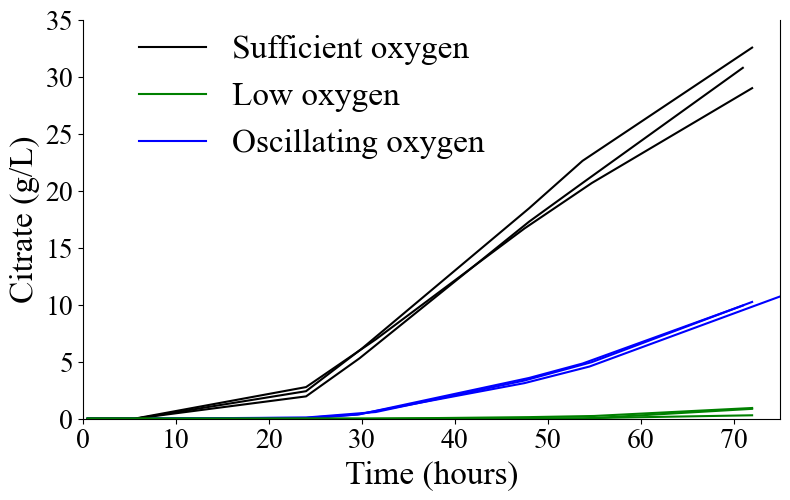

In [51]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
# axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs.plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['Sufficient oxygen',  'Low oxygen', 'Oscillating oxygen']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    # plt.Line2D([0], [0], color='orange', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24,bbox_to_anchor=(0.65, 1), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout()

axs.spines['top'].set_visible(False)

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison.png', bbox_inches='tight')
# Get the bounding box dimensions
bbox_dims = fig.bbox.bounds
print(f"Bounding box dimensions (in pixels): {bbox_dims}")

# Convert bounding box dimensions to inches
bbox_inches = [dim / fig.dpi for dim in bbox_dims]
print(f"Bounding box dimensions (in inches): {bbox_inches}")

plt.show()


Bounding box dimensions (in pixels): (0.0, 0.0, 800.0, 500.0)
Bounding box dimensions (in inches): [0.0, 0.0, 8.0, 5.0]


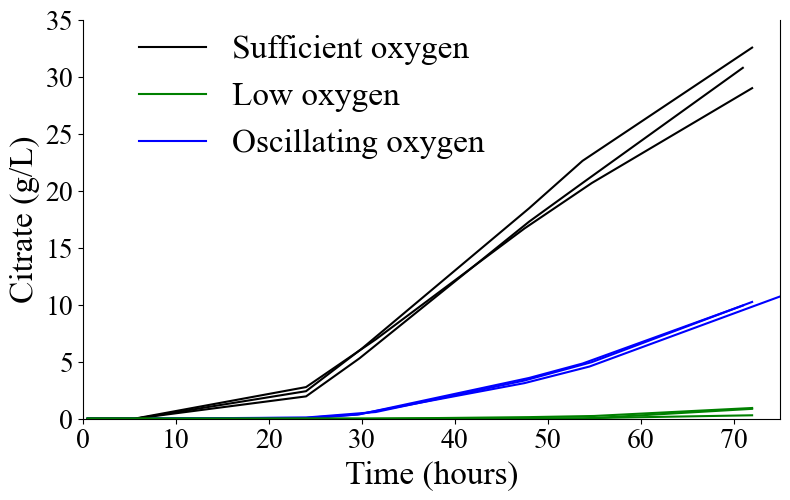

In [52]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
# axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs.plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['Sufficient oxygen',  'Low oxygen', 'Oscillating oxygen']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    # plt.Line2D([0], [0], color='orange', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24,bbox_to_anchor=(0.65, 1), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout()

axs.spines['top'].set_visible(False)

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison.png', bbox_inches='tight')
# Get the bounding box dimensions
bbox_dims = fig.bbox.bounds
print(f"Bounding box dimensions (in pixels): {bbox_dims}")

# Convert bounding box dimensions to inches
bbox_inches = [dim / fig.dpi for dim in bbox_dims]
print(f"Bounding box dimensions (in inches): {bbox_inches}")

plt.show()


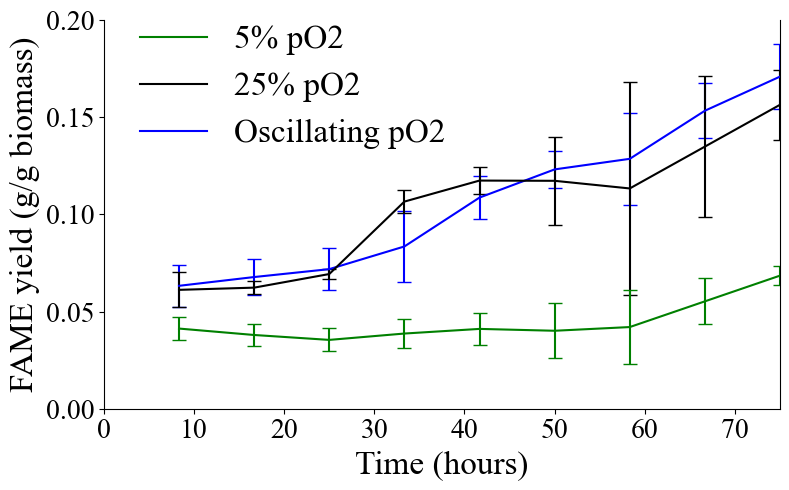

In [53]:


# Define storages and their labels and plotting styles
storages = [
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'),  # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'),  # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'),   # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'),   # low O2 #2
    (Biostat_34_r1, 'low O2', 'green', '-'),   # low O2 #3
    # (Biostat_35_r1, 'high O2', 'red', '-'),    # high O2 #1
    # (Biostat_35_r2, 'high O2', 'red', '-'),    # high O2 #2
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('FAME yield (g/g biomass)', 'FAME yield (g/g biomass)', (0, .2)),
]

# Define a common time grid for interpolation
common_time_grid = np.linspace(0, 75, 10)

# Aggregate data by label with interpolation
data_aggregated = {}
for store, label, color, linestyle in storages:
    if label not in data_aggregated:
        data_aggregated[label] = {'hour': [], 'FAME yield (g/g biomass)': []}
    f_hour = interp1d(store['hour'], store['FAME yield (g/g biomass)'], bounds_error=False, fill_value='extrapolate')
    interpolated_yield = f_hour(common_time_grid)
    data_aggregated[label]['hour'].append(common_time_grid)
    data_aggregated[label]['FAME yield (g/g biomass)'].append(interpolated_yield)

# Compute averages and standard deviations
for label in data_aggregated:
    fame_yields = np.array(data_aggregated[label]['FAME yield (g/g biomass)'])
    avg_fame_yields = np.mean(fame_yields, axis=0)
    std_fame_yields = np.std(fame_yields, axis=0)
    data_aggregated[label]['avg_hour'] = common_time_grid
    data_aggregated[label]['avg_fame_yield'] = avg_fame_yields
    data_aggregated[label]['std_fame_yield'] = std_fame_yields

# Create a plot
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

for (y_col, y_label, y_lim) in plot_pairs:
    for label in data_aggregated:
        color = storages[[i for i, s in enumerate(storages) if s[1] == label][0]][2]
        linestyle = storages[[i for i, s in enumerate(storages) if s[1] == label][0]][3]
        axs.errorbar(
            data_aggregated[label]['avg_hour'],
            data_aggregated[label]['avg_fame_yield'],
            yerr=data_aggregated[label]['std_fame_yield'],
            label=label,
            color=color,
            linestyle=linestyle,
            capsize=5
        )
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Custom legend
custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']

custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    # plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fig.legend(custom_lines, custom_labels, fontsize=24, bbox_to_anchor=(0.6, 1), frameon=False)

plt.tight_layout()

axs.spines['top'].set_visible(False)

# plt.savefig('Biostat_omicsPhenotypeComparison_highO2.png', bbox_inches='tight')

plt.show()


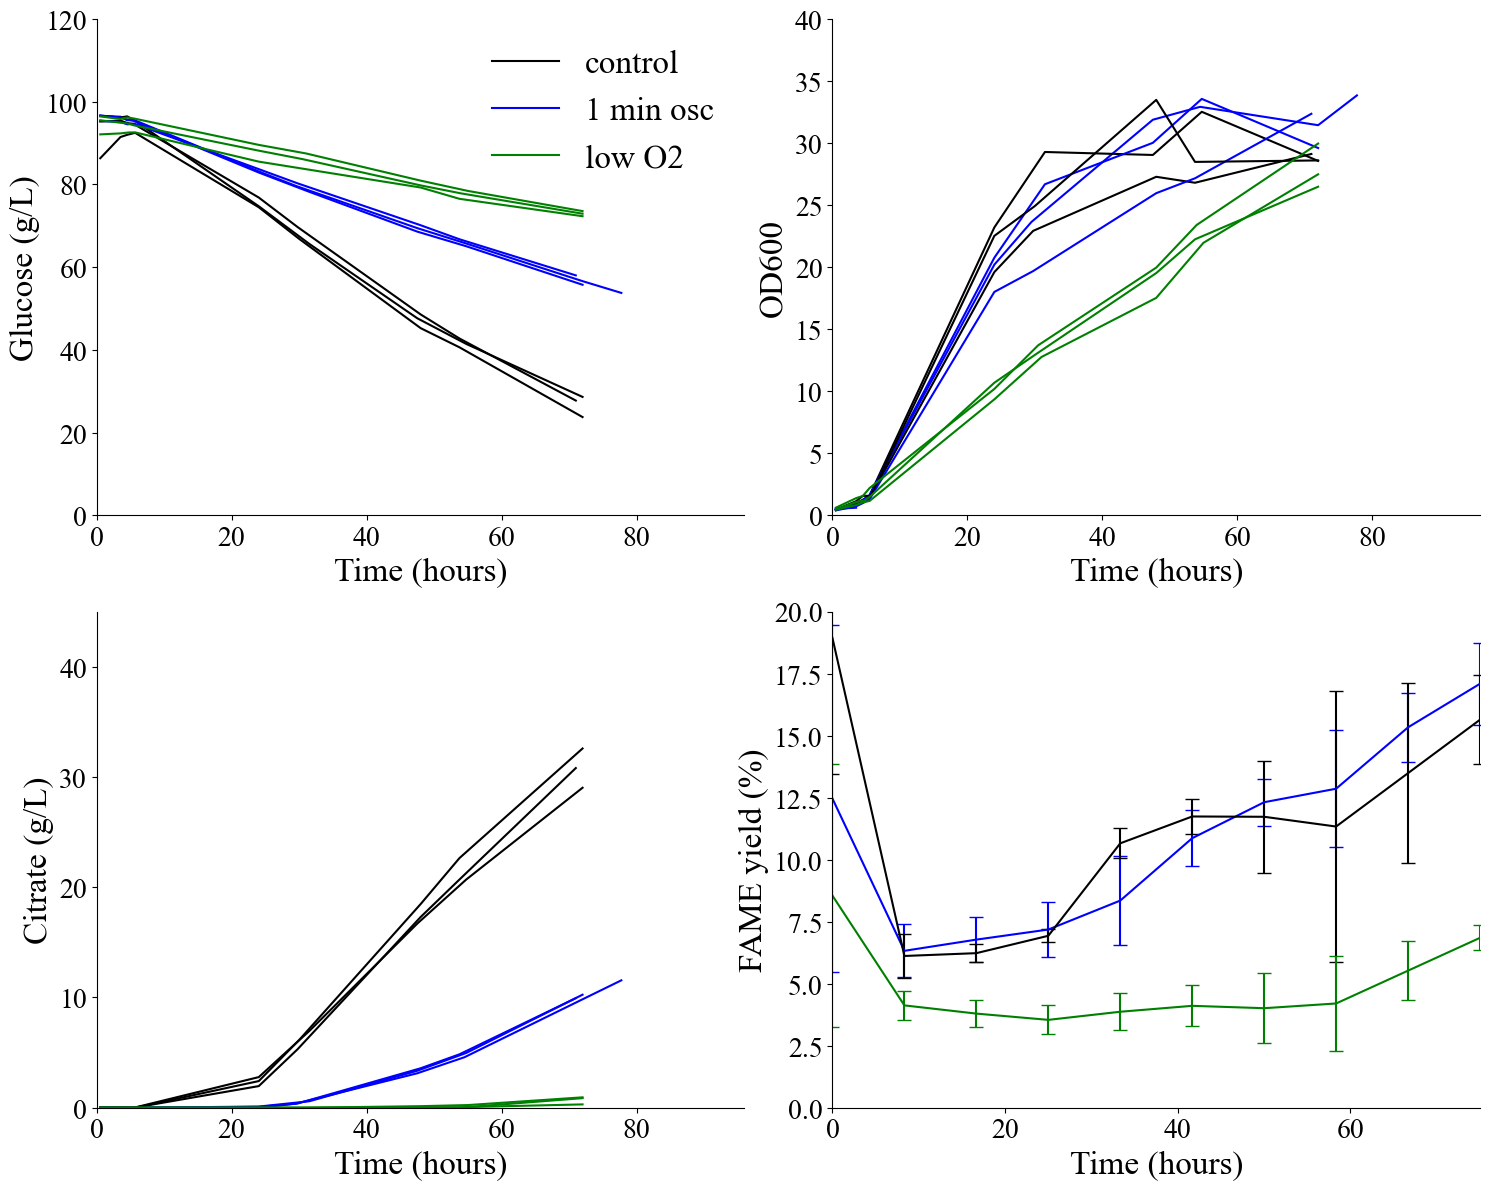

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# -----------------------------
# Define datasets and styles
# -----------------------------
storages = [
    (Biostat_29_r2, '1 min osc', 'blue', '-'),
    (Biostat_30_r1, 'Control', 'black', '-'),
    (Biostat_30_r2, '1 min osc', 'blue', '-'),
    (Biostat_31_r1, 'Control', 'black', '-'),
    (Biostat_31_r2, '1 min osc', 'blue', '-'),
    (Biostat_32_r1, 'Control', 'black', '-'),
    (Biostat_32_r2, 'low O2', 'green', '-'),
    (Biostat_33_r1, 'low O2', 'green', '-'),
    (Biostat_34_r1, 'low O2', 'green', '-'),
    # (Biostat_35_r1, 'high O2', 'red', '-'),
    # (Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),
    ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(
            store['hour'],
            store[y_col],
            label=label,
            color=color,
            linestyle=linestyle
        )
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: interpolated FAME
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
common_time_grid = np.linspace(0, 75, 10)

data_aggregated = {}

for store, label, color, linestyle in storages:
    if fame_yield_col in store.columns:
        if label not in data_aggregated:
            data_aggregated[label] = {
                'hour': [],
                'fame_yield': [],
                'color': color,
                'linestyle': linestyle
            }

        # Drop NaNs just in case
        valid = store[['hour', fame_yield_col]].dropna()

        # Interpolate onto common grid
        f_interp = interp1d(
            valid['hour'],
            valid[fame_yield_col],
            bounds_error=False,
            fill_value='extrapolate'
        )
        interpolated_y = f_interp(common_time_grid)

        data_aggregated[label]['hour'].append(common_time_grid)
        data_aggregated[label]['fame_yield'].append(interpolated_y)

# Compute averages/std and plot on 4th panel
idx_fame = 3

for label, group_data in data_aggregated.items():
    fame_array = np.array(group_data['fame_yield'])
    avg_fame = np.mean(fame_array, axis=0)
    std_fame = np.std(fame_array, axis=0)

    axs[idx_fame].errorbar(
        common_time_grid,
        avg_fame * 100,              # convert to %
        yerr=std_fame * 100,         # convert to %
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        capsize=5
    )

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 75)
axs[idx_fame].set_ylim(0, 20)  # adjust if needed
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['control', '1 min osc', 'low O2',]# 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    # plt.Line2D([0], [0], color='red', linestyle='-'),
]

axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
plt.savefig('Biostat_omicsPhenotypeComparison2_interpolatedFAME.png', bbox_inches='tight')
plt.show()


GROUPED TIMEPOINTS USED FOR ALL PANELS
[ 0.5  3.5  4.5  5.5 24.  30.  48.  54.  72. ]

RAW TIMEPOINTS BY CONDITION

Condition: 1 min osc
  Biostat_29_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.5 , 47.5 , 54.5 , 72.  , 77.75]
  Biostat_30_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]

Condition: Control
  Biostat_30_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]
  Biostat_32_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]

Condition: low O2
  Biostat_32_r2: [ 0.5 ,  3.5 ,  4.75,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]
  Biostat_33_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 30.5, 48. , 54. , 72. ]
  Biostat_34_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 31. , 48. , 55. , 72. ]


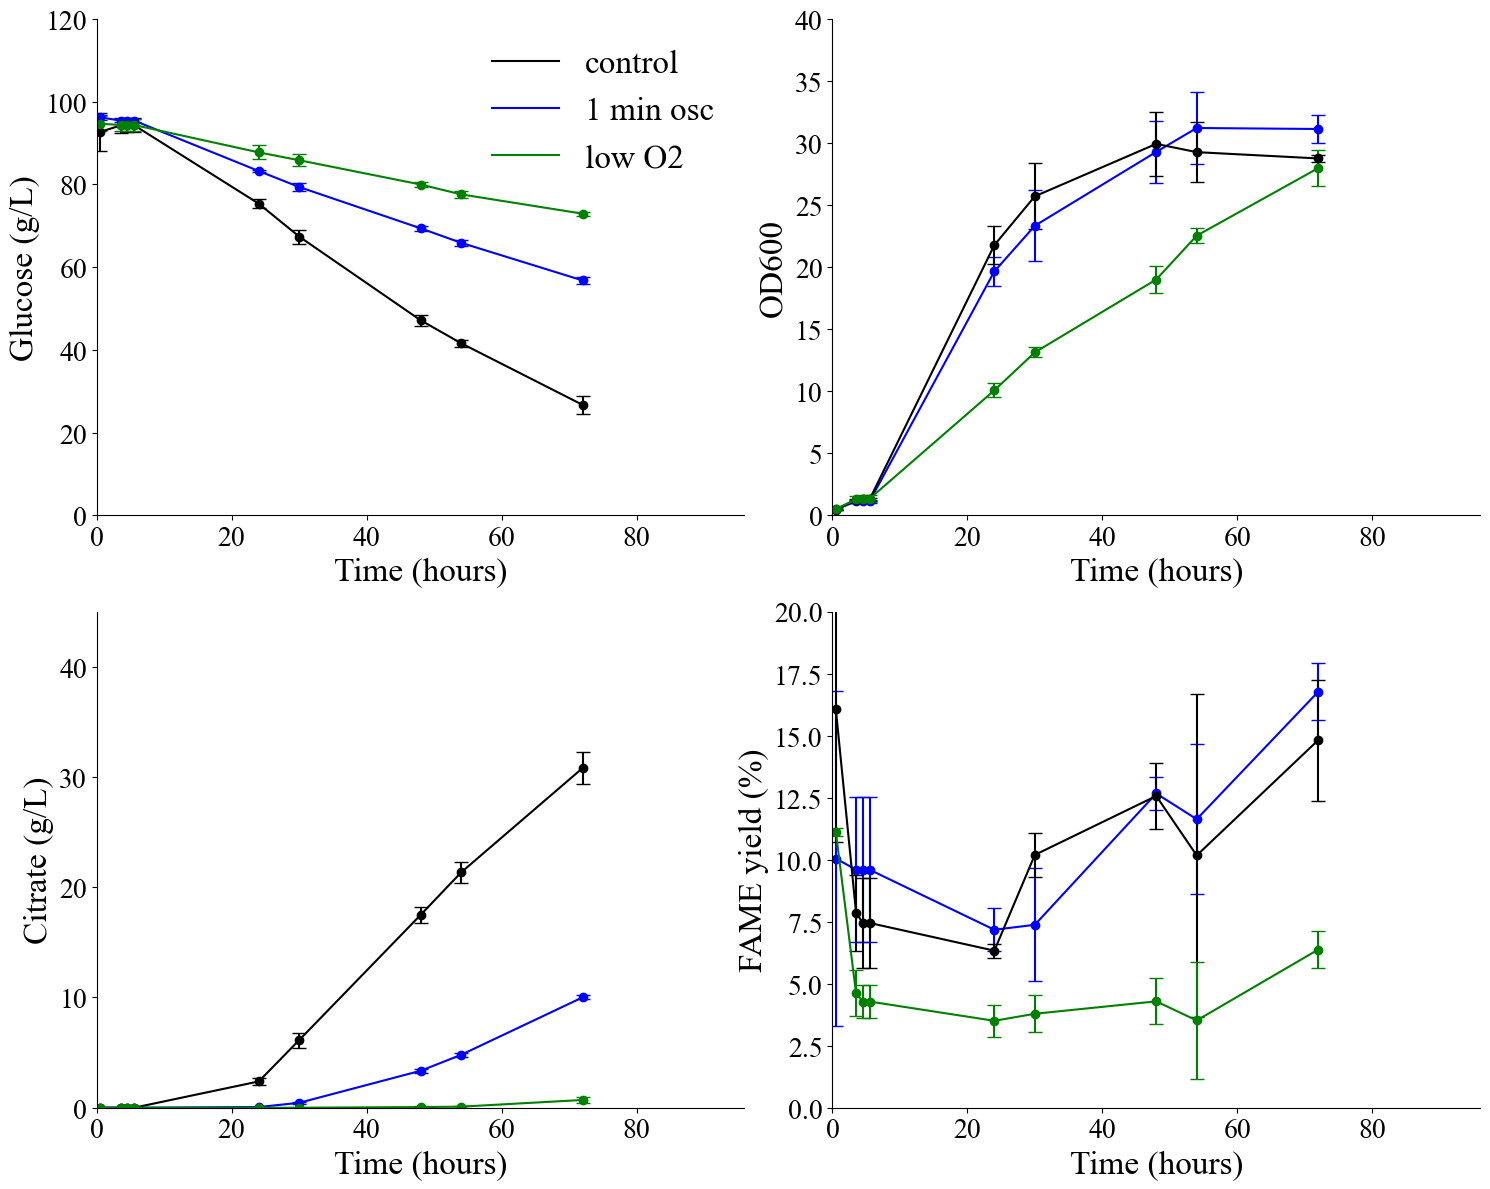

In [91]:


# -----------------------------
# Define grouped timepoints
# -----------------------------
grouped_timepoints = np.array([0.5, 3.5, 4.5, 5.5, 24.0, 30.0, 48.0, 54.0, 72.0])
tolerance = 2.0  # hours

# -----------------------------
# Define datasets and styles
# -----------------------------
storages_named = [
    ('Biostat_29_r2', Biostat_29_r2, '1 min osc', 'blue', '-'),
    ('Biostat_30_r1', Biostat_30_r1, 'Control', 'black', '-'),
    ('Biostat_30_r2', Biostat_30_r2, '1 min osc', 'blue', '-'),
    ('Biostat_31_r1', Biostat_31_r1, 'Control', 'black', '-'),
    ('Biostat_31_r2', Biostat_31_r2, '1 min osc', 'blue', '-'),
    ('Biostat_32_r1', Biostat_32_r1, 'Control', 'black', '-'),
    ('Biostat_32_r2', Biostat_32_r2, 'low O2', 'green', '-'),
    ('Biostat_33_r1', Biostat_33_r1, 'low O2', 'green', '-'),
    ('Biostat_34_r1', Biostat_34_r1, 'low O2', 'green', '-'),
    # ('Biostat_35_r1', Biostat_35_r1, 'high O2', 'red', '-'),
    # ('Biostat_35_r2', Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Helper function:
# bin each replicate to grouped timepoints
# -----------------------------
def bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance=2.0):
    valid = store[['hour', y_col]].dropna().copy()
    x = valid['hour'].to_numpy()
    y = valid[y_col].to_numpy()

    grouped_y = []
    for t0 in grouped_timepoints:
        diffs = np.abs(x - t0)
        in_bin = diffs <= tolerance

        if np.any(in_bin):
            grouped_y.append(np.mean(y[in_bin]))
        else:
            grouped_y.append(np.nan)

    return np.array(grouped_y)

# -----------------------------
# Optional: print grouping summary
# -----------------------------
print("\n" + "="*80)
print("GROUPED TIMEPOINTS USED FOR ALL PANELS")
print("="*80)
print(grouped_timepoints)

print("\n" + "="*80)
print("RAW TIMEPOINTS BY CONDITION")
print("="*80)

condition_times = {}
for name, store, label, color, linestyle in storages_named:
    times = store['hour'].dropna().to_numpy()
    condition_times.setdefault(label, []).append((name, times))

for label, reps in condition_times.items():
    print(f"\nCondition: {label}")
    for rep_name, times in reps:
        print(f"  {rep_name}: {np.array2string(times, precision=2, separator=', ')}")

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),
    ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    aggregated = {}

    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue

        grouped_y = bin_to_grouped_timepoints(
            store=store,
            y_col=y_col,
            grouped_timepoints=grouped_timepoints,
            tolerance=tolerance
        )

        if label not in aggregated:
            aggregated[label] = {
                'y_values': [],
                'color': color,
                'linestyle': linestyle
            }

        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        axs[idx].errorbar(
            grouped_timepoints,
            avg_y,
            yerr=std_y,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: FAME
# same grouped-time averaging approach
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
idx_fame = 3

aggregated_fame = {}

for name, store, label, color, linestyle in storages_named:
    if fame_yield_col not in store.columns:
        continue

    grouped_y = bin_to_grouped_timepoints(
        store=store,
        y_col=fame_yield_col,
        grouped_timepoints=grouped_timepoints,
        tolerance=tolerance
    )

    if label not in aggregated_fame:
        aggregated_fame[label] = {
            'y_values': [],
            'color': color,
            'linestyle': linestyle
        }

    aggregated_fame[label]['y_values'].append(grouped_y)

for label, group_data in aggregated_fame.items():
    y_array = np.array(group_data['y_values'])
    avg_y = np.nanmean(y_array, axis=0)
    std_y = np.nanstd(y_array, axis=0)

    axs[idx_fame].errorbar(
        grouped_timepoints,
        avg_y * 100,      # convert to %
        yerr=std_y * 100, # convert to %
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        marker='o',
        capsize=5
    )

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].set_ylim(0, 20)  # adjust if needed
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['control', '1 min osc', 'low O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
]

axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
# plt.savefig('Biostat_omicsPhenotypeComparison2_groupedAveragedAllPanels.png', bbox_inches='tight')
plt.show()

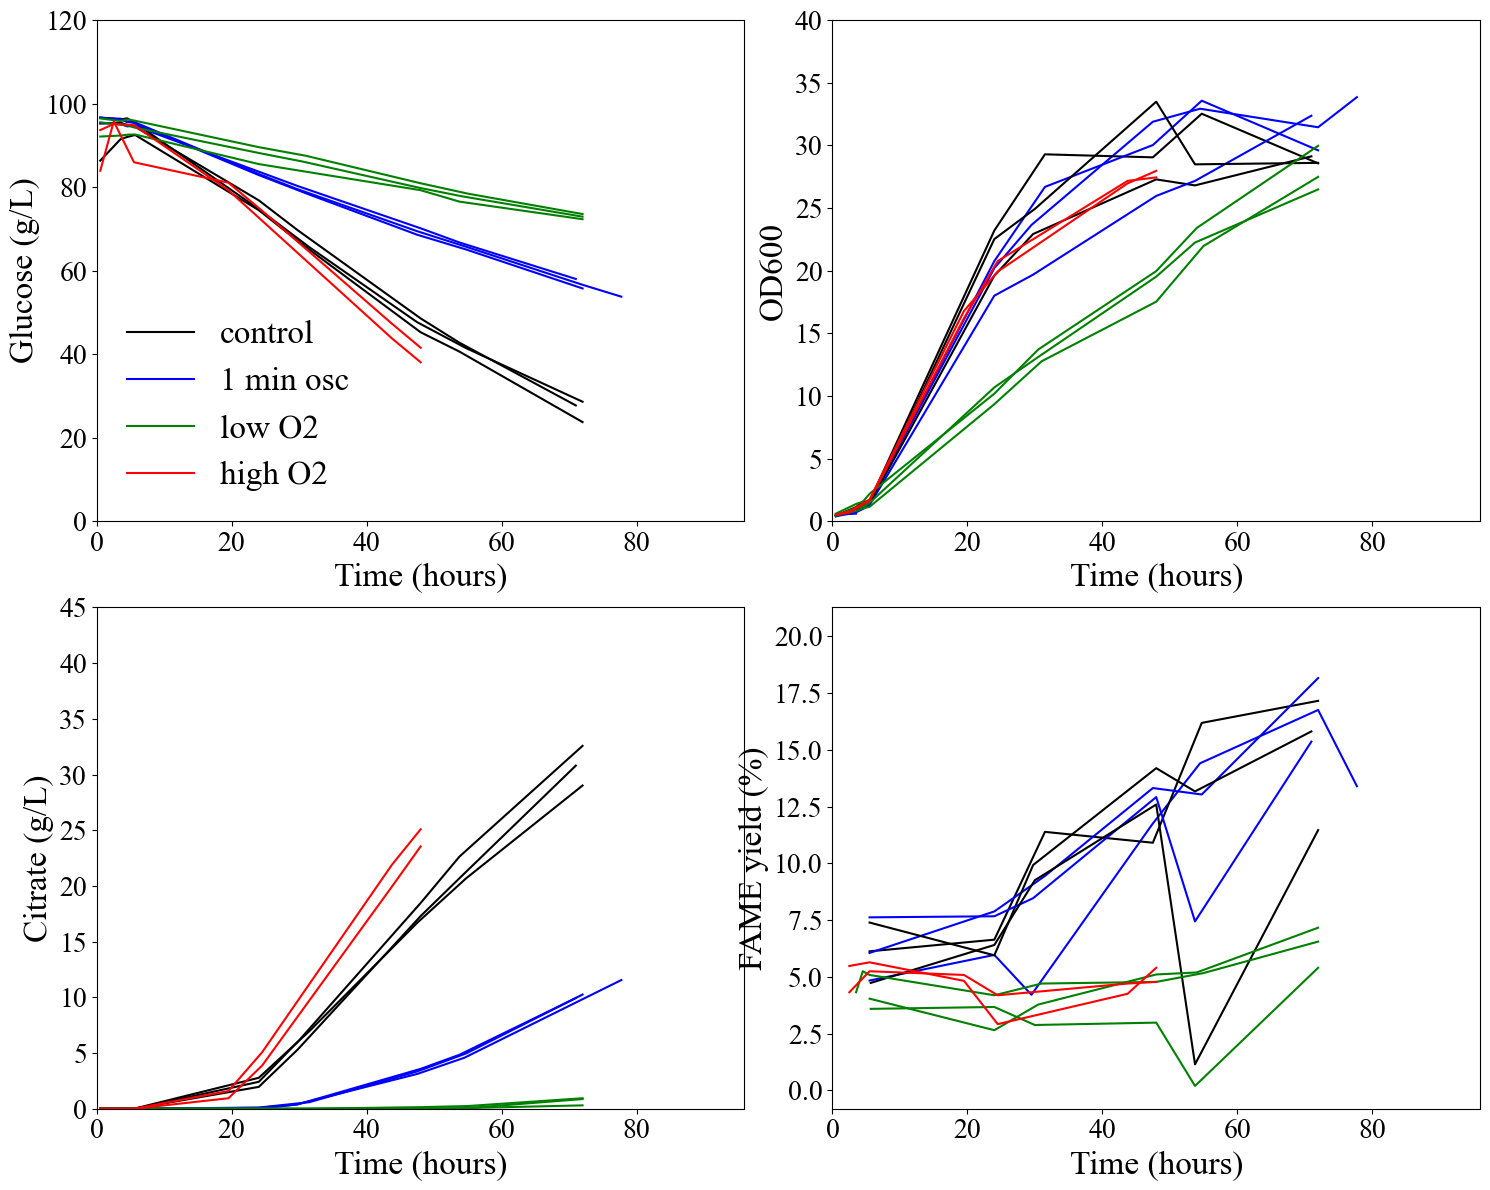

In [55]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #4
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 #5
    (Biostat_35_r1, 'High O2', 'red', '-'), # low O2 #4
    (Biostat_35_r2, 'High O2', 'red', '-'),  # low O2 #5
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('OD600', 'OD600', (0, 40)),

    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    # ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)



# # Define the datasets and their labels and plotting styles

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    (Biostat_35_r1, 'high O2', 'red', '-'), # oscillating
    (Biostat_35_r2, 'high O2', 'red', '-'),  # pO2 5% 
]
# # Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
        if "Biostat_23_r2" in label:
            axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
        elif "Biostat_22_r2" in label:
            axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
        else:
            axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control', '1 min osc', 'low O2', 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
# plt.savefig('Biostat_omicsPhenotypeComparison2.png')
plt.show()


## Averaged and grouped.


GROUPED TIMEPOINTS USED FOR ALL PANELS
[ 0.5  3.5  4.5  5.5 24.  30.  48.  54.  72. ]

RAW TIMEPOINTS BY CONDITION

Condition: 1 min osc
  Biostat_29_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.5 , 47.5 , 54.5 , 72.  , 77.75]
  Biostat_30_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]

Condition: Control
  Biostat_30_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]
  Biostat_32_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]

Condition: low O2
  Biostat_32_r2: [ 0.5 ,  3.5 ,  4.75,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]
  Biostat_33_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 30.5, 48. , 54. , 72. ]
  Biostat_34_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 31. , 48. , 55. , 72. ]


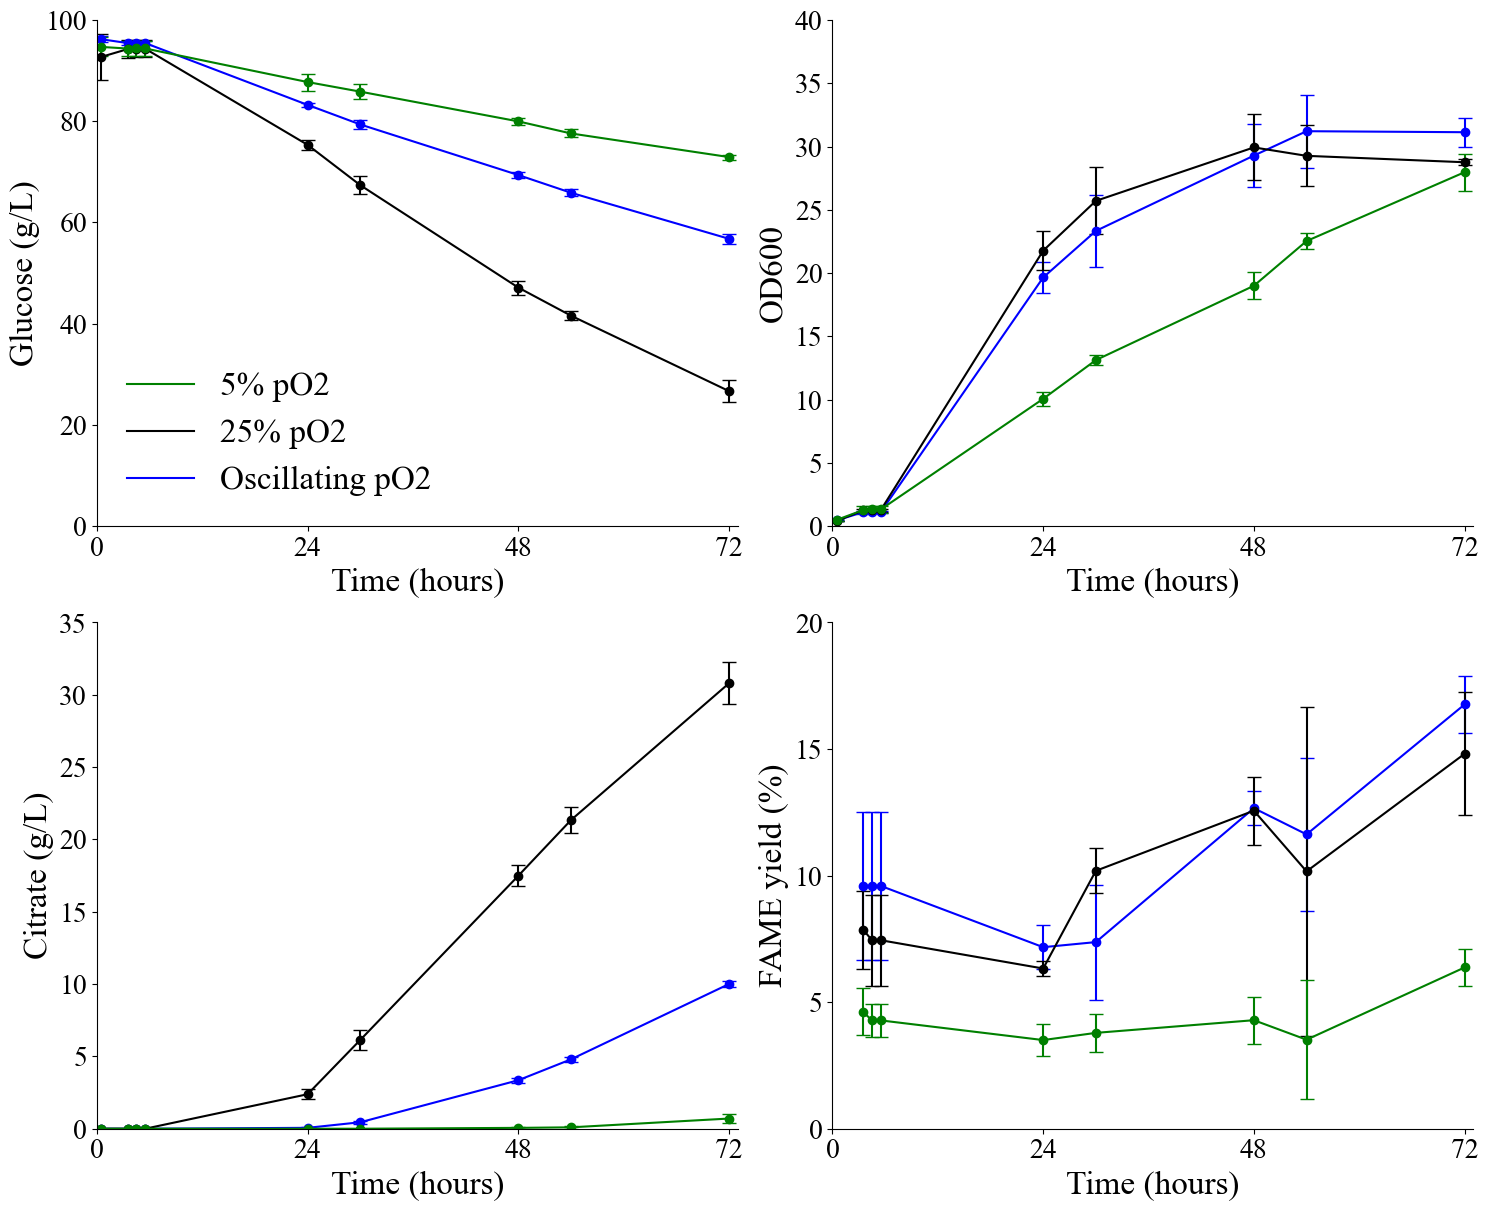

In [56]:
# -----------------------------
# Define grouped timepoints
# -----------------------------
grouped_timepoints = np.array([0.5, 3.5, 4.5, 5.5, 24.0, 30.0, 48.0, 54.0, 72.0])
tolerance = 2.0  # hours

# -----------------------------
# Define datasets and styles
# -----------------------------
storages_named = [
    ('Biostat_29_r2', Biostat_29_r2, '1 min osc', 'blue', '-'),
    ('Biostat_30_r1', Biostat_30_r1, 'Control', 'black', '-'),
    ('Biostat_30_r2', Biostat_30_r2, '1 min osc', 'blue', '-'),
    ('Biostat_31_r1', Biostat_31_r1, 'Control', 'black', '-'),
    ('Biostat_31_r2', Biostat_31_r2, '1 min osc', 'blue', '-'),
    ('Biostat_32_r1', Biostat_32_r1, 'Control', 'black', '-'),
    ('Biostat_32_r2', Biostat_32_r2, 'low O2', 'green', '-'),
    ('Biostat_33_r1', Biostat_33_r1, 'low O2', 'green', '-'),
    ('Biostat_34_r1', Biostat_34_r1, 'low O2', 'green', '-'),
    # ('Biostat_35_r1', Biostat_35_r1, 'high O2', 'red', '-'),
    # ('Biostat_35_r2', Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Helper function:
# bin each replicate to grouped timepoints
# -----------------------------
def bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance=2.0):
    valid = store[['hour', y_col]].dropna().copy()
    x = valid['hour'].to_numpy()
    y = valid[y_col].to_numpy()

    grouped_y = []
    for t0 in grouped_timepoints:
        diffs = np.abs(x - t0)
        in_bin = diffs <= tolerance

        if np.any(in_bin):
            grouped_y.append(np.mean(y[in_bin]))
        else:
            grouped_y.append(np.nan)

    return np.array(grouped_y)

# -----------------------------
# Optional: print grouping summary
# -----------------------------
print("\n" + "="*80)
print("GROUPED TIMEPOINTS USED FOR ALL PANELS")
print("="*80)
print(grouped_timepoints)

print("\n" + "="*80)
print("RAW TIMEPOINTS BY CONDITION")
print("="*80)

condition_times = {}
for name, store, label, color, linestyle in storages_named:
    times = store['hour'].dropna().to_numpy()
    condition_times.setdefault(label, []).append((name, times))

for label, reps in condition_times.items():
    print(f"\nCondition: {label}")
    for rep_name, times in reps:
        print(f"  {rep_name}: {np.array2string(times, precision=2, separator=', ')}")

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12.2))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 100)),
    ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
]

xticks_24h = np.arange(0, 75, 24)

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    aggregated = {}

    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue

        grouped_y = bin_to_grouped_timepoints(
            store=store,
            y_col=y_col,
            grouped_timepoints=grouped_timepoints,
            tolerance=tolerance
        )

        if label not in aggregated:
            aggregated[label] = {
                'y_values': [],
                'color': color,
                'linestyle': linestyle
            }

        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        axs[idx].errorbar(
            grouped_timepoints,
            avg_y,
            yerr=std_y,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 73)
    axs[idx].set_xticks(xticks_24h)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: FAME
# same grouped-time averaging approach as panels 1–3
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
idx_fame = 3

aggregated_fame = {}

for name, store, label, color, linestyle in storages_named:
    if fame_yield_col not in store.columns:
        continue

    grouped_y = bin_to_grouped_timepoints(
        store=store,
        y_col=fame_yield_col,
        grouped_timepoints=grouped_timepoints,
        tolerance=tolerance
    )

    if label not in aggregated_fame:
        aggregated_fame[label] = {
            'y_values': [],
            'color': color,
            'linestyle': linestyle
        }

    aggregated_fame[label]['y_values'].append(grouped_y)

# drop first timepoint for FAME panel only
fame_timepoints_plot = grouped_timepoints[1:]

for label, group_data in aggregated_fame.items():
    y_array = np.array(group_data['y_values'])
    avg_y = np.nanmean(y_array, axis=0)
    std_y = np.nanstd(y_array, axis=0)

    axs[idx_fame].errorbar(
        fame_timepoints_plot,
        avg_y[1:] * 100,
        yerr=std_y[1:] * 100,
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        marker='o',
        capsize=5
    )

# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].set_ylim(0, 20)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
# axs[idx_fame].spines['top'].set_visible(False)
# axs[idx_fame].spines['right'].set_visible(False)

# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_xlim(0, 73)
# axs[idx_fame].set_xticks(xticks_24h)
# axs[idx_fame].set_ylim(0, 20)  # adjust if needed
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
# axs[idx_fame].spines['top'].set_visible(False)
# axs[idx_fame].spines['right'].set_visible(False)

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 73)
axs[idx_fame].set_xticks(xticks_24h)
axs[idx_fame].set_ylim(0, 20)
axs[idx_fame].set_yticks(np.arange(0, 21, 5))
axs[idx_fame].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]

axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
plt.savefig('Biostat_omicsPhenotypeComparison2_groupedAveragedAllPanels.png', bbox_inches='tight')
plt.show()


GROUPED TIMEPOINTS USED FOR ALL PANELS
[ 0.5  3.5  4.5  5.5 24.  30.  48.  54.  72. ]

RAW TIMEPOINTS BY CONDITION

Condition: 1 min osc
  Biostat_29_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.5 , 47.5 , 54.5 , 72.  , 77.75]
  Biostat_30_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]

Condition: Control
  Biostat_30_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]
  Biostat_32_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]

Condition: low O2
  Biostat_32_r2: [ 0.5 ,  3.5 ,  4.75,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]
  Biostat_33_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 30.5, 48. , 54. , 72. ]
  Biostat_34_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 31. , 48. , 55. , 72. ]
[0.10043719 0.09593608 0.09593608 0.09593608 0.07172294 0.07373031
 0.12665042 0.1162862  0.16762169] 
 [

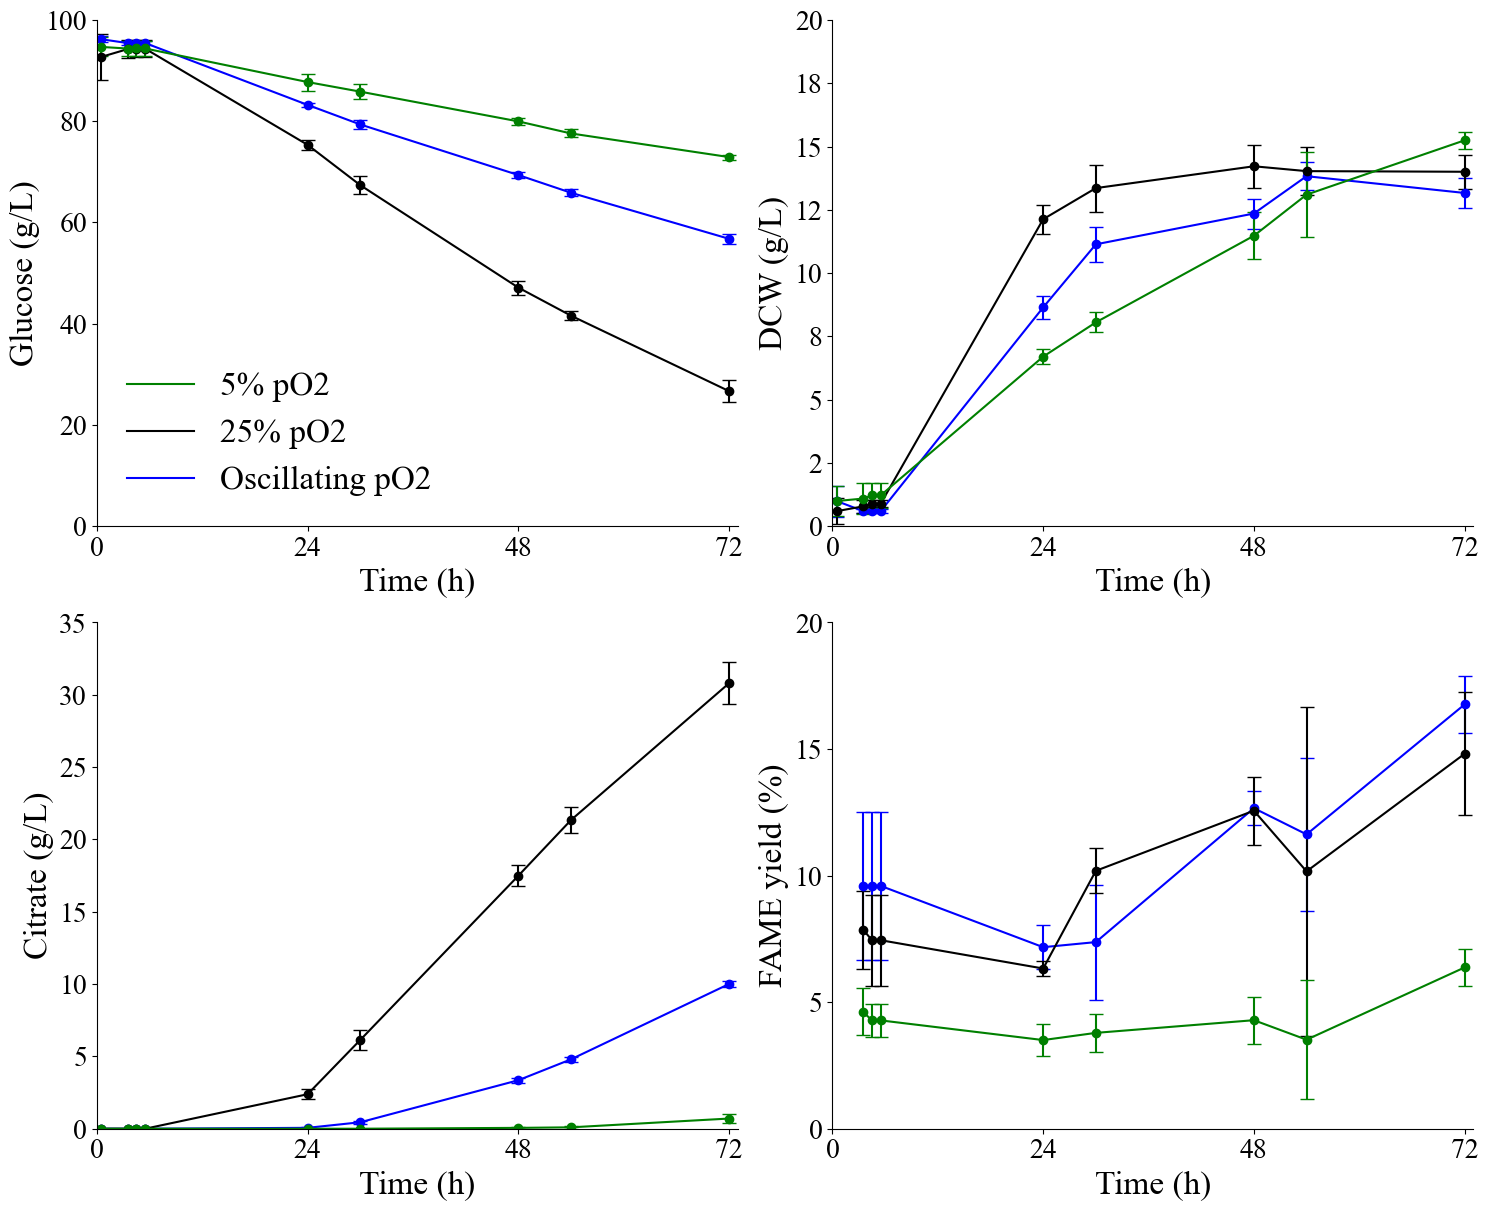

In [57]:


# -----------------------------
# Define grouped timepoints
# -----------------------------
grouped_timepoints = np.array([0.5, 3.5, 4.5, 5.5, 24.0, 30.0, 48.0, 54.0, 72.0])
tolerance = 2.0  # hours

# -----------------------------
# Define datasets and styles
# -----------------------------
storages_named = [
    ('Biostat_29_r2', Biostat_29_r2, '1 min osc', 'blue', '-'),
    ('Biostat_30_r1', Biostat_30_r1, 'Control', 'black', '-'),
    ('Biostat_30_r2', Biostat_30_r2, '1 min osc', 'blue', '-'),
    ('Biostat_31_r1', Biostat_31_r1, 'Control', 'black', '-'),
    ('Biostat_31_r2', Biostat_31_r2, '1 min osc', 'blue', '-'),
    ('Biostat_32_r1', Biostat_32_r1, 'Control', 'black', '-'),
    ('Biostat_32_r2', Biostat_32_r2, 'low O2', 'green', '-'),
    ('Biostat_33_r1', Biostat_33_r1, 'low O2', 'green', '-'),
    ('Biostat_34_r1', Biostat_34_r1, 'low O2', 'green', '-'),
    # ('Biostat_35_r1', Biostat_35_r1, 'high O2', 'red', '-'),
    # ('Biostat_35_r2', Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Helper function:
# bin each replicate to grouped timepoints
# -----------------------------
def bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance=2.0):
    valid = store[['hour', y_col]].dropna().copy()
    x = valid['hour'].to_numpy()
    y = valid[y_col].to_numpy()

    grouped_y = []
    for t0 in grouped_timepoints:
        diffs = np.abs(x - t0)
        in_bin = diffs <= tolerance

        if np.any(in_bin):
            grouped_y.append(np.mean(y[in_bin]))
        else:
            grouped_y.append(np.nan)

    return np.array(grouped_y)

# -----------------------------
# Optional: print grouping summary
# -----------------------------
print("\n" + "="*80)
print("GROUPED TIMEPOINTS USED FOR ALL PANELS")
print("="*80)
print(grouped_timepoints)

print("\n" + "="*80)
print("RAW TIMEPOINTS BY CONDITION")
print("="*80)

condition_times = {}
for name, store, label, color, linestyle in storages_named:
    times = store['hour'].dropna().to_numpy()
    condition_times.setdefault(label, []).append((name, times))

for label, reps in condition_times.items():
    print(f"\nCondition: {label}")
    for rep_name, times in reps:
        print(f"  {rep_name}: {np.array2string(times, precision=2, separator=', ')}")

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12.2))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 100)),
    ('DCW (g/L)', 'DCW (g/L)', (0, 20)),

    # ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
]

xticks_24h = np.arange(0, 75, 24)

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    aggregated = {}

    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue

        grouped_y = bin_to_grouped_timepoints(
            store=store,
            y_col=y_col,
            grouped_timepoints=grouped_timepoints,
            tolerance=tolerance
        )

        if label not in aggregated:
            aggregated[label] = {
                'y_values': [],
                'color': color,
                'linestyle': linestyle
            }

        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        axs[idx].errorbar(
            grouped_timepoints,
            avg_y,
            yerr=std_y,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 73)
    axs[idx].set_xticks(xticks_24h)
    axs[idx].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: FAME
# same grouped-time averaging approach as panels 1–3
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
idx_fame = 3

aggregated_fame = {}

for name, store, label, color, linestyle in storages_named:
    if fame_yield_col not in store.columns:
        continue

    grouped_y = bin_to_grouped_timepoints(
        store=store,
        y_col=fame_yield_col,
        grouped_timepoints=grouped_timepoints,
        tolerance=tolerance
    )

    if label not in aggregated_fame:
        aggregated_fame[label] = {
            'y_values': [],
            'color': color,
            'linestyle': linestyle
        }

    aggregated_fame[label]['y_values'].append(grouped_y)

# drop first timepoint for FAME panel only
fame_timepoints_plot = grouped_timepoints[1:]

for label, group_data in aggregated_fame.items():
    y_array = np.array(group_data['y_values'])
    avg_y = np.nanmean(y_array, axis=0)
    std_y = np.nanstd(y_array, axis=0)
    print( avg_y,'\n', std_y,label,'\n')

    axs[idx_fame].errorbar(
        fame_timepoints_plot,
        avg_y[1:] * 100,
        yerr=std_y[1:] * 100,
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        marker='o',
        capsize=5
    )


# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].set_ylim(0, 20)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
# axs[idx_fame].spines['top'].set_visible(False)
# axs[idx_fame].spines['right'].set_visible(False)

# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_xlim(0, 73)
# axs[idx_fame].set_xticks(xticks_24h)
# axs[idx_fame].set_ylim(0, 20)  # adjust if needed
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
# axs[idx_fame].spines['top'].set_visible(False)
# axs[idx_fame].spines['right'].set_visible(False)
for ax in axs.ravel():
    ax.set_xlabel("Time (h)")
axs[idx_fame].set_xlabel('Time (h)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 73)
axs[idx_fame].set_xticks(xticks_24h)
axs[idx_fame].set_ylim(0, 20)
axs[idx_fame].set_yticks(np.arange(0, 21, 5))
axs[idx_fame].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
# custom_lines = [
#     plt.Line2D([0], [0], color='black', linestyle='-'),
#     plt.Line2D([0], [0], color='blue', linestyle='-'),
#     plt.Line2D([0], [0], color='green', linestyle='-'),
# ]

custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
plt.savefig('Biostat_omicsPhenotypeComparison2_groupedAveragedAllPanels.png', bbox_inches='tight')
plt.show()

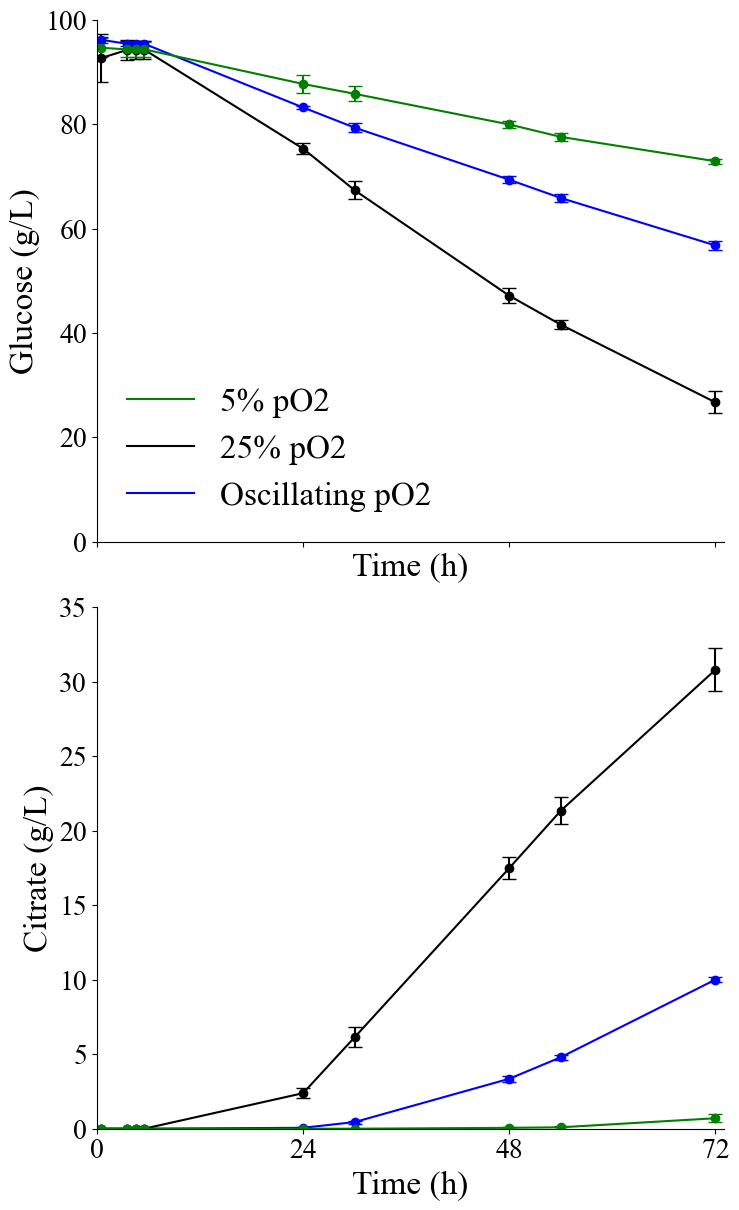

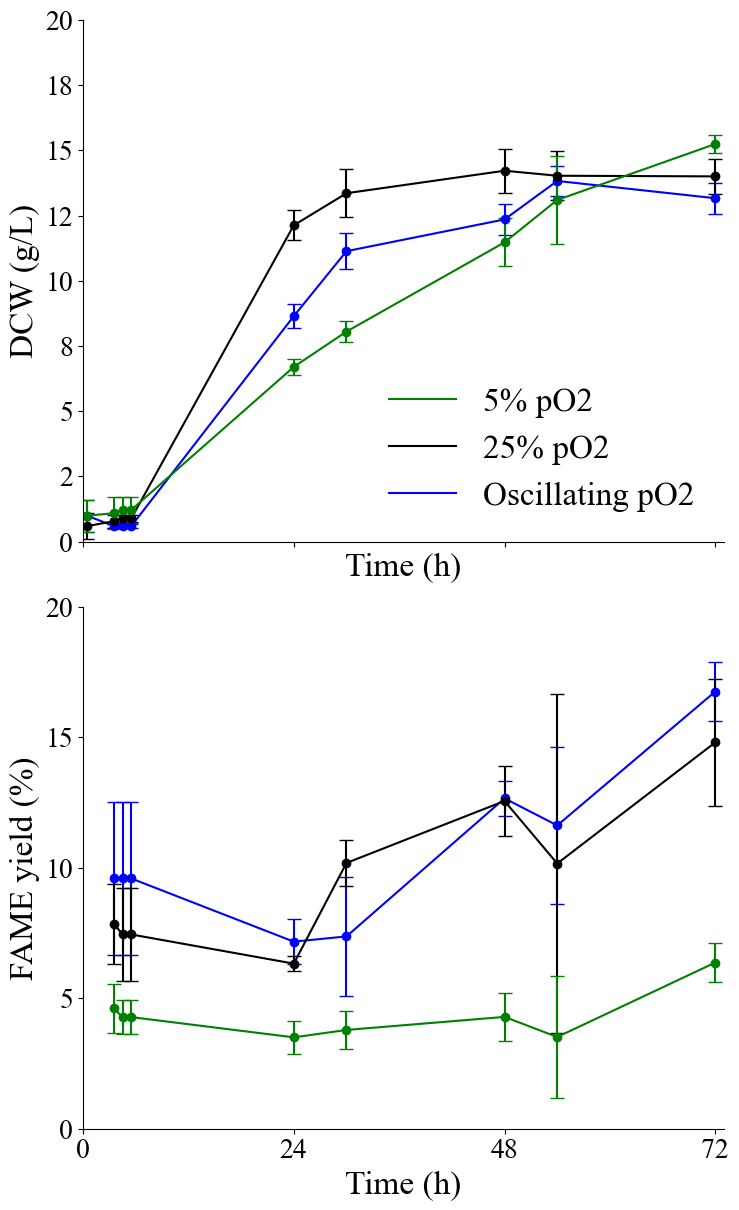

In [58]:


# --- keep your grouped_timepoints, tolerance, storages_named, bin_to_grouped_timepoints as-is ---

xticks_24h = np.arange(0, 75, 24)

def plot_panel(ax, y_col, y_label, y_lim, grouped_timepoints, tolerance, storages_named):
    aggregated = {}
    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue
        grouped_y = bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance)
        aggregated.setdefault(label, {'y_values': [], 'color': color, 'linestyle': linestyle})
        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        ax.errorbar(
            grouped_timepoints, avg_y, yerr=std_y,
            label=label, color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o', capsize=5
        )

    ax.set_xlabel("Time (h)", fontsize=24)
    ax.set_ylabel(y_label, fontsize=24)
    ax.set_ylim(*y_lim)
    ax.set_xlim(0, 73)
    ax.set_xticks(xticks_24h)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def plot_fame_panel(ax, fame_yield_col, grouped_timepoints, tolerance, storages_named):
    aggregated_fame = {}
    for name, store, label, color, linestyle in storages_named:
        if fame_yield_col not in store.columns:
            continue
        grouped_y = bin_to_grouped_timepoints(store, fame_yield_col, grouped_timepoints, tolerance)
        aggregated_fame.setdefault(label, {'y_values': [], 'color': color, 'linestyle': linestyle})
        aggregated_fame[label]['y_values'].append(grouped_y)

    # drop first timepoint for FAME panel only
    fame_timepoints_plot = grouped_timepoints[1:]

    for label, group_data in aggregated_fame.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        ax.errorbar(
            fame_timepoints_plot,
            avg_y[1:] * 100,
            yerr=std_y[1:] * 100,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    ax.set_xlabel("Time (h)", fontsize=24)
    ax.set_ylabel("FAME yield (%)", fontsize=24)
    ax.set_xlim(0, 73)
    ax.set_xticks(xticks_24h)
    ax.set_ylim(0, 20)
    ax.set_yticks(np.arange(0, 21, 5))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# -----------------------------
# Shared legend setup (your custom order)
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]

# =============================
# FIGURE 1 (left column): Glucose + DCW
# =============================
fig1, axs1 = plt.subplots(2, 1, figsize=(7.5, 12.2), sharex=True)
axs1 = axs1.flatten()

# FIGURE 1 (left column): Glucose + Citrate
plot_panel(axs1[0], 'Glucose.1', 'Glucose (g/L)', (0, 100),
           grouped_timepoints, tolerance, storages_named)
plot_panel(axs1[1], 'Citric Acid.1', 'Citrate (g/L)', (0, 35),
           grouped_timepoints, tolerance, storages_named)

axs1[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)






fig1.tight_layout()
fig1.savefig('Biostat_leftColumn_Glucose_DCW.png', bbox_inches='tight', dpi=300)

# =============================
# FIGURE 2 (right column): Citrate + FAME
# =============================
fig2, axs2 = plt.subplots(2, 1, figsize=(7.5, 12.2), sharex=True)
axs2 = axs2.flatten()

# FIGURE 2 (right column): DCW + FAME
plot_panel(axs2[0], 'DCW (g/L)', 'DCW (g/L)', (0, 20),
           grouped_timepoints, tolerance, storages_named)
plot_fame_panel(axs2[1], 'FAME yield (g/g biomass)',
                grouped_timepoints, tolerance, storages_named)

# (optional) put legend here instead, or on both figures
axs2[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

fig2.tight_layout()
fig2.savefig('Biostat_rightColumn_Citrate_FAME.png', bbox_inches='tight', dpi=300)

plt.show()


GROUPED TIMEPOINTS USED FOR ALL PANELS
[ 0.5  3.5  4.5  5.5 24.  30.  48.  54.  72. ]

RAW TIMEPOINTS BY CONDITION

Condition: 1 min osc
  Biostat_29_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.5 , 47.5 , 54.5 , 72.  , 77.75]
  Biostat_30_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]

Condition: Control
  Biostat_30_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]
  Biostat_32_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]

Condition: low O2
  Biostat_32_r2: [ 0.5 ,  3.5 ,  4.75,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]
  Biostat_33_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 30.5, 48. , 54. , 72. ]
  Biostat_34_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 31. , 48. , 55. , 72. ]


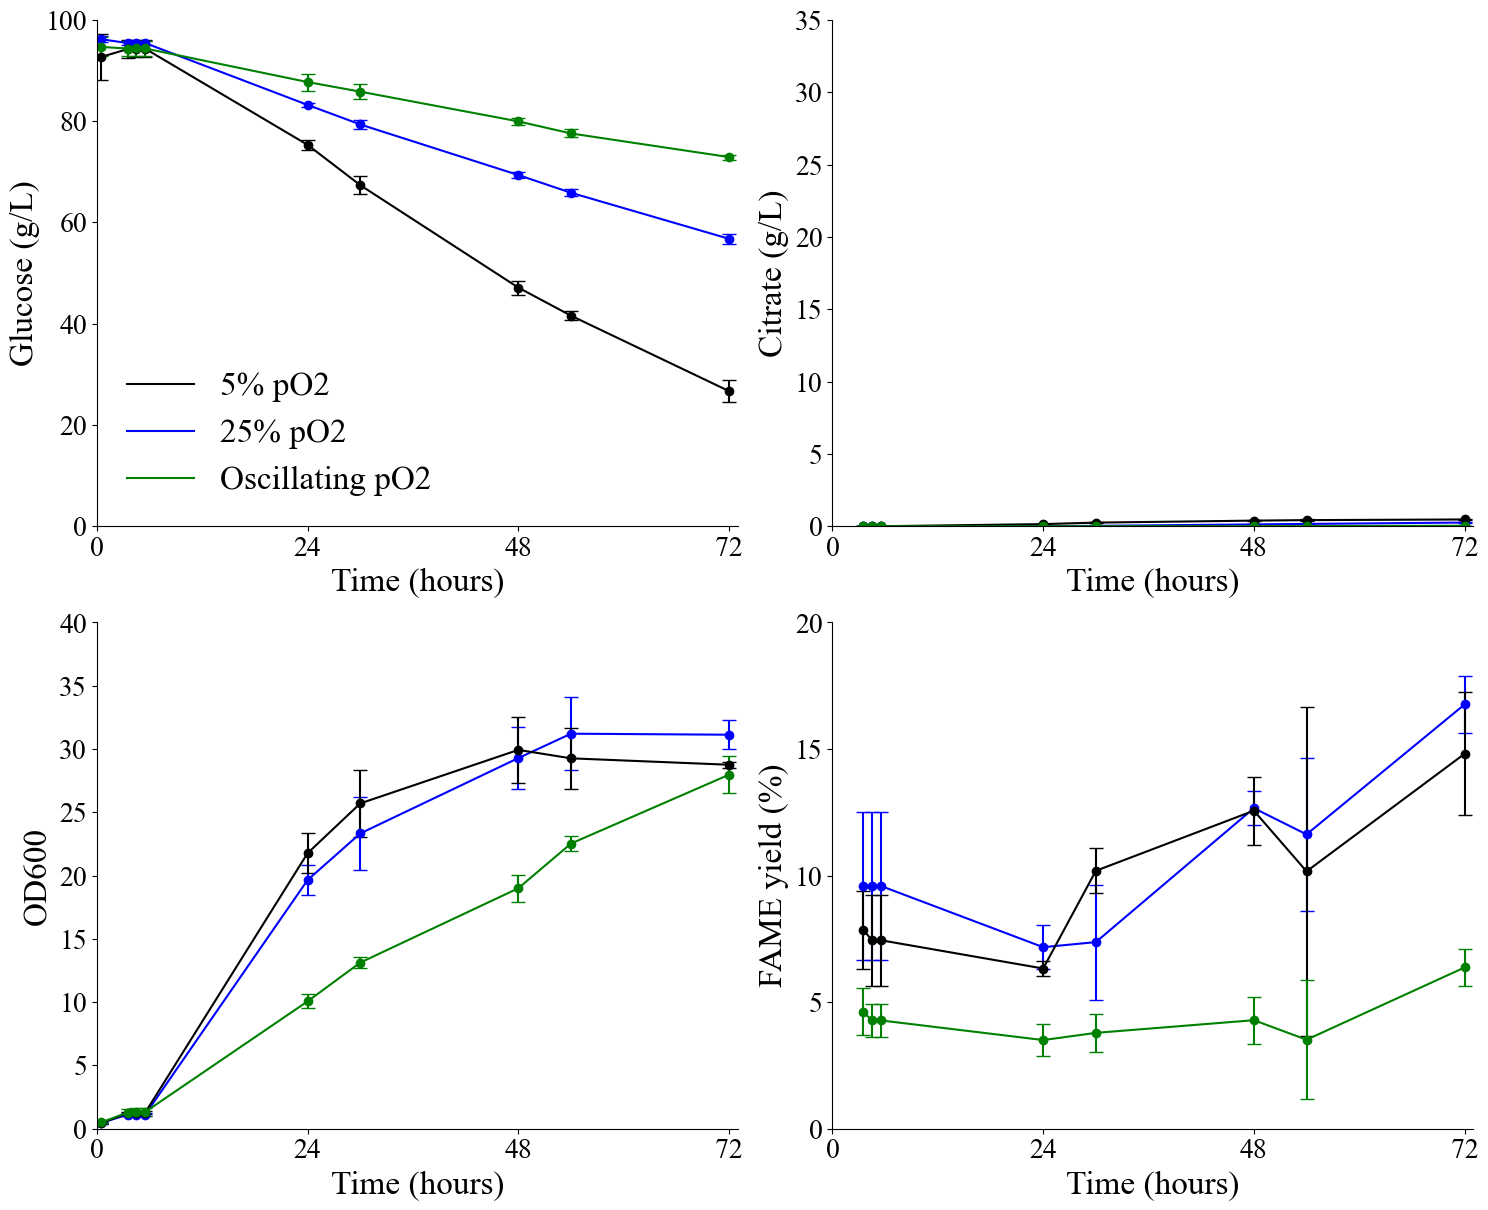

,Panel,Condition,Timepoint_h,Mean,StDev
0,Citrate (g/L),1 min osc,0.5,NaN,NaN
1,Citrate (g/L),1 min osc,3.5,0.000000,0.000000
2,Citrate (g/L),1 min osc,4.5,0.000000,0.000000
3,Citrate (g/L),1 min osc,5.5,0.000000,0.000000
4,Citrate (g/L),1 min osc,24.0,0.004513,0.003250
...,...,...,...,...,...
100,OD600,low O2,24.0,10.066667,0.552891
101,OD600,low O2,30.0,13.126667,0.410636
102,OD600,low O2,48.0,19.000000,1.061822
103,OD600,low O2,54.0,22.533333,0.623396


In [59]:


# -----------------------------
# Define grouped timepoints
# -----------------------------
grouped_timepoints = np.array([0.5, 3.5, 4.5, 5.5, 24.0, 30.0, 48.0, 54.0, 72.0])
tolerance = 2.0  # hours

# -----------------------------
# Define datasets and styles
# -----------------------------
storages_named = [
    ('Biostat_29_r2', Biostat_29_r2, '1 min osc', 'blue', '-'),
    ('Biostat_30_r1', Biostat_30_r1, 'Control', 'black', '-'),
    ('Biostat_30_r2', Biostat_30_r2, '1 min osc', 'blue', '-'),
    ('Biostat_31_r1', Biostat_31_r1, 'Control', 'black', '-'),
    ('Biostat_31_r2', Biostat_31_r2, '1 min osc', 'blue', '-'),
    ('Biostat_32_r1', Biostat_32_r1, 'Control', 'black', '-'),
    ('Biostat_32_r2', Biostat_32_r2, 'low O2', 'green', '-'),
    ('Biostat_33_r1', Biostat_33_r1, 'low O2', 'green', '-'),
    ('Biostat_34_r1', Biostat_34_r1, 'low O2', 'green', '-'),
    # ('Biostat_35_r1', Biostat_35_r1, 'high O2', 'red', '-'),
    # ('Biostat_35_r2', Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Helper function:
# bin each replicate to grouped timepoints
# -----------------------------
def bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance=2.0):
    valid = store[['hour', y_col]].dropna().copy()
    x = valid['hour'].to_numpy()
    y = valid[y_col].to_numpy()

    grouped_y = []
    for t0 in grouped_timepoints:
        diffs = np.abs(x - t0)
        in_bin = diffs <= tolerance

        if np.any(in_bin):
            grouped_y.append(np.mean(y[in_bin]))
        else:
            grouped_y.append(np.nan)

    return np.array(grouped_y)

# -----------------------------
# Collect averages + stdev in a dataframe
# -----------------------------
summary_rows = []

def collect_condition_stats(panel_name, label, timepoints, avg_y, std_y):
    for t, mean_val, std_val in zip(timepoints, avg_y, std_y):
        summary_rows.append({
            "Panel": panel_name,
            "Condition": label,
            "Timepoint_h": t,
            "Mean": mean_val,
            "StDev": std_val
        })

# -----------------------------
# Optional: print grouping summary
# -----------------------------
print("\n" + "="*80)
print("GROUPED TIMEPOINTS USED FOR ALL PANELS")
print("="*80)
print(grouped_timepoints)

print("\n" + "="*80)
print("RAW TIMEPOINTS BY CONDITION")
print("="*80)

condition_times = {}
for name, store, label, color, linestyle in storages_named:
    times = store['hour'].dropna().to_numpy()
    condition_times.setdefault(label, []).append((name, times))

for label, reps in condition_times.items():
    print(f"\nCondition: {label}")
    for rep_name, times in reps:
        print(f"  {rep_name}: {np.array2string(times, precision=2, separator=', ')}")

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12.2))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 100)),
    ('citrate yield', 'Citrate (g/L)', (0, 35)),

    ('OD600', 'OD600', (0, 40)),
    # ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),

]

xticks_24h = np.arange(0, 75, 24)

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    aggregated = {}

    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue

        grouped_y = bin_to_grouped_timepoints(
            store=store,
            y_col=y_col,
            grouped_timepoints=grouped_timepoints,
            tolerance=tolerance
        )

        if label not in aggregated:
            aggregated[label] = {
                'y_values': [],
                'color': color,
                'linestyle': linestyle
            }

        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        collect_condition_stats(y_label, label, grouped_timepoints, avg_y, std_y)

        axs[idx].errorbar(
            grouped_timepoints,
            avg_y,
            yerr=std_y,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 73)
    axs[idx].set_xticks(xticks_24h)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: FAME
# same grouped-time averaging approach as panels 1–3
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
idx_fame = 3

aggregated_fame = {}

for name, store, label, color, linestyle in storages_named:
    if fame_yield_col not in store.columns:
        continue

    grouped_y = bin_to_grouped_timepoints(
        store=store,
        y_col=fame_yield_col,
        grouped_timepoints=grouped_timepoints,
        tolerance=tolerance
    )

    if label not in aggregated_fame:
        aggregated_fame[label] = {
            'y_values': [],
            'color': color,
            'linestyle': linestyle
        }

    aggregated_fame[label]['y_values'].append(grouped_y)

# drop first timepoint for FAME panel only
fame_timepoints_plot = grouped_timepoints[1:]

for label, group_data in aggregated_fame.items():
    y_array = np.array(group_data['y_values'])
    avg_y = np.nanmean(y_array, axis=0)
    std_y = np.nanstd(y_array, axis=0)

    avg_y_plot = avg_y[1:] * 100
    std_y_plot = std_y[1:] * 100

    collect_condition_stats("FAME yield (%)", label, fame_timepoints_plot, avg_y_plot, std_y_plot)

    axs[idx_fame].errorbar(
        fame_timepoints_plot,
        avg_y_plot,
        yerr=std_y_plot,
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        marker='o',
        capsize=5
    )

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 73)
axs[idx_fame].set_xticks(xticks_24h)
axs[idx_fame].set_ylim(0, 20)
axs[idx_fame].set_yticks(np.arange(0, 21, 5))
axs[idx_fame].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
]

axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
# plt.savefig('Biostat_omicsPhenotypeComparison2_groupedAveragedAllPanels.png', bbox_inches='tight')
plt.show()

# -----------------------------
# Save stats for later lookup
# -----------------------------
condition_averages_df = pd.DataFrame(summary_rows)
condition_averages_df = condition_averages_df.sort_values(
    ["Panel", "Condition", "Timepoint_h"]
).reset_index(drop=True)

condition_averages_df

In [21]:
# condition_averages_df.to_csv('figure_data_yield.csv')

In [60]:
condition_averages_df

,Panel,Condition,Timepoint_h,Mean,StDev
0,Citrate (g/L),1 min osc,0.5,NaN,NaN
1,Citrate (g/L),1 min osc,3.5,0.000000,0.000000
2,Citrate (g/L),1 min osc,4.5,0.000000,0.000000
3,Citrate (g/L),1 min osc,5.5,0.000000,0.000000
4,Citrate (g/L),1 min osc,24.0,0.004513,0.003250
...,...,...,...,...,...
100,OD600,low O2,24.0,10.066667,0.552891
101,OD600,low O2,30.0,13.126667,0.410636
102,OD600,low O2,48.0,19.000000,1.061822
103,OD600,low O2,54.0,22.533333,0.623396


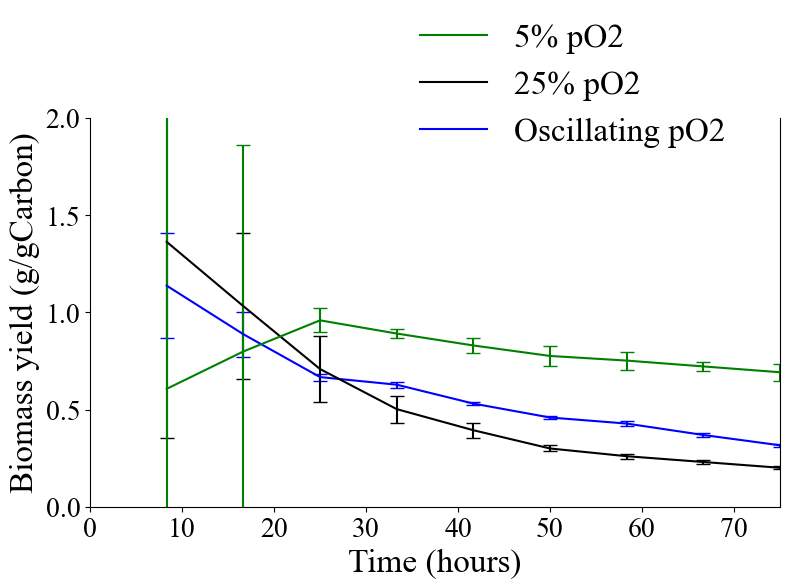

In [61]:


# Define storages and their labels and plotting styles
storages = [
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'),  # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'),  # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'),   # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'),   # low O2 #2
    (Biostat_34_r1, 'low O2', 'green', '-'),   # low O2 #3
    # (Biostat_35_r1, 'high O2', 'red', '-'),    # high O2 #1
    # (Biostat_35_r2, 'high O2', 'red', '-'),    # high O2 #2
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('biomass yield', 'Biomass yield (g/gCarbon)', (0, 2)),
]

# Define a common time grid for interpolation
common_time_grid = np.linspace(0, 75, 10)

# Aggregate data by label with interpolation
data_aggregated = {}
for store, label, color, linestyle in storages:
    if label not in data_aggregated:
        data_aggregated[label] = {'hour': [], 'biomass yield': []}
    f_hour = interp1d(store['hour'], store['biomass yield'], bounds_error=False, fill_value='extrapolate')
    interpolated_yield = f_hour(common_time_grid)
    data_aggregated[label]['hour'].append(common_time_grid)
    data_aggregated[label]['biomass yield'].append(interpolated_yield)

# Compute averages and standard deviations
for label in data_aggregated:
    fame_yields = np.array(data_aggregated[label]['biomass yield'])
    avg_fame_yields = np.mean(fame_yields, axis=0)
    std_fame_yields = np.std(fame_yields, axis=0)
    data_aggregated[label]['avg_hour'] = common_time_grid
    data_aggregated[label]['avg_fame_yield'] = avg_fame_yields
    data_aggregated[label]['std_fame_yield'] = std_fame_yields

# Create a plot
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

for (y_col, y_label, y_lim) in plot_pairs:
    for label in data_aggregated:
        color = storages[[i for i, s in enumerate(storages) if s[1] == label][0]][2]
        linestyle = storages[[i for i, s in enumerate(storages) if s[1] == label][0]][3]
        axs.errorbar(
            data_aggregated[label]['avg_hour'],
            data_aggregated[label]['avg_fame_yield'],
            yerr=data_aggregated[label]['std_fame_yield'],
            label=label,
            color=color,
            linestyle=linestyle,
            capsize=5
        )
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Custom legend
custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']

custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    # plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fig.legend(custom_lines, custom_labels, fontsize=24, bbox_to_anchor=(0.95, 1.2), frameon=False)

plt.tight_layout()

axs.spines['top'].set_visible(False)

plt.savefig('Biostat_omicsPhenotypeComparison_DCW.png', bbox_inches='tight')

plt.show()


Bounding box dimensions (in pixels): (0.0, 0.0, 800.0, 500.0)
Bounding box dimensions (in inches): [0.0, 0.0, 8.0, 5.0]


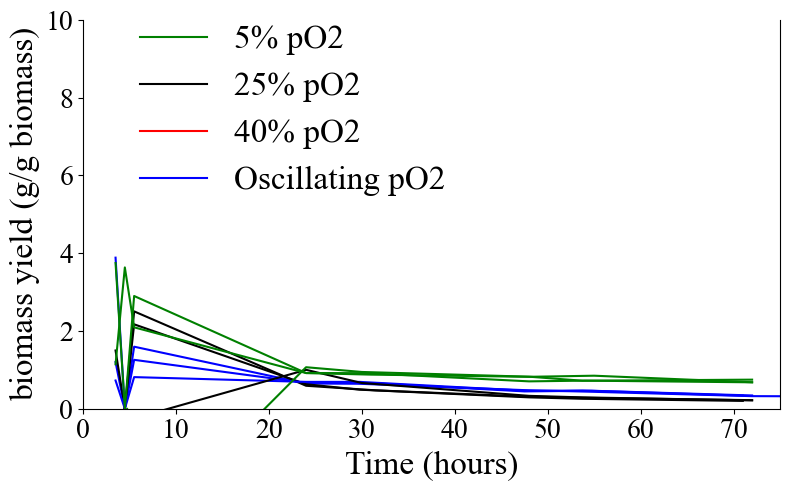

In [62]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    # (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    # (Biostat_35_r2, 'high O2', 'red', '-'), # high O2

]

# Define the y-axis labels and their limits for each subplot
# plot_pairs = [
#     # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
#     # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
#     ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
# ]
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('specific_µ_DCW', 'specific_µ_DCW', (0, .25)),
    # ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    # ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
    # ('specific citrate yield (g/g substrate)', 'Citrate yield (g/gCarbon)', (0, .2)),
    # ('FAME yield (g/g biomass)', 'FAME yield (g/g biomass)', (0, .2)),
    ('biomass yield', 'biomass yield (g/g biomass)', (0, 10)),

]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
# axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs.plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['Low oxygen', 'Sufficient oxygen', 'High oxygen', 'Oscillating oxygen',]
custom_labels = ['5% pO2', '25% pO2', '40% pO2', 'Oscillating pO2',]

custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24,bbox_to_anchor=(0.6, 1), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout()

axs.spines['top'].set_visible(False)

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison_highO2_biomassyield.png', bbox_inches='tight')
# Get the bounding box dimensions
bbox_dims = fig.bbox.bounds
print(f"Bounding box dimensions (in pixels): {bbox_dims}")

# Convert bounding box dimensions to inches
bbox_inches = [dim / fig.dpi for dim in bbox_dims]
print(f"Bounding box dimensions (in inches): {bbox_inches}")

plt.show()



### processData. 

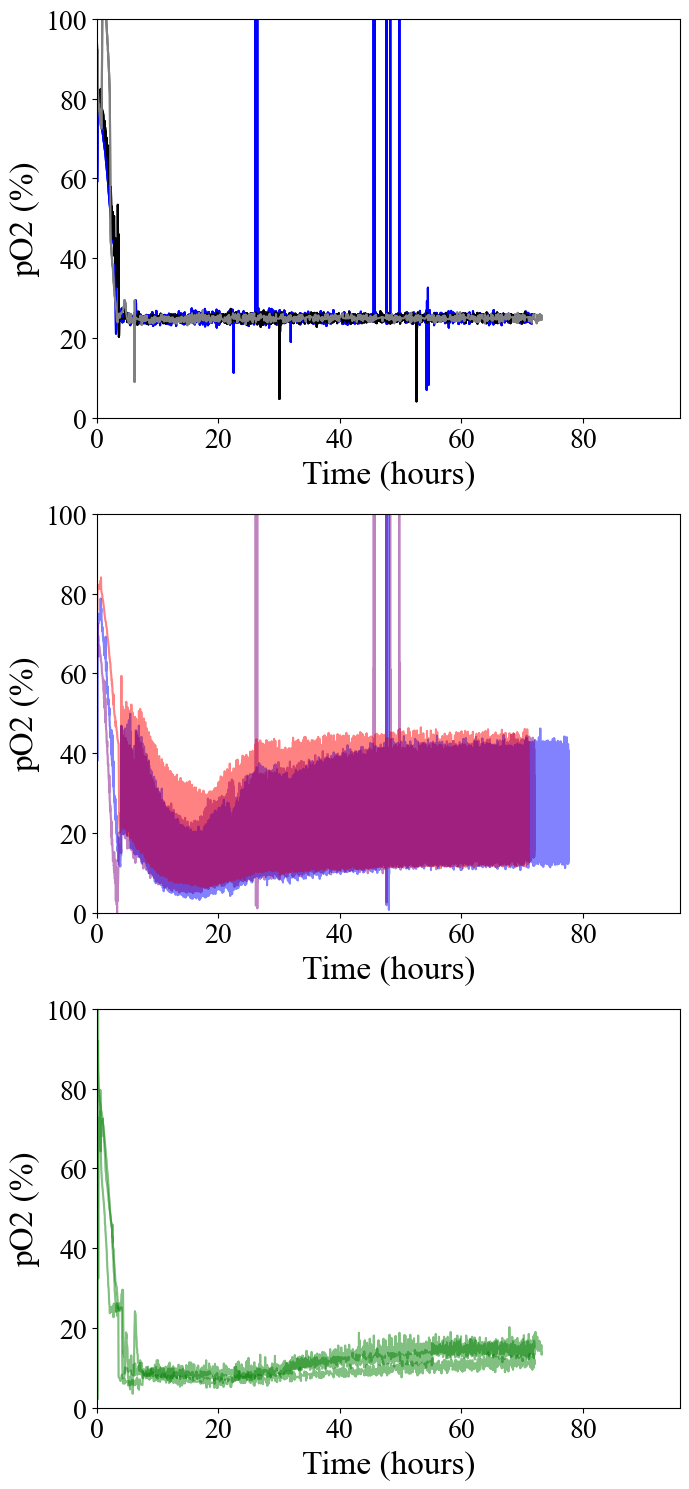

In [63]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(3, 1, figsize=(7, 15))

# # Define the datasets and their labels and plotting styles
# storages = [
#     (storage_21_r1, 'Control (25% pO2)', 'black', '-'), # control
#     (storage_21_r2, '1 min osc', 'yellow', '-'), # oscillating
#     (storage_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
#     (storage_23_r2, '1 min osc', 'blue', '-'), # oscillating
#     (storage_24_r1, 'Control', 'black', '-'), # control
#     (storage_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
#     (storage_26_r1, 'low O2', 'red', '-'), # pO2 5% 
#     (storage_26_r2, 'Control', 'black', '-'), # control
#     (storage_27_r1, '1 min osc', 'blue', '-.'), # oscillating
#     (storage_27_r2, 'low O2', 'green', '-.'),  # pO2 5% 
# ]

storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (storage_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (storage_30_r1, 'Control', 'blue', '-'),  # control #1
    (storage_30_r2, '1 min osc', 'purple', '-'), # oscillating #2
    (storage_31_r1, 'Control', 'black', '-'), # control #2
    (storage_31_r2, '1 min osc', 'red', '-'), # oscillating #3
    (storage_32_r1, 'Control', 'grey', '-'), # control #3
    (storage_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (storage_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (storage_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (storage_34_r1, 'low O2', 'green', '-'), # oscillating
    # (storage_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    # (storage_35_r1, 'high O2', 'red', '-'), # oscillating
    # (storage_35_r2, 'high O2', 'red', '-'),  # pO2 5% 
]
# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'pO2 (%)', (0, 100)),  # Adjust according to actual data range
    ('DCW (g/L)', 'pO2 (%)', (0, 100)),
    ('Citric Acid.1',  'pO2 (%)', (0, 100)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()

# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        if label == 'Control':
            axs[0].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle)
        if (label == '1 min osc'):
            axs[1].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle,alpha=0.2)
        if label == 'low O2':
            axs[2].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle,alpha=0.2)
        if label == 'high O2':
            axs[3].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle,alpha=0.2)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)

# Add the FAME yield data to the last subplot
# idx_fame = 3  # this is the index for the last subplot
# for store, label, color, linestyle in storages:
#     if fame_yield_col in store:
#         axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
# custom_labels = [ '1 min osc', '20 sec osc']
# custom_lines = [
#     # plt.Line2D([0], [0], color='black', linestyle='-'),
#     plt.Line2D([0], [0], color='blue', linestyle='-'),
#     # plt.Line2D([0], [0], color='green', linestyle='-'),
#     plt.Line2D([0], [0], color='orange', linestyle='-'),
# ]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
plt.savefig('Biostat_pO2.png')
plt.show()


# Validation Data

validation data ran on MFCS 4 software. Functions updated. 

In [64]:
### MFCS 3 function - defunct for MFCS4 (aka "BioBrain"). 
# definition to grab text files from a process path (processData).
def processFiles(process_path):
    txt_files = glob.glob(process_path + "*.TXT")
    storage = defaultdict(dict)
    for i in txt_files:
        v = read_file(i)
        storage[v[0]]['date'] = v[1]
        storage[v[0]]['time'] = v[2]
        storage[v[0]]['age'] = v[3]
        storage[v[0]]['value'] = v[4]
    return storage

### MFCS 4 (aka "BioBrain" function. 
def set_multiheader_rows(df):
    # Extract the first three rows to form the multi-index header
    multiheader_rows = df.iloc[:3]
    
    # Create a MultiIndex for the column headers
    multi_index = pd.MultiIndex.from_arrays(multiheader_rows.values, names=["Level1", "Level2", "Level3"])
    
    # Assign the multi-index header to the DataFrame and drop the first three rows
    df.columns = multi_index
    df = df.iloc[3:].copy()
    
    # Optionally reset the index
    df.reset_index(drop=True, inplace=True)

    return df

## Biostat Biodata

#### offline data

In [81]:
from core.functions_two import *

In [94]:
# Biostat2L_60
Biostat2L_60 = pd.read_excel(
    "validationData/Biostat2L_60/Biostat2L_60.xlsx",
    skiprows=12,
    sheet_name="data",
)
Biostat2L_60 = Biostat2L_60.iloc[:, 15:]

Biostat2L_60_r1 = Biostat2L_60[Biostat2L_60["reactor"] == "r1"]
# Biostat2L_60_r2 = Biostat2L_60[Biostat2L_60["reactor"] == "r2"]
# Biostat2L_60_r3 = Biostat2L_60[Biostat2L_60["reactor"] == "r3"]


# Biostat2L_61
Biostat2L_61 = pd.read_excel(
    "validationData/Biostat2L_61/Biostat2L_61.xlsx",
    skiprows=12,
    sheet_name="data",
)
Biostat2L_61 = Biostat2L_61.iloc[:, 15:]

# Biostat2L_61_r1 = Biostat2L_61[Biostat2L_61["reactor"] == "r1"]
# Biostat2L_61_r2 = Biostat2L_61[Biostat2L_61["reactor"] == "r2"]
Biostat2L_61_r3 = Biostat2L_61[Biostat2L_61["reactor"] == "r3"]


# Biostat2L_62
Biostat2L_62 = pd.read_excel(
    "validationData/Biostat2L_62/Biostat2L_62.xlsx",
    skiprows=12,
    sheet_name="data",
)
Biostat2L_62 = Biostat2L_62.iloc[:, 15:]

# Biostat2L_62_r1 = Biostat2L_62[Biostat2L_62["reactor"] == "r1"]
# Biostat2L_62_r2 = Biostat2L_62[Biostat2L_62["reactor"] == "r2"]
Biostat2L_62_r3 = Biostat2L_62[Biostat2L_62["reactor"] == "r3"]


# Biostat2L_64
Biostat2L_64 = pd.read_excel(
    "validationData/Biostat2L_64/Biostat2L_64.xlsx",
    skiprows=12,
    sheet_name="data",
)
Biostat2L_64 = Biostat2L_64.iloc[:, 15:]

Biostat2L_64_r1 = Biostat2L_64[Biostat2L_64["reactor"] == "r1"]
Biostat2L_64_r2 = Biostat2L_64[Biostat2L_64["reactor"] == "r2"]
Biostat2L_64_r3 = Biostat2L_64[Biostat2L_64["reactor"] == "r3"]


# Biostat2L_66
# Biostat2L_66 = pd.read_excel(
#     "validationData/Biostat2L_66/Biostat2L_66.xlsx",
#     skiprows=12,
#     sheet_name="data",
# )
# Biostat2L_66 = Biostat2L_66.iloc[:, 15:]

# Biostat2L_66_r1 = Biostat2L_66[Biostat2L_66["reactor"] == "r1"]
# Biostat2L_66_r2 = Biostat2L_66[Biostat2L_66["reactor"] == "r2"]
# Biostat2L_66_r3 = Biostat2L_66[Biostat2L_66["reactor"] == "r3"]


# Biostat2L_71
Biostat2L_71 = pd.read_excel(
    "validationData/Biostat2L_71/Biostat2L_71.xlsx",
    skiprows=12,
    sheet_name="data",
)
Biostat2L_71 = Biostat2L_71.iloc[:, 15:]

Biostat2L_71_r1 = Biostat2L_71[Biostat2L_71["reactor"] == "r1"]
Biostat2L_71_r2 = Biostat2L_71[Biostat2L_71["reactor"] == "r2"]
Biostat2L_71_r3 = Biostat2L_71[Biostat2L_71["reactor"] == "r3"]


# Biostat2L_79
Biostat2L_79 = pd.read_excel(
    "validationData/Biostat2L_79/Biostat2L_79.xlsx",
    skiprows=12,
    sheet_name="data",
)
Biostat2L_79 = Biostat2L_79.iloc[:, 15:]

Biostat2L_79_r1 = Biostat2L_79[Biostat2L_79["reactor"] == "r1"]
Biostat2L_79_r2 = Biostat2L_79[Biostat2L_79["reactor"] == "r2"]


# Biostat2L_80
Biostat2L_80 = pd.read_excel(
    "validationData/Biostat2L_80/Biostat2L_80.xlsx",
    skiprows=12,
    sheet_name="data",
)
Biostat2L_80 = Biostat2L_80.iloc[:, 15:]

Biostat2L_80_r3 = Biostat2L_80[Biostat2L_80["reactor"] == "r3"]


# Biostat2L_81
Biostat2L_81 = pd.read_excel(
    "validationData/Biostat2L_81/Biostat2L_81.xlsx",
    skiprows=12,
    sheet_name="data",
)
Biostat2L_81 = Biostat2L_81.iloc[:, 15:]

Biostat2L_81_r1 = Biostat2L_81[Biostat2L_81["reactor"] == "r1"]
Biostat2L_81_r2 = Biostat2L_81[Biostat2L_81["reactor"] == "r2"]
Biostat2L_81_r3 = Biostat2L_81[Biostat2L_81["reactor"] == "r3"]

In [66]:
storage_60_r1 = pd.read_csv('validationData/Biostat2L_60/Biostat2L_60/Biostat2L_60_r01.csv', header=None, sep=';')

storage_61_r3 = pd.read_csv('validationData/Biostat2L_61/Biostat2L_61/Biostat2L_61_r03.csv', header=None, sep=';')

storage_62_r3 = pd.read_csv('validationData/Biostat2L_62/Biostat2L_62/Biostat2L_62_r03.csv', header=None, sep=';')

storage_64_r1 = pd.read_csv('validationData/Biostat2L_64/Biostat2L_64/Biostat2L_64_r1_restart02.csv', header=None, sep=';')
storage_64_r2 = pd.read_csv('validationData/Biostat2L_64/Biostat2L_64/Biostat2L_64_r2.csv', header=None, sep=';')
storage_64_r3 = pd.read_csv('validationData/Biostat2L_64/Biostat2L_64/Biostat2L_64_r3.csv', header=None, sep=';')

storage_71_r1 = pd.read_csv('validationData/Biostat2L_71/Biostat2L_71/Biostat2L_71_r1.csv', header=None, sep=';')
storage_71_r2 = pd.read_csv('validationData/Biostat2L_71/Biostat2L_71/Biostat2L_71_r2.csv', header=None, sep=';')
storage_71_r3 = pd.read_csv('validationData/Biostat2L_71/Biostat2L_71/Biostat2L_71_r3.csv', header=None, sep=';')

storage_79_r1 = pd.read_csv('validationData/Biostat2L_79/Biostat2L_79/Biostat2L_79_r01.csv', header=None, sep=';')
storage_79_r2 = pd.read_csv('validationData/Biostat2L_79/Biostat2L_79/Biostat2L_79_r02.csv', header=None, sep=';')

storage_80_r3 = pd.read_csv('validationData/Biostat2L_80/Biostat2L_80/Biostat2L_80_r3.csv', header=None, sep=';')

storage_81_r1 = pd.read_csv('validationData/Biostat2L_81/Biostat2L_81/Biostat2L_81_r1.csv', header=None, sep=';')
storage_81_r2 = pd.read_csv('validationData/Biostat2L_81/Biostat2L_81/Biostat2L_81_r2.csv', header=None, sep=';')
storage_81_r3 = pd.read_csv('validationData/Biostat2L_81/Biostat2L_81/Biostat2L_81_r3.csv', header=None, sep=';')

In [67]:
def load_restart_files(paths):
    storages = []

    for path in paths:
        storage = pd.read_csv(path, header=None, sep=";")
        storage = set_multiheader_rows(storage)
        storage = storage.iloc[3:].reset_index(drop=True)

        storage[("ProcessTime", "Value", "hours")] = pd.to_numeric(
            storage[("ProcessTime", "Value", "hours")],
            errors="coerce",
        )

        storages.append(storage)

    return pd.concat(storages, ignore_index=True)


# Biostat2L_60: restarted files for all three reactors
path_60 = "validationData/Biostat2L_60/Biostat2L_60/"

storage_60_r1 = load_restart_files([
    path_60 + "Biostat2L_60_r01.csv",
    path_60 + "Biostat2L_60_r01_2.csv",
])

storage_60_r2 = load_restart_files([
    path_60 + "Biostat2L_60_r02.csv",
    path_60 + "Biostat2L_60_r02_2.csv",
])

storage_60_r3 = load_restart_files([
    path_60 + "Biostat2L_60_r03.csv",
    path_60 + "Biostat2L_60_r03_2.csv",
])


# Biostat2L_64: restarted files for reactor 1
path_64 = "validationData/Biostat2L_64/Biostat2L_64/"

storage_64_r1 = load_restart_files([
    path_64 + "Biostat2L_64_r1.csv",
    path_64 + "Biostat2L_64_01_restart.csv",
    path_64 + "Biostat2L_64_r1_restart02.csv",
])

# correct multiheaders

In [68]:
storage_71_r1 = set_multiheader_rows(storage_71_r1)
storage_71_r2 = set_multiheader_rows(storage_71_r2)
storage_71_r3 = set_multiheader_rows(storage_71_r3)

In [69]:
storage_61_r3 = set_multiheader_rows(storage_61_r3)
storage_62_r3 = set_multiheader_rows(storage_62_r3)

storage_64_r2 = set_multiheader_rows(storage_64_r2)
storage_64_r3 = set_multiheader_rows(storage_64_r3)

# storage_71_r1 = set_multiheader_rows(storage_71_r1)
# storage_71_r2 = set_multiheader_rows(storage_71_r2)
# storage_71_r3 = set_multiheader_rows(storage_71_r3)

storage_79_r1 = set_multiheader_rows(storage_79_r1)
storage_79_r2 = set_multiheader_rows(storage_79_r2)

storage_80_r3 = set_multiheader_rows(storage_80_r3)

storage_81_r1 = set_multiheader_rows(storage_81_r1)
storage_81_r2 = set_multiheader_rows(storage_81_r2)
storage_81_r3 = set_multiheader_rows(storage_81_r3)

In [70]:
processed_storages = [
    storage_60_r1,
    storage_60_r2,
    storage_60_r3,
    storage_61_r3,
    storage_62_r3,
    storage_64_r1,
    storage_64_r2,
    storage_64_r3,
    storage_71_r1,
    storage_71_r2,
    storage_71_r3,
    storage_79_r1,
    storage_79_r2,
    storage_80_r3,
    storage_81_r1,
    storage_81_r2,
    storage_81_r3,
]

for storage in processed_storages:
    storage[("ProcessTime", "Value", "hours")] = pd.to_numeric(
        storage[("ProcessTime", "Value", "hours")],
        errors="coerce",
    )

In [75]:
# blueVis data path


from pathlib import Path

validation_path = Path("validationData")

pathBlueVis60_bv = next((validation_path / "Biostat2L_60").glob("BlueVis_*.csv"))
pathBlueVis61_bv = next((validation_path / "Biostat2L_61").glob("BlueVis_*.csv"))
pathBlueVis62_bv = next((validation_path / "Biostat2L_62").glob("BlueVis_*.csv"))
pathBlueVis64_bv = next((validation_path / "Biostat2L_64").glob("BlueVis_*.csv"))
pathBlueVis71_bv = next((validation_path / "Biostat2L_71").glob("BlueVis_*.csv"))
pathBlueVis79_bv = next((validation_path / "Biostat2L_79").glob("BlueVis_*.csv"))
pathBlueVis80_bv = next((validation_path / "Biostat2L_80").glob("BlueVis_*.csv"))
pathBlueVis81_bv = next((validation_path / "Biostat2L_81").glob("BlueVis_*.csv"))

In [76]:
def calculate_our_offgas_oscillate(df):
    
    # constants
    R = 8.314472 # [J /mol/K]
    mw_co2 = 44 # g/mol
    mw_o2 = 32 # g/mol
    df_po2 = pd.DataFrame({
        'age': df['temp_age_continue'],
        'yO2_out': df[('Fermenter02', 'BDCU-2', 'CH1-O2', 'Vol %')],
        'temp': df[('Fermenter02','BDCU-2','Temperature','°C')]+273.15, # in K
        'pres': df[('Fermenter02','BDCU-2','Pressure','bar')]*100 # kPa
    })
    df_po2['yO2_change'] = 20.95 - df_po2['yO2_out']
    df_po2['O2change'] = df_po2['yO2_change']/100*1.125*df_po2['pres']*mw_o2/(R*df_po2['temp'])
    df_po2['OUR (mmol/Lh)']= df_po2['O2change']*1000/(32*1.5)*-1

    return(df_po2)

In [79]:
def extract_airflow(storage):
    air_col = ("AIRSP", "Setpoint", "lpm")
    process_col = ("ProcessTime", "Value", "hours")

    # Locate PDatTime regardless of its blank lower header levels.
    datetime_col = next(
        col for col in storage.columns
        if col[0] == "PDatTime"
    )

    airflow = storage[
        [air_col, process_col, datetime_col]
    ].copy()

    airflow.columns = [
        "value",
        "original_age",
        "timestamp",
    ]

    airflow["value"] = pd.to_numeric(
        airflow["value"],
        errors="coerce",
    )

    airflow["original_age"] = pd.to_numeric(
        airflow["original_age"],
        errors="coerce",
    )

    airflow["timestamp"] = pd.to_datetime(
        airflow["timestamp"],
        errors="coerce",
    )

    airflow = (
        airflow
        .dropna(subset=["value", "timestamp"])
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # Preserve the starting ProcessTime, then calculate continuous age
    # from the timestamps so restart resets do not interrupt the series.
    valid_start = airflow["original_age"].first_valid_index()

    if valid_start is None:
        starting_age = 0.0
        starting_time = airflow["timestamp"].iloc[0]
    else:
        starting_age = airflow.loc[valid_start, "original_age"]
        starting_time = airflow.loc[valid_start, "timestamp"]

    airflow["age"] = (
        starting_age
        + (
            airflow["timestamp"] - starting_time
        ).dt.total_seconds() / 3600
    )

    airflow = (
        airflow[["value", "age"]]
        .dropna()
        .sort_values("age")
        .drop_duplicates(subset="age", keep="last")
        .reset_index(drop=True)
    )

    return airflow

In [82]:
# def extract_airflow(storage):
#     airflow = storage[
#         [
#             ("AIRSP", "Setpoint", "lpm"),
#             ("ProcessTime", "Value", "hours"),
#         ]
#     ].copy()

#     airflow.columns = ["value", "age"]

#     airflow["value"] = pd.to_numeric(
#         airflow["value"],
#         errors="coerce",
#     )
#     airflow["age"] = pd.to_numeric(
#         airflow["age"],
#         errors="coerce",
#     )

#     return airflow.dropna().reset_index(drop=True)


# def empty_airflow():
#     return pd.DataFrame({
#         "value": pd.Series(dtype="float64"),
#         "age": pd.Series(dtype="float64"),
#     })


# ============================================================
# Biostat 60
# ============================================================

airflow_60_r1 = extract_airflow(storage_60_r1)
airflow_60_r2 = extract_airflow(storage_60_r2)
airflow_60_r3 = extract_airflow(storage_60_r3)

df_60 = read_offGasData(
    pathBlueVis60_bv,
    airflow_60_r1,
    airflow_60_r2,
    airflow_60_r3,
    False,
    False,
)


# ============================================================
# Biostat 61 — r3 only
# ============================================================

df_61 = read_offGasData(
    pathBlueVis61_bv,
    airflow_60_r1,
    airflow_60_r1,
    extract_airflow(storage_61_r3),
    False,
    False,
)


# ============================================================
# Biostat 62 — r3 only
# ============================================================

df_62 = read_offGasData(
    pathBlueVis62_bv,
    airflow_60_r1,
    airflow_60_r1,
    extract_airflow(storage_62_r3),
    False,
    False,
)


# ============================================================
# Biostat 64
# ============================================================

df_64 = read_offGasData(
    pathBlueVis64_bv,
    extract_airflow(storage_64_r1),
    extract_airflow(storage_64_r2),
    extract_airflow(storage_64_r3),
    False,
    False,
)


# ============================================================
# Biostat 71
# ============================================================

df_71 = read_offGasData(
    pathBlueVis71_bv,
    extract_airflow(storage_71_r1),
    extract_airflow(storage_71_r2),
    extract_airflow(storage_71_r3),
    False,
    False,
)


# ============================================================
# Biostat 79 — r1 and r2 only
# ============================================================

df_79 = read_offGasData(
    pathBlueVis79_bv,
    extract_airflow(storage_79_r1),
    extract_airflow(storage_79_r2),
    None,
    False,
    False,
)


# ============================================================
# Biostat 80 — r3 only
# ============================================================

df_80 = read_offGasData(
    pathBlueVis80_bv,
    airflow_60_r1,
    airflow_60_r1,
    extract_airflow(storage_80_r3),
    False,
    False,
)


# ============================================================
# Biostat 81
# ============================================================

# df_81 = read_offGasData(
#     pathBlueVis81_bv,
#     extract_airflow(storage_81_r1),
#     extract_airflow(storage_81_r2),
#     extract_airflow(storage_81_r3),
#     False,
#     False,
# )

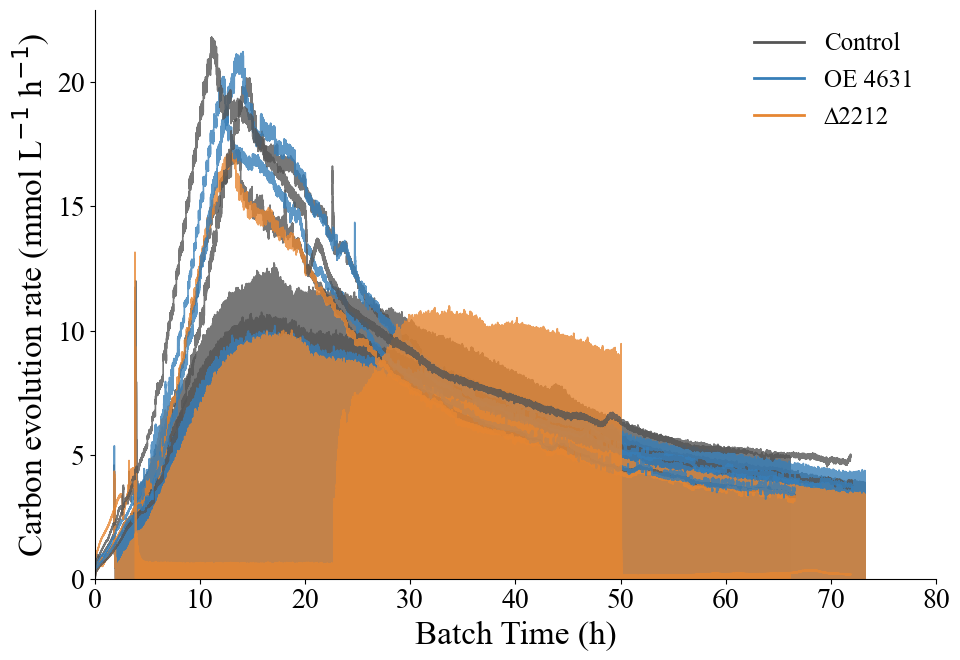

In [84]:
# ============================================================
# OUR and CER plots — one line per reactor across all biostats
# ============================================================

STRAIN_COLORS = {
    "Control": "#555555",
    "OE 4631": "#377EB8",
    "∆2212":   "#E68632",
}

# Map each (biostat, fermenter) to its strain
REACTOR_STRAIN = {
    ("df_60", "Fermenter01"): "Control",
    ("df_64", "Fermenter01"): "Control",
    ("df_71", "Fermenter01"): "Control",
    ("df_79", "Fermenter01"): "Control",   # adjust if different
    ("df_80", "Fermenter03"): "Control",   # adjust if different
    ("df_64", "Fermenter02"): "OE 4631",
    ("df_79", "Fermenter02"): "OE 4631",
    ("df_61", "Fermenter03"): "∆2212",
    ("df_64", "Fermenter03"): "∆2212",
    ("df_62", "Fermenter03"): "OE 4631",
    ("df_71", "Fermenter02"): "∆2212",
    ("df_71", "Fermenter03"): "OE 4631",
    ("df_80", "Fermenter02"): "∆2212",
}

FERMENTER_SLOTS = [
    ("Fermenter01", "BDCU-1"),
    ("Fermenter02", "BDCU-2"),
    ("Fermenter03", "BDCU-3"),
]

dfs = {
    "df_60": df_60,
    "df_64": df_64,
    "df_71": df_71,
    "df_79": df_79,
    "df_80": df_80,
}

def plot_gas(metric, ylabel, filename):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 20,
    })

    fig, ax = plt.subplots(figsize=(10, 7))
    plotted_strains = set()

    for df_name, df in dfs.items():
        for ferm, bdcu in FERMENTER_SLOTS:
            col = (ferm, bdcu, metric, "g/h")
            if col not in df.columns:
                continue

            strain = REACTOR_STRAIN.get((df_name, ferm))
            if strain is None:
                continue

            color = STRAIN_COLORS[strain]
            # Convert g/h to mmol/L/h (MW O2=32, MW CO2=44, working vol=1.5 L)
            mw = 32 if metric == "OUR" else 44
            x = df[col] * 1000 / (mw * 1.5)

            label = strain if strain not in plotted_strains else None
            ax.plot(x, color=color, linewidth=1.2, alpha=0.8, label=label)
            plotted_strains.add(strain)

    ax.set_xlim(0, 80)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Batch Time (h)", fontsize=24)
    ax.set_ylabel(ylabel, fontsize=24)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.tick_params(axis="both", which="minor", labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend with one entry per strain
    handles = [
        plt.Line2D([0], [0], color=STRAIN_COLORS[s], linewidth=2, label=s)
        for s in ["Control", "OE 4631", "∆2212"]
    ]
    ax.legend(handles=handles, fontsize=18, frameon=False, loc="best")

    fig.tight_layout()
    fig.savefig(filename, dpi=600, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    plt.show()

plot_gas("CER", "Carbon evolution rate (mmol L$^{-1}$ h$^{-1}$)", "CER_by_strain.png")

In [91]:

def clean_data(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]
def calculate_pO2_trends(df_po2):
    # grab air data and time of fermentation. 
    df_po2 = pd.DataFrame({
        'age': store[('ProcessTime',    'Value', 'hours')],
        'value': store[('pO2_A',    'Value',  '%sat')]
    })

    # calculate differences between pO2 points - note, the recording is not always 100% accurate. 
    df_po2['difference'] = df_po2['value'].diff()

    # note the trend, when there is a sign shift. 
    df_po2['trend_change'] = np.sign(df_po2['difference']) != np.sign(df_po2['difference'].shift())

    # grab index of when they shift signs. 
    trend_change_points = df_po2[df_po2['trend_change']].index


    
    # Initialize lists to store information.
    original_ages = []
    original_values = []
    value_differences = []
    age_differences = []
    
    # Calculate differences between consecutive trend change points.
    for idx in range(len(trend_change_points) - 1):
       
        t1_idx = trend_change_points[idx]
        t2_idx = trend_change_points[idx + 1]
    
        # append the time.
        original_ages.append(df_po2.loc[t1_idx, 'age'])

        # append the pO2. 
        original_values.append(df_po2.loc[t1_idx, 'value'])

        # calculate and append the change in time and pO2. 
        value_difference = df_po2.loc[t2_idx, 'value'] - df_po2.loc[t1_idx, 'value']
        age_difference = df_po2.loc[t2_idx, 'age'] - df_po2.loc[t1_idx, 'age']
    
        value_differences.append(value_difference)
        age_differences.append(age_difference)
    
    # Create new DataFrame with the extracted information.
    df_trend_changes = pd.DataFrame({
        'age': original_ages,
        'original_value': original_values,
        'value_difference': value_differences,
        'age_difference': age_differences
    })

    return (df_trend_changes)


def calculate_pO2_trends(df_po2):
    # grab air data and time of fermentation.
    df_po2 = pd.DataFrame({
        'age': df_po2[('ProcessTime', 'Value', 'hours')],
        'value': df_po2[('pO2_A', 'Value', '%sat')]
    })


    # force numeric - source columns sometimes come in as strings/object dtype
    df_po2['age'] = pd.to_numeric(df_po2['age'], errors='coerce')
    df_po2['value'] = pd.to_numeric(df_po2['value'], errors='coerce')

    # pO2 isn't logged every row - drop the gaps so diff() doesn't compare
    # against stale/missing readings.
    df_po2 = df_po2.dropna(subset=['value']).reset_index(drop=True)
    
    # calculate differences between pO2 points - note, the recording is not always 100% accurate.
    df_po2['difference'] = df_po2['value'].diff()

    # note the trend, when there is a genuine sign shift (ignore the first
    # row's NaN diff and ignore flat/zero readings, which aren't a reversal).
    sign = np.sign(df_po2['difference'])
    df_po2['trend_change'] = (
        (sign != sign.shift())
        & sign.notna()
        & sign.shift().notna()
        & (sign != 0)
    )

    # grab index of when they shift signs.
    trend_change_points = df_po2[df_po2['trend_change']].index

    # Initialize lists to store information.
    original_ages = []
    original_values = []
    value_differences = []
    age_differences = []

    # Calculate differences between consecutive trend change points.
    for idx in range(len(trend_change_points) - 1):

        t1_idx = trend_change_points[idx]
        t2_idx = trend_change_points[idx + 1]

        # append the time.
        original_ages.append(df_po2.loc[t1_idx, 'age'])

        # append the pO2.
        original_values.append(df_po2.loc[t1_idx, 'value'])

        # calculate and append the change in time and pO2.
        value_difference = df_po2.loc[t2_idx, 'value'] - df_po2.loc[t1_idx, 'value']
        age_difference = df_po2.loc[t2_idx, 'age'] - df_po2.loc[t1_idx, 'age']

        value_differences.append(value_difference)
        age_differences.append(age_difference)

    # Create new DataFrame with the extracted information.
    df_trend_changes = pd.DataFrame({
        'age': original_ages,
        'original_value': original_values,
        'value_difference': value_differences,
        'age_difference': age_differences
    })

    return df_trend_changes


In [90]:

def calculate_our_offgas_oscillate(offgas_df, reactor, airflow_lpm=1.125,
                                    working_volume_l=1.5):
    """
    Calculate off-gas OUR in mmol O2/L/h.

    Negative values represent oxygen uptake.
    """
    reactor_number = int(reactor.replace("r", ""))
    fermenter = f"Fermenter{reactor_number:02d}"
    bdcu = f"BDCU-{reactor_number}"

    R = 8.314472       # J/mol/K
    mw_o2 = 32.0       # g/mol

    result = pd.DataFrame({
        "age": pd.to_numeric(
            offgas_df["temp_age_continue"], errors="coerce"
        ),
        "yO2_out": pd.to_numeric(
            offgas_df[(fermenter, bdcu, "CH1-O2", "Vol %")],
            errors="coerce",
        ),
        "temp_K": pd.to_numeric(
            offgas_df[(fermenter, bdcu, "Temperature", "°C")],
            errors="coerce",
        ) + 273.15,
        "pressure_kPa": pd.to_numeric(
            offgas_df[(fermenter, bdcu, "Pressure", "bar")],
            errors="coerce",
        ) * 100,
    }).dropna()

    # offgas_df's original index sometimes carries the name "age" (set
    # upstream), which collides with our "age" column below and makes
    # sort_values("age") ambiguous. Strip it.
    result.index.name = None

    result["yO2_change"] = 20.95 - result["yO2_out"]

    result["O2change"] = (
        result["yO2_change"] / 100
        * airflow_lpm
        * result["pressure_kPa"]
        * mw_o2
        / (R * result["temp_K"])
    )

    result["OUR_offgas_mmol_L_h"] = (
        result["O2change"]
        * 1000
        / (mw_o2 * working_volume_l)
        * -1
    )

    return result.sort_values("age").reset_index(drop=True)

def get_average_scalar(series, hour_value, neighbor_count=5):
    """
    Convert the output of compute_average_for_series() into one scalar.
    """
    result = compute_average_for_series(
        series,
        hour_value,
        neighbor_count=neighbor_count,
    )

    if isinstance(result, pd.Series):
        values = pd.to_numeric(result, errors="coerce").dropna()
        return values.iloc[-1] if not values.empty else np.nan

    if isinstance(result, pd.DataFrame):
        values = pd.to_numeric(result.stack(), errors="coerce").dropna()
        return values.iloc[-1] if not values.empty else np.nan

    return pd.to_numeric(result, errors="coerce")


# The fifth entry must contain the pO2 signal used by
# calculate_pO2_trends(). The last entry is the BlueVis/off-gas dataframe.
oscillating_storages = [
    (Biostat2L_60_r1, "Biostat2L_60", "r1", storage_60_r1, df_60),
    (Biostat2L_61_r3, "Biostat2L_61", "r3", storage_61_r3, df_61),
    (Biostat2L_62_r3, "Biostat2L_62", "r3", storage_62_r3, df_62),
    (Biostat2L_64_r1, "Biostat2L_64", "r1", storage_64_r1, df_64),
    (Biostat2L_64_r2, "Biostat2L_64", "r2", storage_64_r2, df_64),
    (Biostat2L_64_r3, "Biostat2L_64", "r3", storage_64_r3, df_64),
]

working_volume_l = 1.5
oxygen_saturation_mg_l = 7.54

our_output = []

for biostat_df, biostat, reactor, po2_store, offgas_df in oscillating_storages:

    # ----------------------------------------------------------
    # Off-gas OUR
    # ----------------------------------------------------------
    offgas_our = calculate_our_offgas_oscillate(
        offgas_df,
        reactor=reactor,
        airflow_lpm=1.125,
        working_volume_l=working_volume_l,
    )

    x_our_offgas = offgas_our.set_index("age")[
        "OUR_offgas_mmol_L_h"
    ].sort_index()

    # ----------------------------------------------------------
    # Liquid-phase pO2 correction
    # ----------------------------------------------------------
    po2_trends = calculate_pO2_trends(po2_store).copy()

    numeric_columns = [
        "age",
        "original_value",
        "value_difference",
        "age_difference",
    ]

    for column in numeric_columns:
        if column in po2_trends.columns:
            po2_trends[column] = pd.to_numeric(
                po2_trends[column],
                errors="coerce",
            )

    po2_trends = (
        po2_trends
        .dropna(subset=["age", "value_difference"])
        .query("age > 0")
        .sort_values("age")
    )

    # Liquid-phase correction in g O2/L/h
    po2_trends["OUR_liquid_g_L_h"] = (
        po2_trends["value_difference"]
        * oxygen_saturation_mg_l
        / 1000
    )

    # Convert to mmol O2/L/h.
    # Do not divide by reactor volume here because 7.54 is already mg/L.
    po2_trends["OUR_liquid_mmol_L_h"] = (
        po2_trends["OUR_liquid_g_L_h"]
        * 1000
        / 32
    )

    # Retain only decreasing-pO2 portions.
    po2_trends = po2_trends[
        po2_trends["OUR_liquid_mmol_L_h"] < 0
    ]

    x_our_liquid = po2_trends.set_index("age")[
        "OUR_liquid_mmol_L_h"
    ].sort_index()

    # ----------------------------------------------------------
    # Calculate OUR at each sampling time
    # ----------------------------------------------------------
    offgas_values = []
    liquid_values = []
    corrected_values = []

    for hour_value in pd.to_numeric(biostat_df["hour"], errors="coerce"):

        if pd.isna(hour_value):
            offgas_value = np.nan
            liquid_value = np.nan
        else:
            offgas_value = get_average_scalar(
                x_our_offgas,
                hour_value,
                neighbor_count=5,
            )

            liquid_value = get_average_scalar(
                x_our_liquid,
                hour_value,
                neighbor_count=5,
            )

        corrected_value = (
            offgas_value + liquid_value
            if pd.notna(offgas_value) and pd.notna(liquid_value)
            else offgas_value
        )

        offgas_values.append(offgas_value)
        liquid_values.append(liquid_value)
        corrected_values.append(corrected_value)

    # These assignments modify the original biostat dataframes.
    biostat_df["average_our_offgas"] = offgas_values
    biostat_df["average_our_liquid_correction"] = liquid_values
    biostat_df["average_our"] = corrected_values
    biostat_df["Biostat"] = biostat
    biostat_df["reactor"] = reactor

    # Collect a compact output table.
    our_output.append(
        biostat_df[
            [
                "Biostat",
                "reactor",
                "hour",
                "average_our_offgas",
                "average_our_liquid_correction",
                "average_our",
            ]
        ].copy()
    )


# One combined dataframe containing all oscillatory OUR results.
oscillatory_our_df = pd.concat(our_output, ignore_index=True)

# Display/print the results.
print(
    oscillatory_our_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.2f}",
    )
)

# Optional export.
# oscillatory_our_df.to_csv(
#     "validation_oscillatory_corrected_OUR.csv",
#     index=False,
# )

# Optional combined dataframe containing all original measurements
# plus the calculated OUR columns.
validation_oscillatory_df = pd.concat(
    [entry[0] for entry in oscillating_storages],
    ignore_index=True,
)

print(
    validation_oscillatory_df[
        [
            "Biostat",
            "reactor",
            "hour",
            "average_our_offgas",
            "average_our_liquid_correction",
            "average_our",
        ]
    ].to_string(index=False, float_format=lambda value: f"{value:.2f}")
)

     Biostat reactor  hour  average_our_offgas  average_our_liquid_correction  average_our
Biostat2L_60      r1  0.50               -0.02                          -2.45        -2.47
Biostat2L_60      r1 15.00               -2.90                          -1.44        -4.34
Biostat2L_60      r1 27.25               -3.86                          -1.23        -5.09
Biostat2L_60      r1 43.00               -3.63                          -1.54        -5.18
Biostat2L_60      r1 49.00               -2.94                          -1.60        -4.55
Biostat2L_60      r1 66.25               -3.87                          -1.73        -5.60
Biostat2L_61      r3  0.50                0.29                          -3.36        -3.07
Biostat2L_61      r3 22.50               -2.97                          -0.90        -3.87
Biostat2L_61      r3 26.75               -3.10                          -0.73        -3.83
Biostat2L_61      r3 43.50               -2.75                          -1.01        -3.77

In [96]:
from scipy.interpolate import interp1d

SHARED_TIMEPOINTS = [0.5, 24, 48, 72]

# (Biostat2L_df, offgas_df, vessel_slot)
GROUPS = {
    ("Control", True): [
        (Biostat2L_60_r1, df_60, "Fermenter01", "BDCU-1", "F_in1"),
        (Biostat2L_64_r1, df_64, "Fermenter01", "BDCU-1", "F_in1"),
    ],
    ("Control", False): [
        (Biostat2L_71_r1, df_71, "Fermenter01", "BDCU-1", "F_in1"),
        (Biostat2L_80_r3, df_80, "Fermenter03", "BDCU-3", "F_in3"),   # 80a
        (Biostat2L_81_r1, None, "Fermenter01", "BDCU-1", "F_in1"),   # 80b
    ],
    ("OE 4631", True): [
        (Biostat2L_62_r3, df_62, "Fermenter03", "BDCU-3", "F_in3"),
        (Biostat2L_64_r2, df_64, "Fermenter02", "BDCU-2", "F_in2"),
        (Biostat2L_81_r3, None, "Fermenter03", "BDCU-3", "F_in3"),   # 80b
    ],
    ("OE 4631", False): [
        (Biostat2L_71_r3, df_71, "Fermenter03", "BDCU-3", "F_in3"),
        (Biostat2L_79_r2, df_79, "Fermenter02", "BDCU-2", "F_in2"),
    ],
    ("∆2212", True): [
        (Biostat2L_61_r3, df_61, "Fermenter03", "BDCU-3", "F_in3"),
        (Biostat2L_64_r3, df_64, "Fermenter03", "BDCU-3", "F_in3"),
        (Biostat2L_81_r2, None, "Fermenter02", "BDCU-2", "F_in2"),   # 80b
    ],
    ("∆2212", False): [
        (Biostat2L_71_r2, df_71, "Fermenter02", "BDCU-2", "F_in2"),
        (Biostat2L_79_r1, df_79, "Fermenter01", "BDCU-1", "F_in1"),
    ],
}

OFFGAS_COLS = {
    "Fermenter01": ("Fermenter01", "BDCU-1"),
    "Fermenter02": ("Fermenter02", "BDCU-2"),
    "Fermenter03": ("Fermenter03", "BDCU-3"),
}

BIOSTAT_COLS = ["Glucose.1", "Citric Acid.1", "OD600", "DCW (g/L)"]
def filter_oscillating_our(offgas_df, ferm, bdcu, fin_col_name, lag_points=3):
    fin_col = (ferm, bdcu, fin_col_name, "LPM")
    fin = offgas_df[fin_col]
    air_on_arr = (fin >= 0.375).values
    lag_mask = np.zeros(len(air_on_arr), dtype=bool)
    for i in range(1, len(air_on_arr)):
        if air_on_arr[i] and not air_on_arr[i - 1]:
            end = min(len(air_on_arr), i + lag_points)
            lag_mask[i:end] = True
    valid = air_on_arr & ~lag_mask
    return pd.Series(valid, index=offgas_df.index)


def get_offgas_at_timepoint(offgas_df, ferm, bdcu, fin_col_name,
                             target_hour, is_oscillating, neighbor_count=25):
    if offgas_df is None:
        return np.nan, np.nan

    age_col = "temp_age_continue"
    if age_col not in offgas_df.columns:
        return np.nan, np.nan

    cer_col = (ferm, bdcu, "CER", "g/h")
    age     = offgas_df[age_col]

    # CER — always use instrument column, same for both conditions
    if cer_col in offgas_df.columns:
        x_cer = offgas_df[cer_col] * 1000 / (48 * 1.5)
        if is_oscillating:
            fin_col_tuple = (ferm, bdcu, fin_col_name, "LPM")
            if fin_col_tuple in offgas_df.columns:
                valid_cer = filter_oscillating_our(
                    offgas_df, ferm, bdcu, fin_col_name, lag_points=3
                )
                x_cer = x_cer.loc[valid_cer]
                age_cer = age.loc[valid_cer]
            else:
                age_cer = age
        else:
            age_cer = age
        cer_s = pd.Series(x_cer.values, index=age_cer.values)
    else:
        cer_s = None

    # OUR — use raw O2% calculation for oscillating, instrument column for 25% pO2
    if is_oscillating:
        df_offgas = calculate_offgas_oscillate(offgas_df, ferm, bdcu)
        if df_offgas is None:
            our_s = None
        else:
            fin_col_tuple = (ferm, bdcu, fin_col_name, "LPM")
            if fin_col_tuple in offgas_df.columns:
                valid_our = filter_oscillating_our(
                    offgas_df, ferm, bdcu, fin_col_name, lag_points=3
                )
                df_offgas = df_offgas.loc[valid_our]
            if len(df_offgas) == 0:
                our_s = None
            else:
                our_s = pd.Series(
                    df_offgas["OUR (mmol/Lh)"].values,
                    index=df_offgas.index
                )
    else:
        our_col = (ferm, bdcu, "OUR", "g/h")
        if our_col not in offgas_df.columns:
            our_s = None
        else:
            x_our = offgas_df[our_col] * 1000 / (32 * 1.5)
            our_s = pd.Series(x_our.values, index=age.values)

    our_val = compute_average_for_series(our_s, target_hour, neighbor_count) \
              if our_s is not None else np.nan
    cer_val = compute_average_for_series(cer_s, target_hour, neighbor_count) \
              if cer_s is not None else np.nan

    our_val = float(our_val) if np.isscalar(our_val) else float(our_val.iloc[-1])
    cer_val = float(cer_val) if np.isscalar(cer_val) else float(cer_val.iloc[-1])

    return our_val, cer_val


def compute_average_for_series(series, target_hour, neighbor_count=10):
    """Find nearest points in a time-indexed series and average them."""
    series = series.reset_index(drop=False)
    # column 0 is the age/time index, column 1 is the value
    closest_idx = (series.iloc[:, 0] - target_hour).abs().idxmin()
    start_idx = max(0, closest_idx - neighbor_count)
    end_idx = min(len(series), closest_idx + neighbor_count + 1)
    subset = series.iloc[start_idx:end_idx]
    return subset.mean() if not subset.empty else float('nan')

def calculate_offgas_oscillate(df, ferm, bdcu):
    R = 8.314472
    mw_o2  = 32
    mw_co2 = 44

    o2_col  = (ferm, bdcu, 'CH1-O2',  'Vol %')
    co2_col = (ferm, bdcu, 'CH0-CO2', 'Vol %')   # ← was 'CH2-CO2'
    temp_col = (ferm, bdcu, 'Temperature', '°C')
    pres_col = (ferm, bdcu, 'Pressure', 'bar')

    if o2_col not in df.columns:
        print(f"Missing O2 column for {ferm}/{bdcu}")
        return None

    try:
        df_gas = pd.DataFrame({
            'age':      df['temp_age_continue'],
            'yO2_out':  df[o2_col],
            'yCO2_out': df[co2_col] if co2_col in df.columns else 0.04,
            'temp':     df[temp_col] + 273.15,
            'pres':     df[pres_col] * 100,
        }).set_index('age')

        # OUR: positive = consuming O2
        df_gas['yO2_change']    = df_gas['yO2_out'] - 20.95
        df_gas['OUR (mmol/Lh)'] = (
            df_gas['yO2_change'] / 100 * 1.125 * df_gas['pres'] * mw_o2
            / (R * df_gas['temp']) * 1000 / (mw_o2 * 1.5)
        )

        # CER: positive = producing CO2
        df_gas['yCO2_change']   = df_gas['yCO2_out'] - 0.04
        df_gas['CER (mmol/Lh)'] = (
            df_gas['yCO2_change'] / 100 * 1.125 * df_gas['pres'] * mw_co2
            / (R * df_gas['temp']) * 1000 / (mw_co2 * 1.5)
        )

        return df_gas

    except Exception as e:
        print(f"Failed for {ferm}/{bdcu}: {e}")
        return None


def compute_mu(od_series, time_series):
    """Compute specific growth rate µ = ln(OD2/OD1)/(t2-t1) at each interval."""
    od   = pd.to_numeric(od_series, errors="coerce").values
    time = pd.to_numeric(time_series, errors="coerce").values
    mu_vals, mu_times = [], []
    for i in range(1, len(od)):
        if od[i] > 0 and od[i-1] > 0 and (time[i] - time[i-1]) > 0:
            mu = np.log(od[i] / od[i-1]) / (time[i] - time[i-1])
            mu_vals.append(mu)
            mu_times.append((time[i] + time[i-1]) / 2)
        else:
            mu_vals.append(np.nan)
            mu_times.append((time[i] + time[i-1]) / 2)
    return mu_times, mu_vals


def compute_mu_at_timepoint(biostat_df, target_hour, neighbor_count=2):
    """Average µ around a target timepoint."""
    df = biostat_df.reset_index(drop=True)
    mu_times, mu_vals = compute_mu(df["OD600"], df["hour"])
    mu_series  = pd.Series(mu_vals,  index=range(len(mu_vals)))
    time_series = pd.Series(mu_times, index=range(len(mu_times)))

    closest_idx = (time_series - target_hour).abs().idxmin()
    start_idx = max(0, closest_idx - neighbor_count)
    end_idx   = min(len(mu_series), closest_idx + neighbor_count)
    return mu_series.iloc[start_idx:end_idx].mean()


# ============================================================
# Main loop: per-biostat values at shared timepoints
# ============================================================

all_records = []

def get_biostat_at_timepoint(df, target_hour, columns):
    """Get single nearest row — offline data has one measurement per timepoint."""
    df = df.reset_index(drop=True)
    closest_idx = (df['hour'] - target_hour).abs().idxmin()
    row = df.iloc[closest_idx]
    return {col: (row[col] if col in df.columns else np.nan) for col in columns}


BIOSTAT_COLS = ["Glucose.1", "Citric Acid.1", "OD600"]  # DCW not present, drop it

# ============================================================
# Main loop
# ============================================================

all_records = []

for (strain, is_osc), members in GROUPS.items():
    condition = "Oscillating" if is_osc else "25% pO2"

    for biostat_df, offgas_df, ferm, bdcu, fin_col_name in members:
        df = biostat_df.reset_index(drop=True)

        for t in SHARED_TIMEPOINTS:
            # Offline measurements — nearest row, no smoothing
            vals = get_biostat_at_timepoint(df, t, BIOSTAT_COLS)
            # µ from OD600 consecutive timepoints
            mu = compute_mu_at_timepoint(df, t, neighbor_count=1)

            # OUR/CER — smoothed from high-frequency off-gas data
            our, cer = get_offgas_at_timepoint(
                offgas_df, ferm, bdcu, fin_col_name,
                t, is_osc, neighbor_count=25
            )

            all_records.append({
                "strain":    strain,
                "condition": condition,
                "time_h":    t,
                **vals,
                "OUR":       our,
                "CER":       cer,
                "mu (1/h)":  mu,
            })

per_biostat_df = pd.DataFrame(all_records)

group_summary = (
    per_biostat_df
    .groupby(["strain", "condition", "time_h"])
    .agg(
        Glucose_mean= ("Glucose.1",     "mean"),
        Glucose_sd=   ("Glucose.1",     "std"),
        Citrate_mean= ("Citric Acid.1", "mean"),
        Citrate_sd=   ("Citric Acid.1", "std"),
        OD600_mean=   ("OD600",         "mean"),
        OD600_sd=     ("OD600",         "std"),
        OUR_mean=     ("OUR",           "mean"),
        OUR_sd=       ("OUR",           "std"),
        CER_mean=     ("CER",           "mean"),
        CER_sd=       ("CER",           "std"),
        mu_mean=      ("mu (1/h)",      "mean"),
        mu_sd=        ("mu (1/h)",      "std"),
        n=            ("OD600",         "count"),
    )
    .reset_index()
)
group_summary["RQ"] = group_summary["CER_mean"] / group_summary["OUR_mean"].abs()
group_summary["RQ_sd"] = group_summary["RQ"] * np.sqrt(
    (group_summary["CER_sd"] / group_summary["CER_mean"]) ** 2 +
    (group_summary["OUR_sd"] / group_summary["OUR_mean"].abs()) ** 2
)
print(group_summary.to_string())
# print(group_summary.to_string())

     strain    condition  time_h  Glucose_mean  Glucose_sd  Citrate_mean  Citrate_sd  OD600_mean  OD600_sd   OUR_mean     OUR_sd   CER_mean    CER_sd   mu_mean     mu_sd  n         RQ       RQ_sd
0   Control      25% pO2     0.5     97.158033    1.634038      0.503500    0.019870    0.426000  0.200042   0.166304   0.266532   0.773061  0.222449  0.282511  0.182241  3   4.648490    7.569173
1   Control      25% pO2    24.0     71.714767    2.391639      3.071733    1.144526   28.226667  2.880093 -12.941565   5.113215   9.711527  0.446474  0.221681  0.077502  3   0.750414    0.298489
2   Control      25% pO2    48.0     44.527133    6.091403     16.864633    4.121435   33.186667  1.891595 -12.972283  10.300955   4.989193  1.044554  0.083869  0.017153  3   0.384604    0.315841
3   Control      25% pO2    72.0     24.407900   10.269382     29.037767    7.029584   32.860000  3.309260 -11.447781   8.593443   3.811168  1.071033  0.004607  0.004743  2   0.332918    0.266848
4   Control  Oscilla

In [97]:
records = []
for name, df, strain, condition in [
    ("60_r1",  Biostat2L_60_r1, "Control",  "Oscillating"),
    ("61_r3",  Biostat2L_61_r3, "∆2212",    "Oscillating"),
    ("62_r3",  Biostat2L_62_r3, "OE 4631",  "Oscillating"),
    ("64_r1",  Biostat2L_64_r1, "Control",  "Oscillating"),
    ("64_r2",  Biostat2L_64_r2, "OE 4631",  "Oscillating"),
    ("64_r3",  Biostat2L_64_r3, "∆2212",    "Oscillating"),
    ("71_r1",  Biostat2L_71_r1, "Control",  "25% pO2"),
    ("71_r2",  Biostat2L_71_r2, "∆2212",    "25% pO2"),
    ("71_r3",  Biostat2L_71_r3, "OE 4631",  "25% pO2"),
    ("79_r1",  Biostat2L_79_r1, "∆2212",    "25% pO2"),
    ("79_r2",  Biostat2L_79_r2, "OE 4631",  "25% pO2"),
    ("80_r3",  Biostat2L_80_r3, "Control",  "25% pO2"),
    ("81_r1",  Biostat2L_81_r1, "Control",  "25% pO2"),
    ("81_r2",  Biostat2L_81_r2, "∆2212",    "Oscillating"),
    ("81_r3",  Biostat2L_81_r3, "OE 4631",  "Oscillating"),
]:
    tmp = df.copy()
    tmp["vessel"]    = name
    tmp["strain"]    = strain
    tmp["condition"] = condition
    records.append(tmp)

raw_df = pd.concat(records, ignore_index=True)
print(raw_df.to_string())

    Unnamed: 15       date      time   hour reactor  sample number  sample volume (mL)   OD600  Unnamed: 23  sugar consumed  citrate rate  citrate yield  specific sugar consumed (g/L)  specific sugar consumed (g/L/h)  specific citrate rate (g/L/h)  specific citrate yield (g/g substrate)  Unnamed: 31  Unnamed: 32  Unnamed: 33  Unnamed: 34  Unnamed: 35  Unnamed: 36  trehalose.1  Citric Acid.1  Glucose.1  Xylose.1  arabinose.1  xylitol.1  Erythritol.1  Itaconic Acid.1  Acetic Acid.1  ethanol.1 vessel   strain    condition
0           NaN 2026-01-24  15:15:00   0.50      r1            1.0                 NaN   0.401          NaN          0.0000      0.904600            NaN                         0.0000                         0.000000                       0.904600                                     NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN         0.4523    98.0533       NaN          NaN        NaN           NaN              NaN      